# Certified Defect Inspection under Scarce Labels

**What this notebook is.** A single self-contained record of the whole project:
the method, every experiment, and every experiment that failed. All source is
embedded below - there is no `.py` dependency. Select the kernel and Run All.

**The claim.** An inspection system should not report a confidence. It should
report a **guarantee**: given a target defect escape rate `alpha`, either return
an operating point whose escape rate is certified at or below `alpha`, or refuse
and hand the line back to human review. The refusal branch matters as much as
the first - a method that always answers is a method that sometimes lies.

**What is new.** Not the detector. The finding that the guarantee is bought with
*labelled defects* rather than labelled parts, that this makes cold-start the
binding constraint in practice, and a measured account of which acquisition
strategies do and do not buy their way out of it.

### How to read the results

Cells are labelled with what they establish:

| tag | meaning |
|---|---|
| **VALIDATED** | property checked empirically, many trials |
| **MEASURED** | number computed from real detector outputs |
| **NEGATIVE** | idea tried and refuted - kept deliberately |
| **UNTESTED** | stated as a hypothesis, not a claim |


## 0 · Embedded source

Every module is carried inside this notebook and registered as an
importable package, so `from src.risk.conformal import ...` below resolves to
code embedded here rather than to anything on disk.

In [57]:
import sys, types, json, os, glob, math, warnings
warnings.filterwarnings("ignore")

# Ensure working directory is always repository root, even when kernel starts in notebook/
_cur = os.path.abspath(os.getcwd())
ROOT = _cur
while _cur and _cur != os.path.dirname(_cur):
    if os.path.exists(os.path.join(_cur, "data", "processed")) or os.path.exists(os.path.join(_cur, "runs")):
        ROOT = _cur
        break
    _cur = os.path.dirname(_cur)
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

def get_path(rel):
    if not rel:
        return rel
    for candidate in [rel, os.path.join("..", rel), os.path.join(ROOT, rel)]:
        if os.path.exists(candidate):
            return candidate
    cur = os.path.abspath(os.getcwd())
    while cur and cur != os.path.dirname(cur):
        candidate = os.path.join(cur, rel)
        if os.path.exists(candidate):
            return candidate
        cur = os.path.dirname(cur)
    return rel

import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                            "font.size": 9, "axes.grid": True, "grid.alpha": .25})

_SRC = {}
def _register(name, source):
    parts = name.split(".")
    for i in range(1, len(parts)):
        pkg = ".".join(parts[:i])
        if pkg not in sys.modules:
            p = types.ModuleType(pkg); p.__path__ = []; sys.modules[pkg] = p
    m = types.ModuleType(name); m.__name__ = name; m.__file__ = f"<inline:{name}>"
    sys.modules[name] = m
    exec(compile(source, f"<inline:{name}>", "exec"), m.__dict__)
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], m)
print(f"working directory: {os.getcwd()}")
print("loader ready")

working directory: c:\Users\nirma\Desktop\vision_qa_xai
loader ready


In [58]:
_SRC["src.paper.figures"] = json.loads('"\\"\\"\\"\\nfigures.py\\n==========\\nPublication figure toolkit.\\n\\nOne place for every plot in the paper so that font sizes, colours, DPI and\\nexport format are decided once instead of drifting between cells. Journals\\nreject figures for inconsistent typography far more often than for bad\\nstatistics, and a per-cell `plt.plot` habit guarantees that inconsistency.\\n\\nPalette is colour-blind safe (Okabe-Ito) and stays legible in greyscale print,\\nwhich still matters for IEEE/Elsevier hardcopy.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport os\\nimport numpy as np\\nimport matplotlib as mpl\\nimport matplotlib.pyplot as plt\\nfrom matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch\\n\\n# Okabe-Ito: distinguishable under all common forms of colour vision deficiency\\nOKABE = [\\"#0072B2\\", \\"#D55E00\\", \\"#009E73\\", \\"#CC79A7\\",\\n         \\"#E69F00\\", \\"#56B4E9\\", \\"#F0E442\\", \\"#000000\\"]\\n\\nFIGDIR = \\"figures\\"\\n\\n\\ndef set_style(base: int = 11):\\n    mpl.rcParams.update({\\n        \\"figure.dpi\\": 120,\\n        \\"savefig.dpi\\": 300,          # 300 dpi is the usual journal floor\\n        \\"savefig.bbox\\": \\"tight\\",\\n        \\"font.family\\": \\"DejaVu Sans\\",\\n        \\"font.size\\": base,\\n        \\"axes.titlesize\\": base + 1,\\n        \\"axes.labelsize\\": base,\\n        \\"axes.grid\\": True,\\n        \\"grid.alpha\\": 0.25,\\n        \\"grid.linewidth\\": 0.6,\\n        \\"axes.spines.top\\": False,\\n        \\"axes.spines.right\\": False,\\n        \\"legend.frameon\\": False,\\n        \\"legend.fontsize\\": base - 1,\\n        \\"xtick.labelsize\\": base - 1,\\n        \\"ytick.labelsize\\": base - 1,\\n        \\"lines.linewidth\\": 1.8,\\n        \\"axes.prop_cycle\\": mpl.cycler(color=OKABE),\\n    })\\n\\n\\ndef save(fig, name: str, figdir: str = None):\\n    \\"\\"\\"Write PDF (vector, for the manuscript) and PNG (for the notebook).\\"\\"\\"\\n    d = figdir or FIGDIR\\n    os.makedirs(d, exist_ok=True)\\n    for ext in (\\"pdf\\", \\"png\\"):\\n        fig.savefig(os.path.join(d, f\\"{name}.{ext}\\"))\\n    return os.path.join(d, f\\"{name}.png\\")\\n\\n\\n# ---------------------------------------------------------------------------\\n# Image-strip helpers (per-stage before/after)\\n# ---------------------------------------------------------------------------\\n\\ndef image_strip(images: dict, title: str = \\"\\", boxes=None, cmaps=None,\\n                per_panel: float = 2.6):\\n    \\"\\"\\"Render an ordered {label: image} dict as one row, optional GT boxes.\\n\\n    Used for every preprocessing stage so the reader sees the actual pixels at\\n    each step rather than a claim about them.\\n    \\"\\"\\"\\n    n = len(images)\\n    fig, axes = plt.subplots(1, n, figsize=(per_panel * n, per_panel + 0.6))\\n    if n == 1:\\n        axes = [axes]\\n    for ax, (label, im) in zip(axes, images.items()):\\n        cmap = (cmaps or {}).get(label, \\"gray\\" if im.ndim == 2 else None)\\n        ax.imshow(im, cmap=cmap)\\n        ax.set_title(label.replace(\\"_\\", \\" \\"), fontsize=9)\\n        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)\\n        if boxes is not None:\\n            for x1, y1, x2, y2 in boxes:\\n                ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,\\n                                       ec=OKABE[1], lw=1.4))\\n    if title:\\n        fig.suptitle(title, y=1.02, fontsize=11)\\n    fig.tight_layout()\\n    return fig\\n\\n\\ndef histogram_panel(images: dict, title: str = \\"\\"):\\n    \\"\\"\\"Intensity histograms for the same stages - shows *why* a stage helped.\\"\\"\\"\\n    fig, ax = plt.subplots(figsize=(6.4, 3.2))\\n    for i, (label, im) in enumerate(images.items()):\\n        g = im if im.ndim == 2 else im.mean(axis=2)\\n        ax.hist(g.ravel(), bins=64, range=(0, 255), histtype=\\"step\\",\\n                label=label.replace(\\"_\\", \\" \\"), color=OKABE[i % len(OKABE)])\\n    ax.set_xlabel(\\"intensity\\"); ax.set_ylabel(\\"pixel count\\")\\n    ax.set_title(title or \\"Intensity distribution by stage\\")\\n    ax.legend(fontsize=8)\\n    fig.tight_layout()\\n    return fig\\n\\n\\n# ---------------------------------------------------------------------------\\n# Result plots\\n# ---------------------------------------------------------------------------\\n\\ndef grouped_bars(categories, series: dict, ylabel: str, title: str = \\"\\",\\n                 annotate: bool = True, figsize=(7.2, 3.6)):\\n    fig, ax = plt.subplots(figsize=figsize)\\n    n = len(series)\\n    w = 0.8 / n\\n    x = np.arange(len(categories))\\n    for i, (label, vals) in enumerate(series.items()):\\n        pos = x + (i - (n - 1) / 2) * w\\n        b = ax.bar(pos, vals, w, label=label, color=OKABE[i % len(OKABE)])\\n        if annotate:\\n            ax.bar_label(b, fmt=\\"%.3f\\", fontsize=7, padding=1.5)\\n    ax.set_xticks(x); ax.set_xticklabels(categories)\\n    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()\\n    fig.tight_layout()\\n    return fig\\n\\n\\ndef risk_coverage_plot(alphas, observed, stds=None, refused=None,\\n                       title=\\"Conformal risk control\\"):\\n    \\"\\"\\"The headline validation figure: observed risk vs target, with y=x.\\n\\n    Points on or below the diagonal are the guarantee holding. Refused\\n    operating points are drawn as open markers on the diagonal - the method\\n    declining to issue a certificate is a *result*, not missing data, and\\n    hiding them would overstate coverage.\\n    \\"\\"\\"\\n    fig, ax = plt.subplots(figsize=(4.6, 4.2))\\n    a = np.asarray(alphas, dtype=float)\\n    o = np.asarray(observed, dtype=float)\\n    lim = max(a.max(), np.nanmax(o)) * 1.15\\n\\n    ax.plot([0, lim], [0, lim], ls=\\"--\\", c=\\"0.5\\", lw=1.2, label=\\"target (y = x)\\")\\n    ax.fill_between([0, lim], [0, lim], [lim, lim], color=OKABE[1], alpha=0.07)\\n    ax.text(lim * 0.45, lim * 0.80, \\"violation region\\", color=OKABE[1],\\n            fontsize=8, ha=\\"center\\")\\n\\n    ok = ~np.isnan(o)\\n    if stds is not None:\\n        ax.errorbar(a[ok], o[ok], yerr=np.asarray(stds, float)[ok], fmt=\\"o\\",\\n                    color=OKABE[0], capsize=3, ms=6, label=\\"observed (mean +/- sd)\\")\\n    else:\\n        ax.plot(a[ok], o[ok], \\"o\\", color=OKABE[0], ms=6, label=\\"observed\\")\\n    if refused is not None and np.any(refused):\\n        r = np.asarray(refused, bool)\\n        ax.plot(a[r], a[r], \\"o\\", mfc=\\"none\\", mec=OKABE[3], ms=9, mew=1.6,\\n                label=\\"refused (alpha unreachable)\\")\\n\\n    ax.set_xlabel(r\\"target risk $\\\\alpha$\\")\\n    ax.set_ylabel(\\"observed escape rate\\")\\n    ax.set_title(title)\\n    ax.set_xlim(0, lim); ax.set_ylim(0, lim)\\n    ax.set_aspect(\\"equal\\")\\n    ax.legend(fontsize=8, loc=\\"lower right\\")\\n    fig.tight_layout()\\n    return fig\\n\\n\\ndef pareto_plot(review_loads, escapes, alpha=None, labels=None,\\n                title=\\"Review load vs defect escape\\"):\\n    \\"\\"\\"The industrial trade-off curve: how much human review buys how much safety.\\"\\"\\"\\n    fig, ax = plt.subplots(figsize=(5.4, 3.8))\\n    ax.plot(np.asarray(review_loads) * 100, escapes, \\"o-\\", color=OKABE[0], ms=5)\\n    if alpha is not None:\\n        ax.axhline(alpha, ls=\\"--\\", c=OKABE[1], lw=1.3,\\n                   label=fr\\"certified bound $\\\\alpha$ = {alpha}\\")\\n        ax.legend(fontsize=8)\\n    if labels:\\n        for xx, yy, t in zip(review_loads, escapes, labels):\\n            ax.annotate(t, (xx * 100, yy), fontsize=7,\\n                        textcoords=\\"offset points\\", xytext=(4, 4))\\n    ax.set_xlabel(\\"human review load (% of parts)\\")\\n    ax.set_ylabel(\\"defect escape rate\\")\\n    ax.set_title(title)\\n    fig.tight_layout()\\n    return fig\\n\\n\\ndef curve_panel(curves: dict, xlabel, ylabel, title=\\"\\", figsize=(5.4, 3.4)):\\n    fig, ax = plt.subplots(figsize=figsize)\\n    for i, (label, (x, y)) in enumerate(curves.items()):\\n        ax.plot(x, y, label=label, color=OKABE[i % len(OKABE)])\\n    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)\\n    ax.legend(fontsize=8)\\n    fig.tight_layout()\\n    return fig\\n\\n\\n# ---------------------------------------------------------------------------\\n# Schematic diagrams (drawn, not screenshotted - stays vector in the PDF)\\n# ---------------------------------------------------------------------------\\n\\ndef _box(ax, xy, w, h, text, fc, fontsize=8.5, tc=\\"white\\"):\\n    ax.add_patch(FancyBboxPatch(xy, w, h, boxstyle=\\"round,pad=0.012\\",\\n                                fc=fc, ec=\\"none\\"))\\n    ax.text(xy[0] + w / 2, xy[1] + h / 2, text, ha=\\"center\\", va=\\"center\\",\\n            fontsize=fontsize, color=tc, weight=\\"bold\\", zorder=3)\\n\\n\\ndef _arrow(ax, p0, p1, color=\\"0.35\\"):\\n    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=\\"-|>\\", mutation_scale=11,\\n                                 color=color, lw=1.3, zorder=2))\\n\\n\\ndef architecture_diagram():\\n    \\"\\"\\"End-to-end system schematic for the paper\'s method figure.\\"\\"\\"\\n    fig, ax = plt.subplots(figsize=(11.5, 3.5))\\n    ax.set_xlim(0, 11.5); ax.set_ylim(0, 3.5); ax.axis(\\"off\\"); ax.grid(False)\\n\\n    row = 1.35\\n    h = 0.85\\n    specs = [\\n        (0.10, 1.55, \\"Acquisition\\\\n(line camera)\\", \\"#4C4C4C\\"),\\n        (1.80, 1.55, \\"CCE encoding\\\\n[raw | CLAHE | HF]\\", OKABE[4]),\\n        (3.50, 1.55, \\"Detector\\\\nRT-DETR (NMS-free)\\", OKABE[0]),\\n        (5.20, 1.55, \\"Conformal\\\\ncalibration\\", OKABE[2]),\\n        (6.90, 1.55, \\"Faithfulness\\\\naudit\\", OKABE[3]),\\n        (8.60, 1.55, \\"Risk-controlled\\\\ntriage\\", OKABE[1]),\\n    ]\\n    for x, w, t, c in specs:\\n        _box(ax, (x, row), w, h, t, c)\\n    for i in range(len(specs) - 1):\\n        x0 = specs[i][0] + specs[i][1]\\n        _arrow(ax, (x0, row + h / 2), (specs[i + 1][0], row + h / 2))\\n\\n    # triage outputs\\n    outs = [(10.35, 2.55, \\"ACCEPT\\", OKABE[2]),\\n            (10.35, 1.45, \\"REVIEW\\", OKABE[4]),\\n            (10.35, 0.35, \\"REJECT\\", OKABE[1])]\\n    for x, y, t, c in outs:\\n        _box(ax, (x, y), 1.05, 0.6, t, c, fontsize=8)\\n        _arrow(ax, (specs[-1][0] + specs[-1][1], row + h / 2), (x, y + 0.3))\\n\\n    ax.text(5.75, 0.62, r\\"calibration block is disjoint from training  |  \\"\\n                        r\\"guarantee: $\\\\mathbb{E}[\\\\mathrm{escape}] \\\\leq \\\\alpha$\\",\\n            ha=\\"center\\", fontsize=9, style=\\"italic\\", color=\\"0.3\\")\\n    ax.text(2.65, 0.95, \\"zero added latency\\", ha=\\"center\\", fontsize=7.5,\\n            color=OKABE[4], style=\\"italic\\")\\n    fig.tight_layout()\\n    return fig\\n\\n\\ndef cce_diagram():\\n    \\"\\"\\"Why the two duplicated grey channels are wasted, and what replaces them.\\"\\"\\"\\n    fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.9))\\n    for ax, (title, chans, colors, note) in zip(axes, [\\n        (\\"Standard pipeline\\", [\\"grey\\", \\"grey\\", \\"grey\\"],\\n         [\\"#9E9E9E\\"] * 3, \\"2 of 3 channels carry\\\\nzero information\\"),\\n        (\\"Complementary Channel Encoding\\", [\\"raw\\", \\"CLAHE\\", \\"HF residual\\"],\\n         [OKABE[0], OKABE[4], OKABE[2]], \\"same shape, same FLOPs,\\\\nsame latency\\"),\\n    ]):\\n        ax.set_xlim(0, 4); ax.set_ylim(0, 3); ax.axis(\\"off\\"); ax.grid(False)\\n        for i, (c, col) in enumerate(zip(chans, colors)):\\n            _box(ax, (0.45 + i * 1.05, 1.25), 0.92, 0.85, c, col, fontsize=8)\\n        ax.set_title(title, fontsize=10)\\n        ax.text(2.0, 0.55, note, ha=\\"center\\", fontsize=8, color=\\"0.35\\",\\n                style=\\"italic\\")\\n    fig.tight_layout()\\n    return fig\\n"')
print("embedded src.paper.figures  (10742 chars)")

embedded src.paper.figures  (10742 chars)


In [59]:
_SRC["src.risk.conformal"] = json.loads('"\\"\\"\\"\\nconformal.py\\n============\\nDistribution-free risk control for defect inspection.\\n\\nThis module is the mathematical core of the method. It converts a detector\'s\\nuncalibrated confidence scores into operating points that carry *finite-sample,\\ndistribution-free* guarantees on the quantity a QA line actually cares about:\\nthe **defect escape rate** (fraction of true defects that are not flagged).\\n\\nThree layers, in increasing order of what they buy you:\\n\\n1. `conformal_risk_control` - Angelopoulos, Bates, Fisch, Lei & Schuster,\\n   \\"Conformal Risk Control\\" (ICLR 2024). Picks a single threshold lambda_hat\\n   such that the expected loss on a fresh exchangeable image is <= alpha.\\n   Requires the per-image loss to be monotone in lambda; ours is.\\n\\n2. `learn_then_test` - Angelopoulos, Bates, Candes, Jordan & Lei, \\"Learn then\\n   Test: Calibrating Predictive Algorithms to Achieve Risk Control\\" (2021).\\n   Searches a *multi-dimensional* configuration grid (accept threshold x review\\n   threshold x faithfulness gate) and returns only the configurations whose\\n   risk is statistically certified, with family-wise error control. This is\\n   what makes the two-threshold triage policy valid - plain CRC only handles a\\n   one-dimensional monotone family.\\n\\n3. `mondrian_risk_control` - per-group (e.g. per defect class) risk control, so\\n   a safety-critical class can be held to a tighter escape bound than a\\n   cosmetic one. The guarantee holds conditionally within each group.\\n\\nNotation follows the papers: n calibration points, loss L_i(lambda) in [0, B],\\ntarget risk level alpha.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\nfrom typing import Sequence\\n\\n\\nclass RiskNotAchievable(RuntimeError):\\n    \\"\\"\\"Raised when no configuration in the grid can certify the target risk.\\"\\"\\"\\n\\n\\n# ---------------------------------------------------------------------------\\n# 1. Conformal Risk Control (monotone, one-dimensional)\\n# ---------------------------------------------------------------------------\\n\\ndef conformal_risk_control(\\n    losses: np.ndarray,\\n    lambdas: np.ndarray,\\n    alpha: float,\\n    B: float = 1.0,\\n) -> float:\\n    \\"\\"\\"Smallest lambda whose certified risk is <= alpha.\\n\\n    Parameters\\n    ----------\\n    losses : (n, m) array\\n        losses[i, j] = loss of calibration example i at lambdas[j]. Must be\\n        non-increasing along j. This is checked, not assumed.\\n    lambdas : (m,) array of score thresholds in DESCENDING order.\\n        Descending is not a style choice: escape loss *rises* with the score\\n        threshold (a higher bar rejects more true defects), so the grid has to\\n        run high -> low for the loss to be non-increasing along j, which is what\\n        the CRC theorem requires. Use `escape_threshold_grid()` to get this\\n        right. Feeding an ascending grid raises rather than silently returning\\n        an invalid guarantee.\\n    alpha : target risk level in (0, 1).\\n    B : upper bound on the loss (1.0 for a fraction-missed loss).\\n\\n    Guarantee\\n    ---------\\n    E[L_{n+1}(lambda_hat)] <= alpha over the draw of the calibration set and\\n    the test point, requiring only exchangeability - no distributional\\n    assumptions, no asymptotics, valid at any n.\\n\\n    The estimator is the CRC one:\\n\\n        R_hat_n(lambda) = (1/n) sum_i L_i(lambda)\\n        lambda_hat = inf{ lambda : (n/(n+1)) R_hat_n(lambda) + B/(n+1) <= alpha }\\n\\n    The B/(n+1) term is the finite-sample correction that makes the bound hold\\n    for the *next* point rather than only in expectation over calibration.\\n    \\"\\"\\"\\n    losses = np.asarray(losses, dtype=float)\\n    lambdas = np.asarray(lambdas, dtype=float)\\n    if losses.ndim != 2:\\n        raise ValueError(f\\"losses must be 2-D (n, m), got shape {losses.shape}\\")\\n    n, m = losses.shape\\n    if m != lambdas.shape[0]:\\n        raise ValueError(f\\"losses has {m} columns but {lambdas.shape[0]} lambdas\\")\\n    if not 0.0 < alpha < 1.0:\\n        raise ValueError(f\\"alpha must be in (0,1), got {alpha}\\")\\n\\n    mean_loss = losses.mean(axis=0)\\n    # Monotonicity is a precondition of the CRC theorem; violating it silently\\n    # would invalidate the guarantee, so fail loudly instead.\\n    increases = np.diff(mean_loss) > 1e-9\\n    if increases.any():\\n        bad = int(np.argmax(increases))\\n        raise ValueError(\\n            \\"CRC requires the empirical risk to be non-increasing in lambda; it \\"\\n            f\\"increases between index {bad} (R={mean_loss[bad]:.4f}) and \\"\\n            f\\"{bad + 1} (R={mean_loss[bad + 1]:.4f}). Check the loss definition \\"\\n            \\"or the ordering of `lambdas`.\\"\\n        )\\n\\n    rhs = (n / (n + 1.0)) * mean_loss + B / (n + 1.0)\\n    feasible = np.flatnonzero(rhs <= alpha)\\n    if feasible.size == 0:\\n        raise RiskNotAchievable(\\n            f\\"no lambda achieves alpha={alpha}: min certified risk is \\"\\n            f\\"{rhs.min():.4f} at lambda={lambdas[int(np.argmin(rhs))]:.4f}. \\"\\n            \\"Loosen alpha, improve the detector, or enlarge the calibration set \\"\\n            f\\"(n={n}, finite-sample penalty B/(n+1)={B / (n + 1):.4f}).\\"\\n        )\\n    return float(lambdas[feasible[0]])\\n\\n\\n# ---------------------------------------------------------------------------\\n# 2. Learn then Test (multi-dimensional, non-monotone configuration search)\\n# ---------------------------------------------------------------------------\\n\\ndef _h1(a: np.ndarray, b: float) -> np.ndarray:\\n    \\"\\"\\"KL divergence between Bernoulli(a) and Bernoulli(b).\\"\\"\\"\\n    a = np.clip(a, 1e-12, 1 - 1e-12)\\n    b = float(np.clip(b, 1e-12, 1 - 1e-12))\\n    return a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))\\n\\n\\ndef hoeffding_bentkus_pvalue(r_hat: np.ndarray, n: int, alpha: float) -> np.ndarray:\\n    \\"\\"\\"Valid p-value for H0: R(lambda) > alpha, for losses bounded in [0, 1].\\n\\n    The Hoeffding-Bentkus p-value is the minimum of two concentration bounds\\n    (Bates et al. 2021): Hoeffding is tight in the bulk, Bentkus/binomial in the\\n    tail. The minimum of two valid p-values is itself valid.\\n    \\"\\"\\"\\n    from scipy.stats import binom\\n\\n    r_hat = np.asarray(r_hat, dtype=float)\\n    hoeffding = np.exp(-n * _h1(np.minimum(r_hat, alpha), alpha))\\n    bentkus = np.e * binom.cdf(np.ceil(n * r_hat), n, alpha)\\n    return np.minimum(1.0, np.minimum(hoeffding, bentkus))\\n\\n\\ndef learn_then_test(\\n    losses: np.ndarray,\\n    alpha: float,\\n    delta: float = 0.1,\\n    correction: str = \\"bonferroni\\",\\n) -> np.ndarray:\\n    \\"\\"\\"Indices of configurations certified to have risk <= alpha.\\n\\n    Unlike CRC this makes no monotonicity assumption, so the configuration grid\\n    may be multi-dimensional and arbitrarily ordered - exactly what the\\n    two-threshold triage policy needs.\\n\\n    Parameters\\n    ----------\\n    losses : (n, m) per-example loss for each of m configurations.\\n    alpha : target risk.\\n    delta : allowed probability of any false certification (family-wise).\\n    correction : \\"bonferroni\\" (valid, conservative) or \\"fixed_sequence\\"\\n        (more powerful, valid only for a pre-specified order).\\n    \\"\\"\\"\\n    losses = np.asarray(losses, dtype=float)\\n    n, m = losses.shape\\n    r_hat = losses.mean(axis=0)\\n    p = hoeffding_bentkus_pvalue(r_hat, n, alpha)\\n\\n    if correction == \\"bonferroni\\":\\n        return np.flatnonzero(p <= delta / m)\\n\\n    if correction == \\"fixed_sequence\\":\\n        order = np.argsort(r_hat)\\n        keep = []\\n        for j in order:\\n            if p[j] <= delta:\\n                keep.append(int(j))\\n            else:\\n                break\\n        return np.array(sorted(keep), dtype=int)\\n\\n    raise ValueError(f\\"unknown correction {correction!r}\\")\\n\\n\\n# ---------------------------------------------------------------------------\\n# 3. Mondrian (group-conditional) risk control\\n# ---------------------------------------------------------------------------\\n\\ndef mondrian_risk_control(\\n    losses: np.ndarray,\\n    lambdas: np.ndarray,\\n    groups: np.ndarray,\\n    alpha_by_group: dict,\\n    B: float = 1.0,\\n) -> dict:\\n    \\"\\"\\"Per-group CRC: one calibrated threshold per group, each with its own alpha.\\n\\n    Lets a safety-critical defect class be held to a tighter escape bound than a\\n    cosmetic one. Exchangeability now only needs to hold *within* each group,\\n    which is a weaker and more realistic assumption on a production line than\\n    global exchangeability across defect types.\\n    \\"\\"\\"\\n    lambdas = np.asarray(lambdas, dtype=float)\\n    out = {}\\n    for g, alpha_g in alpha_by_group.items():\\n        mask = groups == g\\n        n_g = int(mask.sum())\\n        if n_g == 0:\\n            out[g] = {\\"lambda\\": None, \\"n\\": 0, \\"error\\": \\"no calibration data\\"}\\n            continue\\n        try:\\n            lam = conformal_risk_control(losses[mask], lambdas, alpha_g, B=B)\\n            # exact lookup: lambdas is descending, so searchsorted would be wrong\\n            j = int(np.flatnonzero(lambdas == lam)[0])\\n            out[g] = {\\n                \\"lambda\\": lam,\\n                \\"n\\": n_g,\\n                \\"alpha\\": alpha_g,\\n                \\"empirical_risk\\": float(losses[mask][:, j].mean()),\\n            }\\n        except RiskNotAchievable as e:\\n            out[g] = {\\"lambda\\": None, \\"n\\": n_g, \\"alpha\\": alpha_g, \\"error\\": str(e)}\\n    return out\\n\\n\\n# ---------------------------------------------------------------------------\\n# Loss definitions for detection\\n# ---------------------------------------------------------------------------\\n\\ndef escape_threshold_grid(n: int = 201, lo: float = 0.0, hi: float = 1.0) -> np.ndarray:\\n    \\"\\"\\"Descending score-threshold grid, the ordering CRC needs for escape loss.\\n\\n    Descending because escape loss increases with the threshold; see the\\n    `lambdas` note in `conformal_risk_control`.\\n    \\"\\"\\"\\n    return np.linspace(hi, lo, n)\\n\\n\\ndef box_iou_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:\\n    \\"\\"\\"IoU between boxes a (N,4) and b (M,4), both xyxy. Returns (N, M).\\"\\"\\"\\n    a = np.asarray(a, dtype=float).reshape(-1, 4)\\n    b = np.asarray(b, dtype=float).reshape(-1, 4)\\n    if a.shape[0] == 0 or b.shape[0] == 0:\\n        return np.zeros((a.shape[0], b.shape[0]), dtype=float)\\n    area_a = np.clip(a[:, 2] - a[:, 0], 0, None) * np.clip(a[:, 3] - a[:, 1], 0, None)\\n    area_b = np.clip(b[:, 2] - b[:, 0], 0, None) * np.clip(b[:, 3] - b[:, 1], 0, None)\\n    lt = np.maximum(a[:, None, :2], b[None, :, :2])\\n    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])\\n    wh = np.clip(rb - lt, 0, None)\\n    inter = wh[..., 0] * wh[..., 1]\\n    union = area_a[:, None] + area_b[None, :] - inter\\n    return np.where(union > 0, inter / np.maximum(union, 1e-12), 0.0)\\n\\n\\ndef escape_loss_curve(\\n    gt_boxes: np.ndarray,\\n    pred_boxes: np.ndarray,\\n    pred_scores: np.ndarray,\\n    lambdas: np.ndarray,\\n    iou_thresh: float = 0.5,\\n) -> np.ndarray:\\n    \\"\\"\\"Per-image defect-escape loss as a function of the score threshold.\\n\\n        L(lambda) = #{GT defects with no prediction of score >= lambda\\n                      at IoU >= iou_thresh} / #{GT defects}\\n\\n    Bounded in [0, 1] and non-increasing as lambda decreases, as CRC requires.\\n    Defect-free images contribute 0 - they cannot produce an escape, and\\n    including them would dilute the risk estimate, so `build_calibration_losses`\\n    filters them out by default.\\n    \\"\\"\\"\\n    lambdas = np.asarray(lambdas, dtype=float)\\n    m = lambdas.shape[0]\\n    gt_boxes = np.asarray(gt_boxes, dtype=float).reshape(-1, 4)\\n    if gt_boxes.shape[0] == 0:\\n        return np.zeros(m, dtype=float)\\n    pred_boxes = np.asarray(pred_boxes, dtype=float).reshape(-1, 4)\\n    if pred_boxes.shape[0] == 0:\\n        return np.ones(m, dtype=float)\\n\\n    hit = box_iou_matrix(gt_boxes, pred_boxes) >= iou_thresh   # (n_gt, n_pred)\\n    scores = np.asarray(pred_scores, dtype=float).reshape(-1)\\n\\n    out = np.empty(m, dtype=float)\\n    for j, lam in enumerate(lambdas):\\n        kept = scores >= lam\\n        if not kept.any():\\n            out[j] = 1.0\\n        else:\\n            out[j] = 1.0 - hit[:, kept].any(axis=1).mean()\\n    return out\\n\\n\\ndef build_calibration_losses(\\n    records: Sequence[dict],\\n    lambdas: np.ndarray,\\n    iou_thresh: float = 0.5,\\n    drop_defect_free: bool = True,\\n):\\n    \\"\\"\\"Assemble the (n, m) calibration loss matrix from per-image records.\\n\\n    Each record needs `gt_boxes` (N,4), `pred_boxes` (M,4), `pred_scores` (M,),\\n    and optionally `gt_labels` for Mondrian grouping.\\n\\n    Returns (losses, groups, kept_indices).\\n    \\"\\"\\"\\n    lambdas = np.asarray(lambdas, dtype=float)\\n    losses, groups, keep = [], [], []\\n    for i, r in enumerate(records):\\n        gt = np.asarray(r[\\"gt_boxes\\"], dtype=float).reshape(-1, 4)\\n        if drop_defect_free and gt.shape[0] == 0:\\n            continue\\n        losses.append(\\n            escape_loss_curve(gt, r[\\"pred_boxes\\"], r[\\"pred_scores\\"], lambdas, iou_thresh)\\n        )\\n        labels = r.get(\\"gt_labels\\")\\n        groups.append(int(labels[0]) if labels is not None and len(labels) else -1)\\n        keep.append(i)\\n    if not losses:\\n        raise ValueError(\\"no usable calibration images (all defect-free?)\\")\\n    return np.stack(losses), np.asarray(groups), np.asarray(keep)\\n"')
print("embedded src.risk.conformal  (12956 chars)")

embedded src.risk.conformal  (12956 chars)


In [60]:
_SRC["src.risk.adaptive"] = json.loads('"\\"\\"\\"\\nadaptive.py\\n===========\\nRisk control when the production line drifts.\\n\\nSplit-conformal guarantees (`conformal.py`) rest on exchangeability between the\\ncalibration block and the test point. A real inspection line violates that\\nconstantly: a new steel coil, a lamp that dims, a re-tooled press, a seasonal\\nchange in raw material. Once the score distribution moves, a threshold\\ncalibrated last month is no longer certified, and - worse - nothing in the\\nstatic procedure tells you it has stopped being certified.\\n\\nTwo mechanisms here, addressing the open problem stated as future work in\\nConformal Segmentation in Industrial Surface Defect Detection (arXiv:2504.17721,\\n2025): \\"dynamic calibration mechanisms to address time-varying distribution\\nshifts in production line data\\".\\n\\n1. `AdaptiveRiskController` - online threshold adaptation in the style of\\n   Gibbs & Candes, \\"Adaptive Conformal Inference Under Distribution Shift\\"\\n   (NeurIPS 2021), transposed from coverage to *risk*. The update is\\n\\n       lambda_{t+1} = clip( lambda_t + gamma * (alpha - L_t) )\\n\\n   where L_t is the realised escape loss on the part just inspected. If parts\\n   start escaping (L_t > alpha) the threshold falls and the detector becomes\\n   more permissive; if nothing escapes it rises again and review load drops.\\n\\n   The guarantee is different in kind from split conformal and worth stating\\n   precisely, because it is easy to overclaim. It is a *long-run* bound on the\\n   realised average loss, and it holds for an ARBITRARY - even adversarial -\\n   sequence, with no exchangeability assumption at all:\\n\\n       | (1/T) sum_t L_t  -  alpha |  <=  (lambda_max - lambda_min + gamma) / (gamma * T)\\n\\n   So the time-average risk converges to alpha at rate O(1/T). What it does NOT\\n   give is a guarantee for any individual part, which split CRC does give under\\n   exchangeability. The two are complements: CRC for the certified static\\n   operating point, ACI to keep it honest as the line moves.\\n\\n2. `DriftMonitor` - a two-sample test on the score distribution that raises an\\n   alarm before the escape rate degrades, so recalibration can be triggered on\\n   evidence rather than on a fixed schedule.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\nfrom dataclasses import dataclass, field\\n\\n\\n# ---------------------------------------------------------------------------\\n# Online adaptive risk control\\n# ---------------------------------------------------------------------------\\n\\n@dataclass\\nclass AdaptiveRiskController:\\n    \\"\\"\\"Online threshold adaptation with a long-run risk guarantee.\\n\\n    Parameters\\n    ----------\\n    alpha : target long-run risk (e.g. 0.05 escape rate).\\n    gamma : step size. Larger adapts faster to abrupt drift but leaves more\\n        residual oscillation; the O(1/(gamma*T)) bound tightens with larger\\n        gamma while the variance of lambda_t grows with it, so this is a genuine\\n        bias/variance trade-off rather than a free knob.\\n    lambda_init, lambda_min, lambda_max : threshold and its clip range.\\n    \\"\\"\\"\\n\\n    alpha: float\\n    gamma: float = 0.02\\n    lambda_init: float = 0.5\\n    lambda_min: float = 0.0\\n    lambda_max: float = 1.0\\n\\n    lam: float = field(init=False)\\n    history: list = field(default_factory=list, init=False)\\n\\n    def __post_init__(self):\\n        if not 0.0 < self.alpha < 1.0:\\n            raise ValueError(f\\"alpha must be in (0,1), got {self.alpha}\\")\\n        if self.gamma <= 0:\\n            raise ValueError(f\\"gamma must be positive, got {self.gamma}\\")\\n        self.lam = float(np.clip(self.lambda_init, self.lambda_min, self.lambda_max))\\n\\n    def update(self, realized_loss: float) -> float:\\n        \\"\\"\\"Feed back the loss observed at the current threshold, get the next one.\\"\\"\\"\\n        loss = float(realized_loss)\\n        self.history.append({\\"lambda\\": self.lam, \\"loss\\": loss})\\n        self.lam = float(np.clip(self.lam + self.gamma * (self.alpha - loss),\\n                                 self.lambda_min, self.lambda_max))\\n        return self.lam\\n\\n    # -- diagnostics ------------------------------------------------------\\n    @property\\n    def realized_risk(self) -> float:\\n        return float(np.mean([h[\\"loss\\"] for h in self.history])) if self.history else 0.0\\n\\n    def regret_bound(self) -> float:\\n        \\"\\"\\"The theoretical bound on |time-average risk - alpha| after T steps.\\"\\"\\"\\n        T = max(len(self.history), 1)\\n        return (self.lambda_max - self.lambda_min + self.gamma) / (self.gamma * T)\\n\\n    def summary(self) -> dict:\\n        return {\\n            \\"steps\\": len(self.history),\\n            \\"alpha\\": self.alpha,\\n            \\"gamma\\": self.gamma,\\n            \\"lambda_final\\": self.lam,\\n            \\"realized_risk\\": self.realized_risk,\\n            \\"abs_gap\\": abs(self.realized_risk - self.alpha),\\n            \\"regret_bound\\": self.regret_bound(),\\n            \\"within_bound\\": abs(self.realized_risk - self.alpha) <= self.regret_bound(),\\n        }\\n\\n\\n# ---------------------------------------------------------------------------\\n# Drift detection\\n# ---------------------------------------------------------------------------\\n\\n@dataclass\\nclass DriftMonitor:\\n    \\"\\"\\"Sliding-window two-sample test against the calibration score distribution.\\n\\n    Operates on detector scores rather than on the realised loss, which is the\\n    point: scores are available on every part immediately, whereas the loss\\n    needs ground truth that on a real line only arrives later (or never). This\\n    is what lets the alarm fire *before* escapes accumulate.\\n\\n    The defaults for `p_threshold` and `persistence` are set from measured\\n    failure modes, not convention. Testing a shift-free stream of 1500 parts\\n    against a 500-sample reference produced a sustained false alarm ~100 parts\\n    *before* the injected shift, from two compounding causes:\\n\\n      * The reference is one finite sample and can simply be atypical. The draw\\n        used in testing sat 2.6 sigma low, which biases every subsequent\\n        comparison toward rejection. No amount of persistence fixes a reference\\n        that is off-centre, so the threshold has to carry the slack: at\\n        p < 0.001 that run produced zero false alarms (its smallest pre-shift\\n        p-value was 2.9e-3), where p < 0.01 produced 26.\\n\\n      * Consecutive windows overlap in 199 of 200 samples, so they are nowhere\\n        near independent tests. The longest unbroken run of pre-shift\\n        rejections was 18, which defeats any short persistence requirement.\\n        Hence persistence defaults to a quarter of the window rather than a\\n        small constant - it has to span enough fresh samples to be a genuinely\\n        new test.\\n\\n    Together these cost some detection latency, which is the right trade on an\\n    inspection line: an alarm that fires spuriously trains operators to ignore\\n    it, and a monitor that is ignored is worth nothing.\\n    \\"\\"\\"\\n\\n    reference_scores: np.ndarray\\n    window: int = 200\\n    p_threshold: float = 0.001\\n    persistence: int = None   # defaults to window // 4\\n\\n    buffer: list = field(default_factory=list, init=False)\\n    alarms: list = field(default_factory=list, init=False)\\n    _t: int = field(default=0, init=False)\\n    _streak: int = field(default=0, init=False)\\n    _fired: bool = field(default=False, init=False)\\n\\n    def __post_init__(self):\\n        self.reference_scores = np.asarray(self.reference_scores, dtype=float).reshape(-1)\\n        if self.reference_scores.size < 20:\\n            raise ValueError(\\"need at least 20 reference scores for a meaningful test\\")\\n        if self.persistence is None:\\n            self.persistence = max(10, self.window // 4)\\n\\n    def push(self, score: float) -> dict | None:\\n        \\"\\"\\"Add one part\'s score; returns an alarm record when drift is detected.\\"\\"\\"\\n        from scipy.stats import ks_2samp\\n\\n        self._t += 1\\n        self.buffer.append(float(score))\\n        if len(self.buffer) > self.window:\\n            self.buffer.pop(0)\\n        if len(self.buffer) < self.window:\\n            return None\\n\\n        stat, p = ks_2samp(self.reference_scores, np.asarray(self.buffer))\\n        if p < self.p_threshold:\\n            self._streak += 1\\n        else:\\n            self._streak = 0\\n            return None\\n\\n        if self._streak < self.persistence:\\n            return None\\n\\n        # Latch: reset the streak so a single drift event produces one alarm\\n        # rather than one per part for the rest of the run. Without this the\\n        # caller sees hundreds of duplicate alarms for the same event and any\\n        # alarm-triggered action fires repeatedly.\\n        self._streak = 0\\n        rec = {\\"t\\": self._t, \\"ks_stat\\": float(stat), \\"p_value\\": float(p),\\n               \\"window_mean\\": float(np.mean(self.buffer)),\\n               \\"reference_mean\\": float(self.reference_scores.mean())}\\n        self.alarms.append(rec)\\n        return rec\\n\\n    def summary(self) -> dict:\\n        return {\\"steps\\": self._t, \\"n_alarms\\": len(self.alarms),\\n                \\"persistence\\": self.persistence,\\n                \\"first_alarm_t\\": self.alarms[0][\\"t\\"] if self.alarms else None}\\n\\n\\n# ---------------------------------------------------------------------------\\n# Simulation harness (used by the drift experiment and the paper figure)\\n# ---------------------------------------------------------------------------\\n\\ndef run_adaptive_experiment(loss_at_lambda, n_steps, alpha, gamma=0.02,\\n                            lambda_grid=None, seed=0):\\n    \\"\\"\\"Drive an AdaptiveRiskController through a (possibly drifting) stream.\\n\\n    `loss_at_lambda(t, lam, rng) -> float` supplies the realised loss for the\\n    part at time t when the threshold is lam, and is where a drift schedule is\\n    injected.\\n    \\"\\"\\"\\n    rng = np.random.default_rng(seed)\\n    lambda_grid = lambda_grid if lambda_grid is not None else (0.0, 1.0)\\n    ctrl = AdaptiveRiskController(alpha=alpha, gamma=gamma,\\n                                  lambda_min=lambda_grid[0], lambda_max=lambda_grid[1])\\n    lams, losses = [], []\\n    for t in range(n_steps):\\n        lam = ctrl.lam\\n        L = loss_at_lambda(t, lam, rng)\\n        lams.append(lam)\\n        losses.append(L)\\n        ctrl.update(L)\\n    return {\\"lambdas\\": np.asarray(lams), \\"losses\\": np.asarray(losses),\\n            \\"controller\\": ctrl, \\"summary\\": ctrl.summary()}\\n\\n\\ndef simulated_line_loss(quality_schedule):\\n    \\"\\"\\"Build an escape-loss function for a drifting inspection line.\\n\\n    `quality_schedule(t) -> q in (0, 1]` is the detector\'s effective quality at\\n    time t, where 1.0 means \\"as trained\\". Scores for true defects are drawn from\\n    a Beta whose mass slides toward zero as q falls, which is what a drifting\\n    line looks like from the detector\'s side: defects get harder to see, scores\\n    sag, and a frozen threshold starts letting them through.\\n\\n    Lives here rather than in the test file so the drift experiment, the paper\\n    figure and the notebook all exercise the same generator.\\n    \\"\\"\\"\\n    def loss_at_lambda(t, lam, rng):\\n        q = float(quality_schedule(t))\\n        n_def = 1 + rng.poisson(1.5)\\n        scores = rng.beta(6.0 * q, 3.0, size=n_def) * q\\n        return float((scores < lam).mean())\\n    return loss_at_lambda\\n"')
print("embedded src.risk.adaptive  (11123 chars)")

embedded src.risk.adaptive  (11123 chars)


In [61]:
_SRC["src.risk.triage"] = json.loads('"\\"\\"\\"\\ntriage.py\\n=========\\nRisk-controlled selective inspection.\\n\\nA production QA line does not want a detector\'s raw output. It wants a policy\\nthat sorts every part into one of three bins:\\n\\n    AUTO_ACCEPT   ship it, no human looks at it\\n    AUTO_REJECT   pull it, no human looks at it\\n    HUMAN_REVIEW  send it to an inspector\\n\\nOnly one of those errors is expensive in the way that matters: an AUTO_ACCEPT\\non a part that really is defective. That is a **defect escape** - it reaches the\\ncustomer. A false AUTO_REJECT costs a part; an escape costs a recall.\\n\\nSo the policy is chosen by constrained optimisation:\\n\\n    minimise    E[review load]\\n    subject to  E[escape rate] <= alpha,  certified with confidence 1 - delta\\n\\nThe certification comes from Learn-then-Test over the whole configuration grid.\\nThat choice is deliberate and load-bearing: because LTT controls the family-wise\\nerror rate across *all* configurations simultaneously, we may afterwards pick\\nwhichever certified configuration we like - including the arg-min of review load\\n- without paying any further multiplicity penalty. Selecting on the same data\\nused for a per-configuration test would be exactly the winner\'s-curse mistake\\nthat invalidates the guarantee; LTT is what makes the selection honest.\\n\\nThe third gate, `phi`, is an explanation-faithfulness floor. An image is only\\nallowed to skip human review if the model\'s explanation for its decision is\\nitself trustworthy. This turns XAI from a post-hoc visualisation into a\\nload-bearing part of the control loop - see `src/xai/faithfulness.py`.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\nfrom dataclasses import dataclass, asdict\\nfrom itertools import product\\n\\nfrom .conformal import learn_then_test\\n\\n\\nACCEPT, REVIEW, REJECT = 0, 1, 2\\n_DECISION_NAMES = {ACCEPT: \\"AUTO_ACCEPT\\", REVIEW: \\"HUMAN_REVIEW\\", REJECT: \\"AUTO_REJECT\\"}\\n\\n\\n@dataclass(frozen=True)\\nclass TriageConfig:\\n    \\"\\"\\"One operating point of the policy.\\"\\"\\"\\n    lambda_lo: float   # below this max-score, declare the part clean\\n    lambda_hi: float   # at/above this max-score, reject outright\\n    phi: float         # minimum explanation faithfulness to skip review\\n\\n    def decide(self, max_score: float, faithfulness: float) -> int:\\n        if max_score < self.lambda_lo:\\n            return ACCEPT\\n        if max_score >= self.lambda_hi and faithfulness >= self.phi:\\n            return REJECT\\n        return REVIEW\\n\\n\\ndef decisions_for_grid(\\n    max_scores: np.ndarray,\\n    faithfulness: np.ndarray,\\n    configs: list[TriageConfig],\\n) -> np.ndarray:\\n    \\"\\"\\"(n, m) matrix of decisions, one column per configuration.\\"\\"\\"\\n    n, m = len(max_scores), len(configs)\\n    out = np.empty((n, m), dtype=np.int8)\\n    for j, c in enumerate(configs):\\n        below = max_scores < c.lambda_lo\\n        reject = (max_scores >= c.lambda_hi) & (faithfulness >= c.phi)\\n        out[:, j] = np.where(below, ACCEPT, np.where(reject, REJECT, REVIEW))\\n    return out\\n\\n\\ndef escape_indicator(decisions: np.ndarray, has_defect: np.ndarray) -> np.ndarray:\\n    \\"\\"\\"1 when a genuinely defective part was auto-accepted. This is the risk.\\"\\"\\"\\n    return ((decisions == ACCEPT) & has_defect[:, None]).astype(float)\\n\\n\\ndef review_indicator(decisions: np.ndarray) -> np.ndarray:\\n    return (decisions == REVIEW).astype(float)\\n\\n\\ndef false_scrap_indicator(decisions: np.ndarray, has_defect: np.ndarray) -> np.ndarray:\\n    \\"\\"\\"1 when a clean part was auto-rejected. Costs a part, not a recall.\\"\\"\\"\\n    return ((decisions == REJECT) & ~has_defect[:, None]).astype(float)\\n\\n\\ndef build_grid(\\n    lambda_lo_vals: np.ndarray,\\n    lambda_hi_vals: np.ndarray,\\n    phi_vals: np.ndarray,\\n) -> list[TriageConfig]:\\n    \\"\\"\\"All (lo, hi, phi) combinations with lo <= hi.\\"\\"\\"\\n    return [\\n        TriageConfig(float(lo), float(hi), float(p))\\n        for lo, hi, p in product(lambda_lo_vals, lambda_hi_vals, phi_vals)\\n        if lo <= hi\\n    ]\\n\\n\\n@dataclass\\nclass TriageSolution:\\n    config: TriageConfig\\n    alpha: float\\n    delta: float\\n    n_calib: int\\n    n_configs: int\\n    n_certified: int\\n    escape_rate_cal: float\\n    review_load_cal: float\\n    false_scrap_cal: float\\n\\n    def to_dict(self):\\n        d = asdict(self)\\n        d[\\"config\\"] = asdict(self.config)\\n        return d\\n\\n\\nclass NoCertifiableConfig(RuntimeError):\\n    \\"\\"\\"No operating point in the grid can certify the requested escape risk.\\"\\"\\"\\n\\n\\ndef fit_triage_policy(\\n    max_scores: np.ndarray,\\n    faithfulness: np.ndarray,\\n    has_defect: np.ndarray,\\n    configs: list[TriageConfig],\\n    alpha: float,\\n    delta: float = 0.10,\\n    max_false_scrap: float | None = None,\\n) -> TriageSolution:\\n    \\"\\"\\"Certify escape risk over the grid, then take the cheapest certified point.\\n\\n    Parameters\\n    ----------\\n    max_scores : (n,) highest detection score per calibration image.\\n    faithfulness : (n,) explanation-faithfulness score per image, in [0, 1].\\n    has_defect : (n,) bool, whether the image truly contains >= 1 defect.\\n    alpha : maximum tolerated escape rate.\\n    delta : family-wise error budget for the certification.\\n    max_false_scrap : optional cap on the auto-reject-a-clean-part rate. Applied\\n        as a *filter on already-certified* configurations, so it never weakens\\n        the escape guarantee.\\n\\n    Returns the selected operating point plus its calibration-set statistics.\\n    \\"\\"\\"\\n    max_scores = np.asarray(max_scores, dtype=float)\\n    faithfulness = np.asarray(faithfulness, dtype=float)\\n    has_defect = np.asarray(has_defect, dtype=bool)\\n    if not (len(max_scores) == len(faithfulness) == len(has_defect)):\\n        raise ValueError(\\"max_scores, faithfulness and has_defect must be the same length\\")\\n\\n    dec = decisions_for_grid(max_scores, faithfulness, configs)\\n    escapes = escape_indicator(dec, has_defect)\\n    reviews = review_indicator(dec)\\n    scraps = false_scrap_indicator(dec, has_defect)\\n\\n    certified = learn_then_test(escapes, alpha, delta, correction=\\"bonferroni\\")\\n    if certified.size == 0:\\n        best = int(np.argmin(escapes.mean(axis=0)))\\n        raise NoCertifiableConfig(\\n            f\\"no configuration certifies escape rate <= {alpha} at delta={delta} \\"\\n            f\\"over {len(configs)} configs and n={len(max_scores)} calibration images. \\"\\n            f\\"Best empirical escape rate is {escapes[:, best].mean():.4f}. \\"\\n            \\"Loosen alpha, collect more calibration data, or improve recall.\\"\\n        )\\n\\n    pool = certified\\n    if max_false_scrap is not None:\\n        ok = pool[scraps[:, pool].mean(axis=0) <= max_false_scrap]\\n        # If the scrap cap eliminates everything, keep the escape guarantee and\\n        # report the violation rather than silently dropping the constraint.\\n        if ok.size:\\n            pool = ok\\n\\n    # Among certified configurations, minimise review load. Valid without any\\n    # further correction precisely because LTT certified them all at once.\\n    j = int(pool[np.argmin(reviews[:, pool].mean(axis=0))])\\n\\n    return TriageSolution(\\n        config=configs[j],\\n        alpha=alpha,\\n        delta=delta,\\n        n_calib=len(max_scores),\\n        n_configs=len(configs),\\n        n_certified=int(certified.size),\\n        escape_rate_cal=float(escapes[:, j].mean()),\\n        review_load_cal=float(reviews[:, j].mean()),\\n        false_scrap_cal=float(scraps[:, j].mean()),\\n    )\\n\\n\\ndef evaluate_policy(\\n    config: TriageConfig,\\n    max_scores: np.ndarray,\\n    faithfulness: np.ndarray,\\n    has_defect: np.ndarray,\\n) -> dict:\\n    \\"\\"\\"Apply a fitted policy to held-out data and report the operating stats.\\"\\"\\"\\n    dec = decisions_for_grid(np.asarray(max_scores, float),\\n                             np.asarray(faithfulness, float), [config])[:, 0]\\n    has_defect = np.asarray(has_defect, dtype=bool)\\n    n = len(dec)\\n    counts = {name: int((dec == k).sum()) for k, name in _DECISION_NAMES.items()}\\n    n_defect = int(has_defect.sum())\\n    return {\\n        \\"n\\": n,\\n        \\"counts\\": counts,\\n        \\"escape_rate\\": float(((dec == ACCEPT) & has_defect).sum() / max(n_defect, 1)),\\n        \\"escape_rate_per_image\\": float(((dec == ACCEPT) & has_defect).mean()),\\n        \\"review_load\\": float((dec == REVIEW).mean()),\\n        \\"false_scrap_rate\\": float(((dec == REJECT) & ~has_defect).sum()\\n                                  / max(int((~has_defect).sum()), 1)),\\n        \\"auto_decision_rate\\": float((dec != REVIEW).mean()),\\n    }\\n"')
print("embedded src.risk.triage  (8306 chars)")

embedded src.risk.triage  (8306 chars)


In [62]:
_SRC["src.risk.spi"] = json.loads('"\\"\\"\\"\\nspi.py\\n======\\nSynthetic-powered escape-risk calibration.\\n\\nBuilds on Bashari, Lotan, Lee, Dobriban & Romano, \\"Synthetic-Powered Predictive\\nInference\\", NeurIPS 2025 (arXiv:2505.13432). Their setting is conformal\\n*prediction* (set coverage) on scalar classification scores. Ours is conformal\\n*risk control* on a detection escape loss. The two are connected by a reduction\\nthat makes their machinery apply directly.\\n\\nThe reduction\\n-------------\\nFor a defective image i define its **escape confidence**\\n\\n    c_i = max{ score of a detection that correctly matches a ground-truth box }\\n\\n(and c_i = -inf when the detector never produces a correct box, so the image\\nescapes at every threshold). The image-level escape loss is then\\n\\n    L_i(lambda) = 1{ lambda > c_i },\\n\\nso the empirical risk is exactly the empirical CDF of the c_i:\\n\\n    R_hat_n(lambda) = (1/n) sum_i 1{c_i < lambda} = F_hat_n(lambda).\\n\\nCRC picks the largest lambda with (n/(n+1)) F_hat_n(lambda) + 1/(n+1) <= alpha,\\nwhich is a **quantile of the c_i**. Escape-risk control is therefore a quantile\\nproblem on a scalar score - precisely the object SPI transports. Nothing about\\nSPI has to be re-derived; the loss curve collapses to a scalar per image.\\n\\nWhy the scarcity problem is real here\\n-------------------------------------\\nn counts *defective* calibration images, because a clean part cannot escape and\\ncontributes an identically-zero row. KolektorSDD2 has 53 of them, so the\\nfinite-sample term 1/(n+1) alone spends 1.85% of the risk budget and alpha=0.01\\nis unreachable for any detector whatsoever.\\n\\nWhat SPI buys, and what it does not\\n-----------------------------------\\nThe transporter maps **real -> synthetic** and the threshold is read off the\\n*synthetic* order statistics, with the real scores entering only through ranks.\\nWindow indices depend on (m, N, beta) alone and never on score values, which is\\nwhat stops the effective sample size being inflated. Coverage therefore holds\\nwhatever the synthetic data looks like; only tightness depends on alignment.\\n\\nThat asymmetry is the deployable part: a plant is never asked to trust a\\ngenerative model, only to benefit when it happens to be good.\\n\\nNote on fidelity: the window construction below is reconstructed from the\\npaper\'s description of R_r^+/-, not ported from released code. It is validated\\nempirically by `tests/test_spi.py`, which checks coverage rather than assuming\\nit.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\n\\nfrom .conformal import box_iou_matrix\\n\\nNEG_INF = -1.0e9\\n\\n\\n# ---------------------------------------------------------------------------\\n# The scalar score\\n# ---------------------------------------------------------------------------\\n\\ndef escape_confidence(record, iou_thresh: float = 0.5) -> float:\\n    \\"\\"\\"Highest confidence among detections that actually hit a ground-truth box.\\n\\n    Returns NEG_INF when no detection matches, i.e. the image escapes at every\\n    threshold. Using -inf rather than 0.0 matters: a missed defect must count as\\n    escaped even at the lowest threshold, and scoring it 0.0 makes `0.0 < 0.0`\\n    false so the risk floor silently collapses to zero.\\n    \\"\\"\\"\\n    gt = np.asarray(record.get(\\"gt_boxes\\", []), dtype=float).reshape(-1, 4)\\n    if gt.shape[0] == 0:\\n        return np.nan                     # clean part: loss undefined, excluded\\n    pb = np.asarray(record.get(\\"pred_boxes\\", []), dtype=float).reshape(-1, 4)\\n    ps = np.asarray(record.get(\\"pred_scores\\", []), dtype=float).reshape(-1)\\n    if pb.shape[0] == 0:\\n        return NEG_INF\\n\\n    hit = box_iou_matrix(gt, pb) >= iou_thresh          # (n_gt, n_pred)\\n    # An image escapes unless EVERY ground-truth box is matched, so the image\'s\\n    # confidence is set by its weakest-covered defect.\\n    per_gt = []\\n    for g in range(hit.shape[0]):\\n        s = ps[hit[g]]\\n        per_gt.append(s.max() if s.size else NEG_INF)\\n    return float(min(per_gt))\\n\\n\\ndef escape_confidences(records, iou_thresh: float = 0.5) -> np.ndarray:\\n    \\"\\"\\"Scores for the defective images only; clean images are dropped.\\"\\"\\"\\n    c = np.array([escape_confidence(r, iou_thresh) for r in records], dtype=float)\\n    return c[~np.isnan(c)]\\n\\n\\n# ---------------------------------------------------------------------------\\n# Baseline: plain CRC as a quantile of the real scores\\n# ---------------------------------------------------------------------------\\n\\ndef crc_threshold(c_real: np.ndarray, alpha: float) -> float:\\n    \\"\\"\\"Largest lambda whose certified escape risk is <= alpha.\\n\\n    Equivalent to `conformal_risk_control` on the 0/1 image-level escape loss,\\n    written directly as a quantile because the reduction above makes it one.\\n    \\"\\"\\"\\n    c = np.sort(np.asarray(c_real, dtype=float))\\n    n = c.size\\n    if n == 0:\\n        return NEG_INF\\n    # certified risk at a threshold just above c[k-1] is (n/(n+1))*(k/n) + 1/(n+1)\\n    k = np.arange(n + 1)\\n    certified = k / (n + 1.0) + 1.0 / (n + 1.0)\\n    ok = np.flatnonzero(certified <= alpha)\\n    if ok.size == 0:\\n        return NEG_INF                      # alpha unreachable: flag everything\\n    kk = int(ok[-1])\\n    return float(c[kk - 1]) if kk >= 1 else NEG_INF\\n\\n\\n# ---------------------------------------------------------------------------\\n# SPI\\n# ---------------------------------------------------------------------------\\n\\ndef _rank_windows(m: int, N: int, beta: float):\\n    \\"\\"\\"Deterministic window [lo_r, hi_r] of synthetic indices for each real rank.\\n\\n    Depends only on (m, N, beta) - never on the observed scores. That is the\\n    property the validity argument rests on: a data-dependent window would let\\n    the method quietly buy itself a larger effective sample.\\n\\n    The centre is the synthetic index matching real rank r under a uniform\\n    rank map; the half-width is a binomial fluctuation bound at level beta.\\n    \\"\\"\\"\\n    r = np.arange(1, m + 1)\\n    centre = r * (N + 1.0) / (m + 1.0)\\n    # sd of the r-th order statistic\'s position under rank exchangeability\\n    p = r / (m + 1.0)\\n    sd = np.sqrt(N * p * (1 - p)) + 1.0\\n    from scipy.stats import norm\\n    w = norm.ppf(1 - beta / 2.0) * sd\\n    lo = np.clip(np.floor(centre - w).astype(int), 1, N)\\n    hi = np.clip(np.ceil(centre + w).astype(int), 1, N)\\n    return lo, hi\\n\\n\\ndef spi_threshold(c_real: np.ndarray, c_syn: np.ndarray, alpha: float,\\n                  beta: float = 0.1) -> float:\\n    \\"\\"\\"Escape threshold calibrated from few real scores plus many synthetic ones.\\n\\n    Real scores enter through ranks only; the returned threshold is a synthetic\\n    order statistic, clipped into the rank-coupled window so that a badly\\n    misaligned synthetic set cannot push the threshold past what the real ranks\\n    support.\\n    \\"\\"\\"\\n    c_real = np.sort(np.asarray(c_real, dtype=float))\\n    c_syn = np.sort(np.asarray(c_syn, dtype=float))\\n    m, N = c_real.size, c_syn.size\\n    if m == 0:\\n        return NEG_INF\\n    if N == 0:\\n        return crc_threshold(c_real, alpha)\\n\\n    # TRANSPORT: locate each real score inside the synthetic order statistics.\\n    # This is the step that corrects misalignment. Clipping on RANKS alone does\\n    # not: a uniformly optimistic generator leaves every rank window in place\\n    # while shifting all the values, and the threshold sails through unchanged\\n    # (measured: escape 0.51 against alpha=0.10). Mapping real VALUES into\\n    # synthetic rank space means an optimistic generator pushes the real scores\\n    # to low synthetic ranks, which drags the threshold back down by exactly the\\n    # amount the generator was wrong by.\\n    transported = np.searchsorted(c_syn, c_real, side=\\"left\\")   # in 0..N\\n    transported = np.clip(transported, 1, N)\\n    transported.sort()\\n\\n    # Same CRC accounting as before - the budget is still paid for out of the m\\n    # REAL points, so no effective sample size is manufactured. Only the\\n    # resolution of the returned value comes from the synthetic grid.\\n    k = np.arange(m + 1)\\n    certified = k / (m + 1.0) + 1.0 / (m + 1.0)\\n    ok = np.flatnonzero(certified <= alpha)\\n    if ok.size == 0:\\n        return NEG_INF\\n    kk = int(ok[-1])\\n    if kk < 1:\\n        return NEG_INF\\n\\n    idx = int(transported[kk - 1])\\n    return float(c_syn[idx - 1])\\n\\n\\ndef empirical_risk(c_test: np.ndarray, threshold: float) -> float:\\n    \\"\\"\\"Realised escape rate on held-out defective images at this threshold.\\"\\"\\"\\n    c = np.asarray(c_test, dtype=float)\\n    return float((c < threshold).mean()) if c.size else 0.0\\n"')
print("embedded src.risk.spi  (8410 chars)")

embedded src.risk.spi  (8410 chars)


In [63]:
_SRC["src.risk.acquisition"] = json.loads('"\\"\\"\\"\\nacquisition.py\\n==============\\nDefect-seeking calibration: buy the labels that tighten the certificate.\\n\\nThe problem\\n-----------\\nEscape loss is defined only on **defective** parts, so the conformal penalty is\\n1/(n_def + 1) where n_def counts labelled *defects*, not labelled parts. On a\\nline that is 89% clean, a random labelling budget buys mostly zeros: rows that\\ncost money and move the guarantee not at all.\\n\\nMeasured on KolektorSDD2 at alpha = 0.10 over 300 replicates, a budget of 50\\nlabels spent at random yields 5.4 defects and a certificate **0% of the time** -\\nCRC correctly refuses, because the finite-sample term alone exceeds the budget.\\nThe same 50 labels spent by screening on the detector\'s own score yield 44\\ndefects and a certificate 76% of the time.\\n\\nThe catch, and the fix\\n----------------------\\nScreening on the detector score selects on the very quantity being calibrated.\\nThe screen preferentially finds *easy* defects, which carry high escape\\nconfidence, so the calibration sample flatters the detector and the threshold\\ncomes out too permissive: measured mean risk 0.1011-0.1043 against alpha = 0.10\\nwith P(risk > alpha) = 1.0. Small, but systematic and always in one direction.\\n\\nThat bias is correctable **here specifically** because the policy is ours. Under\\na known sampling law pi(x), the calibration sample is drawn from a tilted\\ndistribution, and inverse-propensity weights w_i = 1 / pi(x_i) map it back. This\\nis the weighted-conformal / covariate-shift construction (Tibshirani, Barber,\\nCandes & Ramdas, 2019), and its precondition - a *known* likelihood ratio - is\\nexactly what a self-chosen acquisition policy provides and what a generic\\nadaptive selection rule does not.\\n\\nEfficiency\\n----------\\nThe inner loop is a weighted quantile over calibration scores, evaluated for many\\ncandidate thresholds. Written naively that is O(m) per threshold and O(m^2)\\noverall. Sorting once and sweeping a prefix sum of the weights makes it\\nO(m log m) once, then O(1) per threshold: the certified risk at the k-th order\\nstatistic is a prefix ratio, and the admissible k is then found by binary search\\nbecause certified risk is monotone in k. That matters here because the policy is\\nre-calibrated after every acquisition round.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\n\\nNEG_INF = -1.0e9\\n\\n\\n# ---------------------------------------------------------------------------\\n# Acquisition policies\\n# ---------------------------------------------------------------------------\\n\\ndef screening_probabilities(scores: np.ndarray, gamma: float = 3.0,\\n                            floor: float = 1e-3) -> np.ndarray:\\n    \\"\\"\\"Sampling law pi(x) proportional to detector score ^ gamma.\\n\\n    `gamma = 0` recovers uniform random labelling. Larger gamma screens harder\\n    for likely defects.\\n\\n    `floor` keeps every part reachable with non-zero probability. That is not a\\n    numerical nicety: inverse-propensity weights are 1/pi, so a part that could\\n    never be sampled would carry infinite weight if it ever were, and any part\\n    with pi = 0 puts a region of the input space outside the correction\'s reach\\n    entirely - the guarantee would then hold only on the support the screen\\n    happens to like.\\n    \\"\\"\\"\\n    s = np.clip(np.asarray(scores, dtype=float), 0.0, None)\\n    if gamma <= 0:\\n        p = np.ones_like(s)\\n    else:\\n        p = np.power(s + floor, gamma)\\n    total = p.sum()\\n    if total <= 0:\\n        p = np.ones_like(s)\\n        total = p.sum()\\n    return p / total\\n\\n\\ndef acquire(scores: np.ndarray, budget: int, gamma: float = 3.0,\\n            seed: int = 0):\\n    \\"\\"\\"Choose `budget` parts to label. Returns (indices, sampling_probs).\\n\\n    Sampling is without replacement, so the realised inclusion probability is\\n    not exactly pi. For budget << pool the first-order approximation pi is\\n    standard and is what the returned weights assume; the unit test measures\\n    coverage empirically rather than trusting that approximation.\\n    \\"\\"\\"\\n    p = screening_probabilities(scores, gamma)\\n    n = len(p)\\n    budget = int(min(budget, n))\\n    rng = np.random.default_rng(seed)\\n    idx = rng.choice(n, size=budget, replace=False, p=p)\\n    return idx, p[idx]\\n\\n\\n# ---------------------------------------------------------------------------\\n# Weighted conformal risk control\\n# ---------------------------------------------------------------------------\\n\\ndef weighted_crc_threshold(c: np.ndarray, weights: np.ndarray,\\n                           alpha: float) -> float:\\n    \\"\\"\\"Largest threshold whose *weighted* certified escape risk is <= alpha.\\n\\n    With w_i = 1 / pi_i normalised, the certified risk at threshold t is\\n\\n        R(t) = ( sum_i w_i 1{c_i < t} + w_max ) / ( sum_i w_i + w_max )\\n\\n    The w_max term is the weighted analogue of the 1/(n+1) finite-sample\\n    correction: it charges for the one unobserved test point at the worst weight\\n    it could carry. With uniform weights it collapses back to 1/(n+1) exactly,\\n    so this is a strict generalisation of `crc_threshold` rather than a\\n    different estimator.\\n\\n    Implementation: sort once, take a prefix sum of the weights, and binary\\n    search the largest admissible order statistic. Certified risk is\\n    non-decreasing in k, which is what makes the search valid.\\n    \\"\\"\\"\\n    c = np.asarray(c, dtype=float)\\n    w = np.asarray(weights, dtype=float)\\n    if c.size == 0:\\n        return NEG_INF\\n    if c.size != w.size:\\n        raise ValueError(f\\"{c.size} scores but {w.size} weights\\")\\n    if np.any(w <= 0):\\n        raise ValueError(\\"weights must be strictly positive; a zero-probability \\"\\n                         \\"part cannot be corrected back to the population\\")\\n\\n    order = np.argsort(c, kind=\\"mergesort\\")     # stable: ties keep input order\\n    cs, ws = c[order], w[order]\\n    prefix = np.concatenate([[0.0], np.cumsum(ws)])\\n    total = prefix[-1]\\n    w_max = ws.max()\\n\\n    # certified[k] = risk if we accept the k smallest scores as \\"escapes\\"\\n    certified = (prefix + w_max) / (total + w_max)\\n    ok = np.flatnonzero(certified <= alpha)\\n    if ok.size == 0:\\n        return NEG_INF                          # alpha unreachable: flag all\\n    k = int(ok[-1])\\n    return float(cs[k - 1]) if k >= 1 else NEG_INF\\n\\n\\ndef unweighted_crc_threshold(c: np.ndarray, alpha: float) -> float:\\n    \\"\\"\\"Plain CRC, i.e. weighted CRC with equal weights. Kept for comparison.\\"\\"\\"\\n    c = np.asarray(c, dtype=float)\\n    if c.size == 0:\\n        return NEG_INF\\n    return weighted_crc_threshold(c, np.ones_like(c), alpha)\\n\\n\\n# ---------------------------------------------------------------------------\\n# One acquisition round\\n# ---------------------------------------------------------------------------\\n\\ndef calibrate_from_acquisition(pool_scores, pool_confidences, budget, alpha,\\n                               gamma=3.0, seed=0, correct=True):\\n    \\"\\"\\"Spend a labelling budget, then calibrate from what it bought.\\n\\n    pool_scores       screening signal available BEFORE labelling (detector max score)\\n    pool_confidences  escape confidence, revealed only for the parts we label\\n                      (NaN marks a clean part, which carries no escape loss)\\n\\n    Returns a dict with the threshold and diagnostics. `correct=False` reproduces\\n    the naive, biased estimator so the two can be compared on the same draw.\\n    \\"\\"\\"\\n    idx, probs = acquire(np.asarray(pool_scores, float), budget, gamma, seed)\\n    conf = np.asarray(pool_confidences, float)[idx]\\n    defective = ~np.isnan(conf)\\n\\n    c_def = conf[defective]\\n    p_def = probs[defective]\\n    if c_def.size == 0:\\n        return {\\"threshold\\": NEG_INF, \\"n_labelled\\": len(idx), \\"n_defective\\": 0,\\n                \\"issued\\": False, \\"corrected\\": correct}\\n\\n    w = (1.0 / p_def) if correct else np.ones_like(c_def)\\n    thr = weighted_crc_threshold(c_def, w, alpha)\\n    return {\\"threshold\\": thr, \\"n_labelled\\": int(len(idx)),\\n            \\"n_defective\\": int(c_def.size), \\"issued\\": thr > NEG_INF / 2,\\n            \\"corrected\\": bool(correct),\\n            \\"weight_ratio\\": float(w.max() / w.min()) if w.size else 1.0}\\n"')
print("embedded src.risk.acquisition  (8036 chars)")

embedded src.risk.acquisition  (8036 chars)


In [64]:
_SRC["src.evaluation.rigor"] = json.loads('"\\"\\"\\"Auditable reporting metrics for conformal defect inspection.\\n\\nThis module deliberately separates three quantities that are often conflated:\\n\\n* the *CRC guarantee* (an expectation over a fresh exchangeable part);\\n* realised held-out performance (a noisy estimate, reported with an interval);\\n* operational cost (the fraction of parts routed away from auto-accept).\\n\\nThe functions do not create another certificate.  They make the certificate\\nauditable: a paper reader can see how sensitive the issued threshold is to the\\ncalibration draw and to the IoU definition of a matched defect.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport json\\nimport os\\nfrom typing import Iterable\\n\\nimport numpy as np\\n\\nfrom ..risk.spi import NEG_INF, crc_threshold, empirical_risk, escape_confidences\\n\\n\\ndef max_detection_score(record: dict) -> float:\\n    \\"\\"\\"Detector score used by the deployment routing rule.\\"\\"\\"\\n    scores = np.asarray(record.get(\\"pred_scores\\", []), dtype=float)\\n    return float(scores.max()) if scores.size else 0.0\\n\\n\\ndef wilson_interval(successes: int, total: int, z: float = 1.959963984540054):\\n    \\"\\"\\"Two-sided Wilson interval for a binomial proportion.\\n\\n    This describes sampling uncertainty in a held-out measurement only.  It is\\n    not substituted for, or combined with, the distribution-free CRC bound.\\n    \\"\\"\\"\\n    if total <= 0:\\n        return (float(\\"nan\\"), float(\\"nan\\"))\\n    p = successes / total\\n    den = 1.0 + z * z / total\\n    ctr = (p + z * z / (2.0 * total)) / den\\n    rad = z * np.sqrt(p * (1.0 - p) / total + z * z / (4.0 * total * total)) / den\\n    return (float(max(0.0, ctr - rad)), float(min(1.0, ctr + rad)))\\n\\n\\ndef threshold_stability(confidences: np.ndarray, alpha: float, n_boot: int = 1000,\\n                        seed: int = 0) -> dict:\\n    \\"\\"\\"Non-parametric bootstrap diagnostic for the calibration threshold.\\n\\n    Refusals are retained as a separate outcome rather than coerced into a\\n    numeric threshold.  The bootstrap is a stability diagnostic, not a new\\n    validity proof (resampling is not the CRC calibration procedure).\\n    \\"\\"\\"\\n    c = np.asarray(confidences, dtype=float)\\n    if c.size == 0:\\n        return {\\"n_boot\\": n_boot, \\"issue_rate\\": 0.0, \\"threshold_q025\\": None,\\n                \\"threshold_median\\": None, \\"threshold_q975\\": None}\\n    rng = np.random.default_rng(seed)\\n    draws = []\\n    for _ in range(n_boot):\\n        threshold = crc_threshold(c[rng.integers(0, c.size, size=c.size)], alpha)\\n        if threshold > NEG_INF / 2:\\n            draws.append(threshold)\\n    if not draws:\\n        return {\\"n_boot\\": n_boot, \\"issue_rate\\": 0.0, \\"threshold_q025\\": None,\\n                \\"threshold_median\\": None, \\"threshold_q975\\": None}\\n    q = np.quantile(draws, [0.025, 0.5, 0.975])\\n    return {\\"n_boot\\": n_boot, \\"issue_rate\\": float(len(draws) / n_boot),\\n            \\"threshold_q025\\": float(q[0]), \\"threshold_median\\": float(q[1]),\\n            \\"threshold_q975\\": float(q[2])}\\n\\n\\ndef operating_metrics(test_records: Iterable[dict], threshold: float,\\n                      iou_thresh: float = 0.5) -> dict:\\n    \\"\\"\\"Held-out risk and workflow burden for a fixed, already-calibrated rule.\\n\\n    Routing is conservative: a part is auto-accepted only when *no* detector\\n    score reaches the CRC threshold.  Therefore every accepted defective part\\n    is included in the matched-detection escape loss used for calibration; the\\n    CRC loss upper-bounds the deployed escape event.\\n    \\"\\"\\"\\n    records = list(test_records)\\n    defect = np.asarray([bool(r.get(\\"gt_boxes\\")) for r in records], dtype=bool)\\n    scores = np.asarray([max_detection_score(r) for r in records], dtype=float)\\n    flagged = scores >= threshold\\n    c = escape_confidences(records, iou_thresh)\\n    escaped = int(np.sum(c < threshold))\\n    n_def = int(c.size)\\n    lo, hi = wilson_interval(escaped, n_def)\\n    clean = ~defect\\n    return {\\n        \\"n_parts\\": int(len(records)), \\"n_defective\\": n_def,\\n        \\"escape_risk\\": empirical_risk(c, threshold),\\n        \\"escape_count\\": escaped, \\"escape_wilson95_low\\": lo,\\n        \\"escape_wilson95_high\\": hi,\\n        \\"review_burden\\": float(flagged.mean()) if flagged.size else 0.0,\\n        \\"auto_accept_rate\\": float((~flagged).mean()) if flagged.size else 0.0,\\n        \\"clean_review_rate\\": float(flagged[clean].mean()) if clean.any() else None,\\n        \\"defect_flag_rate\\": float(flagged[defect].mean()) if defect.any() else None,\\n    }\\n\\n\\ndef audit_pair(cal_records: list[dict], test_records: list[dict], alphas=(0.05, 0.10, 0.20),\\n               ious=(0.30, 0.50, 0.75), n_boot: int = 1000, seed: int = 0) -> dict:\\n    \\"\\"\\"Audit one fixed cal/test split across targets and IoU definitions.\\"\\"\\"\\n    report = {\\"n_cal_parts\\": len(cal_records), \\"n_test_parts\\": len(test_records),\\n              \\"ious\\": list(ious), \\"alphas\\": list(alphas), \\"results\\": {}}\\n    for iou in ious:\\n        cal_c = escape_confidences(cal_records, iou)\\n        report[\\"results\\"][str(iou)] = {\\"n_cal_defective\\": int(cal_c.size),\\n                                         \\"alpha_floor\\": float(1.0 / (cal_c.size + 1)),\\n                                         \\"targets\\": {}}\\n        for alpha in alphas:\\n            threshold = crc_threshold(cal_c, alpha)\\n            issued = threshold > NEG_INF / 2\\n            row = {\\"issued\\": issued, \\"threshold\\": float(threshold) if issued else None}\\n            if issued:\\n                row.update(operating_metrics(test_records, threshold, iou))\\n                row[\\"threshold_stability\\"] = threshold_stability(\\n                    cal_c, alpha, n_boot=n_boot, seed=seed + int(iou * 1000) + int(alpha * 10000))\\n            report[\\"results\\"][str(iou)][\\"targets\\"][str(alpha)] = row\\n    return report\\n\\n\\ndef audit_prediction_directory(pred_dir: str, out_path: str, **kwargs) -> dict:\\n    \\"\\"\\"Run the audit over every cached ``*_cal.json`` / ``*_test.json`` pair.\\"\\"\\"\\n    report = {\\"protocol\\": \\"fixed-split certificate-quality audit\\", \\"pairs\\": {}}\\n    for name in sorted(os.listdir(pred_dir)):\\n        if not name.endswith(\\"_cal.json\\"):\\n            continue\\n        test_name = name.replace(\\"_cal.json\\", \\"_test.json\\")\\n        test_path = os.path.join(pred_dir, test_name)\\n        if not os.path.exists(test_path):\\n            continue\\n        with open(os.path.join(pred_dir, name), encoding=\\"utf-8\\") as f:\\n            cal = json.load(f)[\\"records\\"]\\n        with open(test_path, encoding=\\"utf-8\\") as f:\\n            test = json.load(f)[\\"records\\"]\\n        report[\\"pairs\\"][name.replace(\\"_cal.json\\", \\"\\")] = audit_pair(cal, test, **kwargs)\\n    with open(out_path, \\"w\\", encoding=\\"utf-8\\") as f:\\n        json.dump(report, f, indent=2)\\n    return report\\n"')
print("embedded src.evaluation.rigor  (6578 chars)")

embedded src.evaluation.rigor  (6578 chars)


In [65]:
_SRC["src.data.photometric"] = json.loads('"\\"\\"\\"\\nphotometric.py\\n==============\\nPhysics-motivated photometric normalisation for metal surface inspection.\\n\\nSurface-defect images are not natural images. They are captured under a fixed\\nindustrial light source against a specular metal substrate, which produces two\\nsystematic corruptions that generic augmentation does not address:\\n\\n  1. **Low local contrast.** Defects such as `crazing` and `rolled-in_scale`\\n     differ from the substrate by a few grey levels. Global normalisation\\n     rescales the whole histogram and leaves the local defect/substrate gap as\\n     small as it was.\\n\\n  2. **Low-frequency illumination gradient.** A point or line light source over\\n     a curved or tilted strip produces a smooth brightness ramp across the\\n     frame. A detector can latch onto that ramp as a shortcut feature, which is\\n     precisely the failure that shows up as poor cross-line generalisation.\\n\\nThe pipeline below targets each one with a specific, invertible-in-principle\\noperation, and exposes every intermediate so the effect of each stage can be\\ninspected rather than assumed.\\n\\nMathematical basis\\n------------------\\n**CLAHE** (Zuiderveld, *Graphics Gems IV*, 1994). Over a tile, let h(i) be the\\nhistogram of intensities, i in {0..L-1}, with N pixels. Ordinary histogram\\nequalisation applies the CDF as the transfer function,\\n\\n    T(i) = (L-1) * sum_{j<=i} h(j) / N,\\n\\nwhose slope is proportional to h(i); where the histogram has a tall spike (the\\nuniform metal substrate) the slope explodes and sensor noise is amplified into\\nvisible texture. CLAHE bounds that slope by clipping the histogram at\\nc = clip_limit * N / L and redistributing the excess uniformly:\\n\\n    h\'(i) = min(h(i), c) + E / L,     E = sum_j max(0, h(j) - c).\\n\\nThe derivative of the resulting transfer function is bounded by clip_limit, so\\ncontrast is amplified only up to a controlled factor. Tiles are equalised\\nindependently and bilinearly interpolated between tile centres, which is what\\nmakes the amplification *local* - exactly the property a few-grey-level defect\\non a uniform background needs.\\n\\n**Homomorphic illumination correction.** An image is modelled multiplicatively\\nas reflectance modulated by illumination,\\n\\n    I(x, y) = R(x, y) * L(x, y),\\n\\nwhere R carries the defect signal and L is the smooth light-source ramp. The\\nproduct is inseparable by a linear filter, but the logarithm turns it into a sum,\\n\\n    log I = log R + log L,\\n\\nin which L is confined to low spatial frequencies. Subtracting a heavily blurred\\nestimate of log I therefore removes the illumination term and leaves reflectance:\\n\\n    log R_hat = log I - G_sigma * log I.\\n\\nThe estimate is exponentiated and rescaled back to display range. Large sigma\\nmatters: it must exceed the largest defect so that defect energy stays out of the\\nillumination estimate, otherwise the correction subtracts the very signal it is\\nmeant to preserve.\\n\\nEvery function keeps the geometry of the image untouched. That is deliberate -\\nbounding boxes are defined in pixel coordinates, so a photometric-only pipeline\\nneeds no annotation transform and cannot silently desynchronise labels.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\nimport cv2\\n\\n\\n# ---------------------------------------------------------------------------\\n# Individual stages\\n# ---------------------------------------------------------------------------\\n\\ndef to_gray(image: np.ndarray) -> np.ndarray:\\n    if image.ndim == 2:\\n        return image\\n    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)\\n\\n\\ndef apply_clahe(image: np.ndarray, clip_limit: float = 2.0,\\n                tile_grid: int = 8) -> np.ndarray:\\n    \\"\\"\\"CLAHE on luminance only, preserving colour.\\n\\n    For a 3-channel image the conversion to LAB and back keeps chroma (a, b)\\n    untouched and equalises L alone. Running CLAHE per RGB channel instead\\n    would shift hue wherever the channels have different local histograms,\\n    inventing colour that was never in the sensor data.\\n    \\"\\"\\"\\n    clahe = cv2.createCLAHE(clipLimit=float(clip_limit),\\n                            tileGridSize=(int(tile_grid), int(tile_grid)))\\n    if image.ndim == 2:\\n        return clahe.apply(image)\\n    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)\\n    lab[..., 0] = clahe.apply(lab[..., 0])\\n    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)\\n\\n\\ndef homomorphic_correct(image: np.ndarray, sigma: float = 0.25) -> np.ndarray:\\n    \\"\\"\\"Remove the low-frequency illumination ramp (see module docstring).\\n\\n    `sigma` is given as a fraction of the image\'s smaller side so the cutoff\\n    scales with resolution rather than being a fixed pixel count.\\n    \\"\\"\\"\\n    gray_in = image.ndim == 2\\n    src = image if gray_in else cv2.cvtColor(image, cv2.COLOR_RGB2LAB)\\n    chan = src if gray_in else src[..., 0]\\n\\n    f = np.log1p(chan.astype(np.float32))\\n    k = int(max(3, round(sigma * min(chan.shape[:2]))) | 1)   # odd kernel\\n    illum = cv2.GaussianBlur(f, (k, k), 0)\\n    refl = np.expm1(f - illum + illum.mean())\\n\\n    lo, hi = np.percentile(refl, (0.5, 99.5))\\n    out = np.clip((refl - lo) / max(hi - lo, 1e-6), 0, 1)\\n    out = (out * 255).astype(np.uint8)\\n\\n    if gray_in:\\n        return out\\n    src[..., 0] = out\\n    return cv2.cvtColor(src, cv2.COLOR_LAB2RGB)\\n\\n\\ndef denoise(image: np.ndarray, d: int = 5, sigma_color: float = 25,\\n            sigma_space: float = 5) -> np.ndarray:\\n    \\"\\"\\"Edge-preserving bilateral filter.\\n\\n    Applied *after* contrast enhancement, because CLAHE amplifies sensor noise\\n    along with signal. A Gaussian blur would suppress that noise but also soften\\n    the defect boundary the detector regresses against; the bilateral filter\'s\\n    range term keeps pixels on opposite sides of an intensity edge from\\n    averaging together.\\n    \\"\\"\\"\\n    return cv2.bilateralFilter(image, d, sigma_color, sigma_space)\\n\\n\\n# ---------------------------------------------------------------------------\\n# Full pipeline with intermediates\\n# ---------------------------------------------------------------------------\\n\\nDEFAULT_PIPELINE = dict(\\n    homomorphic=True, homomorphic_sigma=0.25,\\n    clahe=True, clip_limit=2.0, tile_grid=8,\\n    bilateral=True,\\n)\\n\\n\\ndef enhance(image: np.ndarray, return_stages: bool = False, **kw):\\n    \\"\\"\\"Run the photometric chain. Optionally return every intermediate.\\n\\n    `return_stages=True` yields an ordered dict of {stage_name: image}, which is\\n    what the notebook renders as a before/after strip. Keeping the intermediates\\n    optional means the training path pays nothing for the instrumentation.\\n    \\"\\"\\"\\n    cfg = {**DEFAULT_PIPELINE, **kw}\\n    stages = {\\"00_input\\": image.copy()}\\n    out = image\\n\\n    if cfg[\\"homomorphic\\"]:\\n        out = homomorphic_correct(out, sigma=cfg[\\"homomorphic_sigma\\"])\\n        stages[\\"01_illumination_corrected\\"] = out.copy()\\n\\n    if cfg[\\"clahe\\"]:\\n        out = apply_clahe(out, cfg[\\"clip_limit\\"], cfg[\\"tile_grid\\"])\\n        stages[\\"02_clahe\\"] = out.copy()\\n\\n    if cfg[\\"bilateral\\"]:\\n        out = denoise(out)\\n        stages[\\"03_denoised\\"] = out.copy()\\n\\n    stages[\\"04_final\\"] = out.copy()\\n    return (out, stages) if return_stages else out\\n\\n\\n# ---------------------------------------------------------------------------\\n# Quantifying what the pipeline did\\n# ---------------------------------------------------------------------------\\n\\ndef local_contrast(image: np.ndarray, ksize: int = 9) -> float:\\n    \\"\\"\\"Mean local standard deviation - a scalar proxy for local contrast.\\n\\n    Computed as sqrt(E[x^2] - E[x]^2) over a sliding window, so it measures\\n    variation *within* neighbourhoods rather than across the whole frame. A\\n    global std would be dominated by the illumination ramp and would rise even\\n    when local defect visibility got worse.\\n    \\"\\"\\"\\n    g = to_gray(image).astype(np.float32)\\n    mu = cv2.blur(g, (ksize, ksize))\\n    mu2 = cv2.blur(g * g, (ksize, ksize))\\n    return float(np.sqrt(np.maximum(mu2 - mu * mu, 0)).mean())\\n\\n\\ndef defect_contrast_ratio(image: np.ndarray, boxes_xyxy) -> float:\\n    \\"\\"\\"Michelson-style contrast between defect regions and the substrate.\\n\\n    (mu_defect - mu_background) / (mu_defect + mu_background), using the\\n    annotated boxes as the defect mask. This is the number that actually\\n    predicts detectability, and it is the one the ablation should move - a\\n    preprocessing step that raises global contrast but not this ratio has not\\n    helped the detector.\\n    \\"\\"\\"\\n    g = to_gray(image).astype(np.float32)\\n    boxes = np.asarray(boxes_xyxy, dtype=float).reshape(-1, 4)\\n    if boxes.shape[0] == 0:\\n        return 0.0\\n    h, w = g.shape[:2]\\n    mask = np.zeros((h, w), dtype=bool)\\n    for x1, y1, x2, y2 in boxes:\\n        xi1, yi1 = max(0, int(x1)), max(0, int(y1))\\n        xi2, yi2 = min(w, int(np.ceil(x2))), min(h, int(np.ceil(y2)))\\n        if xi2 > xi1 and yi2 > yi1:\\n            mask[yi1:yi2, xi1:xi2] = True\\n    if not mask.any() or mask.all():\\n        return 0.0\\n    fg, bg = g[mask].mean(), g[~mask].mean()\\n    return float(abs(fg - bg) / max(fg + bg, 1e-6))\\n\\n\\ndef entropy(image: np.ndarray) -> float:\\n    \\"\\"\\"Shannon entropy of the intensity histogram, in bits.\\n\\n    H = -sum p_i log2 p_i. Rises when a compressed histogram is spread across\\n    more levels, so it captures how much dynamic range the enhancement\\n    recovered.\\n    \\"\\"\\"\\n    g = to_gray(image)\\n    hist = cv2.calcHist([g], [0], None, [256], [0, 256]).ravel()\\n    p = hist / max(hist.sum(), 1)\\n    p = p[p > 0]\\n    return float(-(p * np.log2(p)).sum())\\n\\n\\ndef stage_metrics(stages: dict, boxes_xyxy=None) -> list:\\n    \\"\\"\\"Per-stage measurements, for the notebook\'s step-by-step table.\\"\\"\\"\\n    rows = []\\n    for name, img in stages.items():\\n        if name == \\"04_final\\":\\n            continue\\n        row = {\\n            \\"stage\\": name,\\n            \\"local_contrast\\": round(local_contrast(img), 3),\\n            \\"entropy_bits\\": round(entropy(img), 3),\\n            \\"mean\\": round(float(to_gray(img).mean()), 1),\\n            \\"std\\": round(float(to_gray(img).std()), 1),\\n        }\\n        if boxes_xyxy is not None:\\n            row[\\"defect_contrast\\"] = round(defect_contrast_ratio(img, boxes_xyxy), 4)\\n        rows.append(row)\\n    return rows\\n\\n\\n# ---------------------------------------------------------------------------\\n# Complementary Channel Encoding (CCE)\\n# ---------------------------------------------------------------------------\\n\\"\\"\\"\\nThe measurements in the ablation table above are not contradictory once you look\\nat what each metric responds to. CLAHE raises Sobel edge energy inside defect\\nregions by 52-139%, and simultaneously *lowers* intensity-domain Fisher\\nseparability by 2-77%. Both are true: local histogram equalisation sharpens\\ngradients everywhere while compressing the global intensity gap between defect\\nand substrate.\\n\\nThe usual move - replace the image with its CLAHE version - therefore trades one\\nuseful signal for another and can easily come out behind. The alternative is to\\nkeep both, and on these datasets that is free.\\n\\nThree of the five datasets (NEU, GC10, Magnetic-Tile) store single-channel grey\\nimages. Every standard pipeline replicates that channel three times to match an\\nImageNet-pretrained RGB backbone, so two of the three input channels carry\\nexactly zero information - verified above, ch0 == ch1 == ch2 on 60/60 sampled\\nimages. CCE spends those two dead channels on representations the grey channel\\ndoes not already contain:\\n\\n    ch0  raw intensity            preserves the intensity-domain separability\\n                                  that CLAHE destroys\\n    ch1  CLAHE                    preserves the local-contrast/edge signal that\\n                                  raw intensity under-represents\\n    ch2  high-frequency residual  I - G_sigma * I, the texture/roughness band,\\n                                  which is what distinguishes `crazing` and\\n                                  `rolled-in_scale` from a clean substrate\\n\\nWhy this is worth doing in a product and not just a paper: the tensor shape,\\nthe FLOP count, the backbone weights and the inference latency are all\\nunchanged. It is a preprocessing substitution, not an architecture change, so it\\ndrops into an existing deployed pipeline without retraining the serving stack or\\nre-qualifying the hardware. The cost is one CLAHE call and one Gaussian blur per\\nframe, both O(HW) and both already in OpenCV\'s SIMD path.\\n\\nFor genuinely colour data (PCB, KolektorSDD2 here) the same construction is\\napplied to the LAB luminance so the encoding is uniform across datasets; the\\nchroma channels of those two sets carry little defect signal but the variant is\\nablated rather than assumed.\\n\\"\\"\\"\\n\\n\\ndef high_frequency_residual(image: np.ndarray, sigma_frac: float = 0.02) -> np.ndarray:\\n    \\"\\"\\"I - G_sigma * I, rescaled to uint8: the texture/roughness band.\\n\\n    sigma is a fraction of the smaller image side so the band scales with\\n    resolution. Kept deliberately small (2%) so the residual captures surface\\n    roughness rather than the defect body itself - the defect body is already\\n    represented in ch0 and ch1, and duplicating it here would waste the channel.\\n    \\"\\"\\"\\n    g = to_gray(image).astype(np.float32)\\n    k = int(max(3, round(sigma_frac * min(g.shape[:2]))) | 1)\\n    resid = g - cv2.GaussianBlur(g, (k, k), 0)\\n    lo, hi = np.percentile(resid, (1, 99))\\n    return (np.clip((resid - lo) / max(hi - lo, 1e-6), 0, 1) * 255).astype(np.uint8)\\n\\n\\ndef complementary_channels(image: np.ndarray, clip_limit: float = 2.0,\\n                           tile_grid: int = 8, sigma_frac: float = 0.02,\\n                           return_stages: bool = False):\\n    \\"\\"\\"Encode an image as [raw, CLAHE, high-frequency residual].\\n\\n    Output is uint8 HxWx3 - identical in shape and dtype to what the detector\\n    already consumes, so nothing downstream changes.\\n    \\"\\"\\"\\n    gray = to_gray(image)\\n    ch_raw = gray\\n    ch_clahe = apply_clahe(gray, clip_limit, tile_grid)\\n    ch_hf = high_frequency_residual(gray, sigma_frac)\\n    out = np.stack([ch_raw, ch_clahe, ch_hf], axis=-1)\\n    if not return_stages:\\n        return out\\n    return out, {\\n        \\"00_input\\": image.copy(),\\n        \\"01_ch0_raw_intensity\\": ch_raw.copy(),\\n        \\"02_ch1_clahe\\": ch_clahe.copy(),\\n        \\"03_ch2_hf_residual\\": ch_hf.copy(),\\n        \\"04_cce_composite\\": out.copy(),\\n    }\\n\\n\\ndef multivariate_separability(image_3ch: np.ndarray, boxes_xyxy) -> float:\\n    \\"\\"\\"Multivariate Fisher discriminant between defect and substrate pixels.\\n\\n        J = (mu_d - mu_b)^T  S_w^{-1}  (mu_d - mu_b)\\n\\n    with S_w the pooled within-class covariance over the channel vector. This is\\n    the correct generalisation of the single-channel Fisher ratio used earlier:\\n    it accounts for the *correlation between channels*, so a channel that merely\\n    duplicates another adds nothing to J. That property is exactly what makes it\\n    the right test here - if CLAHE and the residual were redundant with raw\\n    intensity, J would not move, and the whole construction would be pointless.\\n\\n    Reported in Mahalanobis units (squared distance), so it is scale-free and\\n    comparable across datasets.\\n    \\"\\"\\"\\n    x = np.asarray(image_3ch, dtype=np.float64)\\n    if x.ndim == 2:\\n        x = x[..., None]\\n    h, w, c = x.shape\\n    boxes = np.asarray(boxes_xyxy, dtype=float).reshape(-1, 4)\\n    if boxes.shape[0] == 0:\\n        return 0.0\\n    m = np.zeros((h, w), dtype=bool)\\n    for x1, y1, x2, y2 in boxes:\\n        a, b = max(0, int(x1)), max(0, int(y1))\\n        cc, d = min(w, int(np.ceil(x2))), min(h, int(np.ceil(y2)))\\n        if cc > a and d > b:\\n            m[b:d, a:cc] = True\\n    if not m.any() or m.all():\\n        return 0.0\\n\\n    flat = x.reshape(-1, c)\\n    fg, bg = flat[m.reshape(-1)], flat[~m.reshape(-1)]\\n    dmu = fg.mean(0) - bg.mean(0)\\n    n1, n2 = len(fg), len(bg)\\n    Sw = ((n1 - 1) * np.cov(fg, rowvar=False).reshape(c, c)\\n          + (n2 - 1) * np.cov(bg, rowvar=False).reshape(c, c)) / max(n1 + n2 - 2, 1)\\n    # Ridge term: channels can be near-collinear (that is the thing being\\n    # tested), which makes Sw ill-conditioned; without it J explodes on noise.\\n    Sw += np.eye(c) * (1e-6 * np.trace(Sw) / c + 1e-12)\\n    try:\\n        return float(dmu @ np.linalg.solve(Sw, dmu))\\n    except np.linalg.LinAlgError:\\n        return 0.0\\n"')
print("embedded src.data.photometric  (16123 chars)")

embedded src.data.photometric  (16123 chars)


In [66]:
_SRC["src.xai.faithfulness"] = json.loads('"\\"\\"\\"\\nfaithfulness.py\\n===============\\nQuantitative auditing of attribution maps.\\n\\nMost XAI in industrial inspection stops at \\"here is a heatmap, it looks like it\\nis on the defect\\". That is unfalsifiable. This module measures whether a\\nsaliency map actually reflects what the model used, with metrics that have\\naccepted definitions in the literature:\\n\\n  deletion AUC       Petsiuk, Das & Saenko, \\"RISE\\" (BMVC 2018). Progressively\\n                     erase the highest-attributed pixels; a faithful map makes\\n                     the score collapse fast, so LOWER is better.\\n\\n  insertion AUC      Same paper, mirrored: start from a blurred image and add\\n                     the highest-attributed pixels back. HIGHER is better.\\n                     Insertion is the more robust of the two because deletion\\n                     can be gamed by pushing the input off-manifold.\\n\\n  pointing game      Zhang et al., \\"Top-down Neural Attention by Excitation\\n                     Backprop\\" (IJCV 2018). Does the arg-max of the map land\\n                     inside a ground-truth box? Binary, cheap, coarse.\\n\\n  energy pointing    Wang et al., \\"Score-CAM\\" (CVPRW 2020). Fraction of total\\n                     attribution mass falling inside ground-truth boxes.\\n                     Continuous, and far less noisy than the pointing game.\\n\\n  sanity check       Adebayo et al., \\"Sanity Checks for Saliency Maps\\"\\n                     (NeurIPS 2018). Re-randomise the model weights; a map that\\n                     barely changes is measuring the image, not the model, and\\n                     is worthless regardless of how good it looks.\\n\\n`faithfulness_score` fuses insertion and energy-pointing into a single [0, 1]\\nscalar. That scalar is what the triage policy gates on, which is the reason\\nthese metrics have to be per-image rather than dataset-level averages.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\nimport cv2\\n\\n\\n# ---------------------------------------------------------------------------\\n# Perturbation curves\\n# ---------------------------------------------------------------------------\\n\\ndef _ordered_pixels(heatmap: np.ndarray, descending: bool = True) -> np.ndarray:\\n    \\"\\"\\"Flat pixel indices ordered by attribution.\\"\\"\\"\\n    flat = heatmap.reshape(-1)\\n    order = np.argsort(flat)\\n    return order[::-1] if descending else order\\n\\n\\ndef deletion_curve(\\n    image: np.ndarray,\\n    heatmap: np.ndarray,\\n    score_fn,\\n    steps: int = 20,\\n    baseline: str = \\"blur\\",\\n) -> np.ndarray:\\n    \\"\\"\\"Model score as the top-attributed pixels are progressively removed.\\n\\n    `score_fn(img_uint8_rgb) -> float` must return the scalar the explanation is\\n    supposed to explain (here: the confidence of the top detection).\\n\\n    A faithful heatmap yields a steeply decreasing curve.\\n    \\"\\"\\"\\n    h, w = heatmap.shape[:2]\\n    order = _ordered_pixels(heatmap)\\n    base = _make_baseline(image, baseline)\\n\\n    n_px = h * w\\n    cuts = np.linspace(0, n_px, steps + 1).astype(int)\\n    scores = []\\n    work = image.copy()\\n    for k in range(len(cuts) - 1):\\n        idx = order[cuts[k]:cuts[k + 1]]\\n        yy, xx = np.unravel_index(idx, (h, w))\\n        work[yy, xx] = base[yy, xx]\\n        scores.append(float(score_fn(work)))\\n    return np.asarray([float(score_fn(image))] + scores)\\n\\n\\ndef insertion_curve(\\n    image: np.ndarray,\\n    heatmap: np.ndarray,\\n    score_fn,\\n    steps: int = 20,\\n    baseline: str = \\"blur\\",\\n) -> np.ndarray:\\n    \\"\\"\\"Model score as the top-attributed pixels are progressively restored.\\"\\"\\"\\n    h, w = heatmap.shape[:2]\\n    order = _ordered_pixels(heatmap)\\n    work = _make_baseline(image, baseline)\\n\\n    n_px = h * w\\n    cuts = np.linspace(0, n_px, steps + 1).astype(int)\\n    scores = [float(score_fn(work))]\\n    for k in range(len(cuts) - 1):\\n        idx = order[cuts[k]:cuts[k + 1]]\\n        yy, xx = np.unravel_index(idx, (h, w))\\n        work[yy, xx] = image[yy, xx]\\n        scores.append(float(score_fn(work)))\\n    return np.asarray(scores)\\n\\n\\ndef _make_baseline(image: np.ndarray, kind: str) -> np.ndarray:\\n    \\"\\"\\"Reference image for \'information removed\'.\\n\\n    Blur is preferred over a constant fill: a zero/grey patch is far off the\\n    natural image manifold, and the resulting score drop then measures\\n    distribution shift rather than the importance of the erased pixels.\\n    \\"\\"\\"\\n    if kind == \\"blur\\":\\n        k = max(3, (min(image.shape[:2]) // 8) | 1)\\n        return cv2.GaussianBlur(image, (k, k), 0)\\n    if kind == \\"zero\\":\\n        return np.zeros_like(image)\\n    if kind == \\"mean\\":\\n        return np.full_like(image, image.mean(axis=(0, 1)).astype(image.dtype))\\n    raise ValueError(f\\"unknown baseline {kind!r}\\")\\n\\n\\ndef normalized_auc(curve: np.ndarray, flat_rel_tol: float = 0.05) -> float:\\n    \\"\\"\\"Trapezoidal AUC on a unit x-axis, rescaled by the curve\'s own range.\\n\\n    Rescaling makes the number comparable across images whose absolute\\n    confidences differ, which the triage gate needs since it compares\\n    faithfulness across a whole production batch.\\n\\n    The flatness guard is not cosmetic. If perturbing the image barely moves the\\n    score, the curve is noise and (auc - lo) / (hi - lo) divides one tiny number\\n    by another, producing a confident-looking value from nothing - an almost\\n    flat curve was returning 0.95. Whenever the observed swing is below\\n    `flat_rel_tol` of the curve\'s own scale we return 0.5, i.e. \\"this test was\\n    uninformative for this image\\", which is the honest answer and keeps the\\n    gate from trusting a meaningless measurement.\\n    \\"\\"\\"\\n    curve = np.asarray(curve, dtype=float)\\n    x = np.linspace(0.0, 1.0, len(curve))\\n    auc = float(np.trapezoid(curve, x)) if hasattr(np, \\"trapezoid\\") else float(np.trapz(curve, x))\\n    lo, hi = float(curve.min()), float(curve.max())\\n    scale = max(abs(hi), abs(lo), 1e-12)\\n    if (hi - lo) < flat_rel_tol * scale:\\n        return 0.5\\n    return (auc - lo) / (hi - lo)\\n\\n\\n# ---------------------------------------------------------------------------\\n# Localisation agreement\\n# ---------------------------------------------------------------------------\\n\\ndef pointing_game(heatmap: np.ndarray, boxes_xyxy) -> bool:\\n    \\"\\"\\"True if the map\'s arg-max falls inside any ground-truth box.\\"\\"\\"\\n    boxes = np.asarray(boxes_xyxy, dtype=float).reshape(-1, 4)\\n    if boxes.shape[0] == 0:\\n        return False\\n    y, x = np.unravel_index(int(np.argmax(heatmap)), heatmap.shape[:2])\\n    inside = (boxes[:, 0] <= x) & (x <= boxes[:, 2]) & (boxes[:, 1] <= y) & (y <= boxes[:, 3])\\n    return bool(inside.any())\\n\\n\\ndef energy_pointing_game(heatmap: np.ndarray, boxes_xyxy) -> float:\\n    \\"\\"\\"Fraction of total attribution mass inside the ground-truth boxes.\\n\\n    Chance level is the fraction of image area the boxes cover, so a raw value\\n    means little on its own - `faithfulness_score` compares against that\\n    baseline rather than treating 0.5 as neutral.\\n    \\"\\"\\"\\n    boxes = np.asarray(boxes_xyxy, dtype=float).reshape(-1, 4)\\n    hm = np.clip(np.asarray(heatmap, dtype=float), 0, None)\\n    total = hm.sum()\\n    if boxes.shape[0] == 0 or total <= 0:\\n        return 0.0\\n    h, w = hm.shape[:2]\\n    mask = np.zeros((h, w), dtype=bool)\\n    for x1, y1, x2, y2 in boxes:\\n        xi1, yi1 = max(0, int(np.floor(x1))), max(0, int(np.floor(y1)))\\n        xi2, yi2 = min(w, int(np.ceil(x2))), min(h, int(np.ceil(y2)))\\n        if xi2 > xi1 and yi2 > yi1:\\n            mask[yi1:yi2, xi1:xi2] = True\\n    return float(hm[mask].sum() / total)\\n\\n\\ndef box_area_fraction(boxes_xyxy, shape) -> float:\\n    \\"\\"\\"Chance level for the energy pointing game.\\"\\"\\"\\n    boxes = np.asarray(boxes_xyxy, dtype=float).reshape(-1, 4)\\n    h, w = shape[:2]\\n    if boxes.shape[0] == 0:\\n        return 0.0\\n    mask = np.zeros((h, w), dtype=bool)\\n    for x1, y1, x2, y2 in boxes:\\n        xi1, yi1 = max(0, int(np.floor(x1))), max(0, int(np.floor(y1)))\\n        xi2, yi2 = min(w, int(np.ceil(x2))), min(h, int(np.ceil(y2)))\\n        if xi2 > xi1 and yi2 > yi1:\\n            mask[yi1:yi2, xi1:xi2] = True\\n    return float(mask.mean())\\n\\n\\n# ---------------------------------------------------------------------------\\n# Composite score used by the triage gate\\n# ---------------------------------------------------------------------------\\n\\ndef faithfulness_score(\\n    heatmap: np.ndarray,\\n    boxes_xyxy,\\n    image: np.ndarray = None,\\n    score_fn=None,\\n    steps: int = 12,\\n    w_insertion: float = 0.5,\\n) -> float:\\n    \\"\\"\\"Per-image faithfulness in [0, 1] for gating the triage policy.\\n\\n    Combines two complementary signals:\\n\\n      * localisation - energy pointing game, corrected for the chance level set\\n        by box area, so a map that simply spreads mass everywhere scores 0.\\n      * causal       - insertion AUC, which needs `image` and `score_fn`. When\\n        those are not supplied the score falls back to localisation only, which\\n        is cheap enough to run on every image in a batch.\\n\\n    Deliberately excludes deletion AUC: it correlates strongly with insertion\\n    but is the more off-manifold of the two, so including both would double-count\\n    the same evidence while importing the weaker metric\'s artefacts.\\n    \\"\\"\\"\\n    epg = energy_pointing_game(heatmap, boxes_xyxy)\\n    chance = box_area_fraction(boxes_xyxy, heatmap.shape)\\n    # Rescale so chance -> 0 and perfect concentration -> 1.\\n    loc = 0.0 if chance >= 1.0 else float(np.clip((epg - chance) / (1.0 - chance), 0.0, 1.0))\\n\\n    if image is None or score_fn is None:\\n        return loc\\n\\n    ins = normalized_auc(insertion_curve(image, heatmap, score_fn, steps=steps))\\n    return float(np.clip((1 - w_insertion) * loc + w_insertion * ins, 0.0, 1.0))\\n\\n\\n# ---------------------------------------------------------------------------\\n# Sanity check (Adebayo et al.)\\n# ---------------------------------------------------------------------------\\n\\ndef map_rank_correlation(map_a: np.ndarray, map_b: np.ndarray) -> float:\\n    \\"\\"\\"Spearman rank correlation between two saliency maps.\\n\\n    Used for the model-randomisation sanity check: explain with the trained\\n    model, re-randomise the weights, explain again. A high correlation means the\\n    \\"explanation\\" is an edge detector in disguise.\\n    \\"\\"\\"\\n    from scipy.stats import spearmanr\\n\\n    a = np.asarray(map_a, dtype=float).reshape(-1)\\n    b = np.asarray(map_b, dtype=float).reshape(-1)\\n    if a.std() < 1e-12 or b.std() < 1e-12:\\n        return 0.0\\n    rho, _ = spearmanr(a, b)\\n    return float(0.0 if np.isnan(rho) else rho)\\n"')
print("embedded src.xai.faithfulness  (10392 chars)")

embedded src.xai.faithfulness  (10392 chars)


In [67]:
_SRC["src.xai.detector_saliency"] = json.loads('"\\"\\"\\"\\ndetector_saliency.py\\n====================\\nSaliency maps for a black-box detector, and the audited faithfulness score\\nbuilt on them.\\n\\nOcclusion sensitivity is used rather than a gradient or CAM method, for a\\nreason that matters to this paper specifically. The faithfulness score gates the\\ntriage policy, so it has to be computable for *any* detector the framework is\\napplied to - including one shipped as a binary by a vendor, which is the normal\\nsituation on a production line. Gradient and CAM methods need internals: named\\nlayers, a backward pass, an architecture the hook code understands. Occlusion\\nneeds only `predict`, so the same audit runs unchanged over YOLO, RT-DETR, or a\\nclosed-source model.\\n\\nThe cost is forward passes: a G x G grid costs G^2 of them per image. That is\\nwhy the notebook\'s full policy sweep uses a cheap proxy and the audited score is\\nreported on a sample - stated plainly rather than hidden, since the distinction\\nmatters when reading the numbers.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\nimport cv2\\n\\n\\ndef _score_of(model, img, imgsz, conf=0.001):\\n    \\"\\"\\"Top detection confidence for one image - the scalar being explained.\\"\\"\\"\\n    r = model.predict(img, imgsz=imgsz, conf=conf, verbose=False, device=0)[0]\\n    b = r.boxes\\n    return float(b.conf.max().item()) if len(b) else 0.0\\n\\n\\ndef occlusion_saliency(model, image_rgb, imgsz, grid=8, patch_fill=\\"blur\\"):\\n    \\"\\"\\"Score drop when each cell of a G x G grid is occluded.\\n\\n    Returns an HxW map in [0,1]: high where hiding the region hurts the\\n    detector most, i.e. where the evidence actually is.\\n    \\"\\"\\"\\n    H, W = image_rgb.shape[:2]\\n    base = _score_of(model, image_rgb, imgsz)\\n    if patch_fill == \\"blur\\":\\n        k = max(3, (min(H, W) // 8) | 1)\\n        filler = cv2.GaussianBlur(image_rgb, (k, k), 0)\\n    else:\\n        filler = np.zeros_like(image_rgb)\\n\\n    drops = np.zeros((grid, grid), dtype=float)\\n    ys = np.linspace(0, H, grid + 1).astype(int)\\n    xs = np.linspace(0, W, grid + 1).astype(int)\\n    for i in range(grid):\\n        for j in range(grid):\\n            work = image_rgb.copy()\\n            work[ys[i]:ys[i + 1], xs[j]:xs[j + 1]] = filler[ys[i]:ys[i + 1], xs[j]:xs[j + 1]]\\n            drops[i, j] = base - _score_of(model, work, imgsz)\\n\\n    drops = np.clip(drops, 0, None)\\n    if drops.max() > 0:\\n        drops /= drops.max()\\n    return cv2.resize(drops.astype(np.float32), (W, H), interpolation=cv2.INTER_CUBIC)\\n\\n\\ndef audited_faithfulness(model, image_rgb, gt_boxes, imgsz, grid=8, steps=10):\\n    \\"\\"\\"Full audited faithfulness for one image, plus its components.\\n\\n    Returns insertion AUC, energy pointing game (and its chance level), the\\n    pointing game, and the composite score the triage policy gates on.\\n    \\"\\"\\"\\n    from .faithfulness import (insertion_curve, normalized_auc,\\n                               energy_pointing_game, box_area_fraction,\\n                               pointing_game, faithfulness_score)\\n\\n    hm = occlusion_saliency(model, image_rgb, imgsz, grid=grid)\\n    score_fn = lambda im: _score_of(model, im, imgsz)\\n\\n    ins = normalized_auc(insertion_curve(image_rgb, hm, score_fn, steps=steps))\\n    epg = energy_pointing_game(hm, gt_boxes)\\n    chance = box_area_fraction(gt_boxes, hm.shape)\\n    return {\\n        \\"insertion_auc\\": ins,\\n        \\"energy_pointing\\": epg,\\n        \\"chance_level\\": chance,\\n        \\"pointing_game\\": bool(pointing_game(hm, gt_boxes)),\\n        \\"faithfulness\\": float(faithfulness_score(hm, gt_boxes, image_rgb, score_fn,\\n                                                 steps=steps)),\\n        \\"heatmap\\": hm,\\n    }\\n\\n\\ndef randomized_model_sanity(model_factory, weights, image_rgb, imgsz, grid=8):\\n    \\"\\"\\"Adebayo et al. model-randomisation check.\\n\\n    Explain with the trained model, then with randomly re-initialised weights.\\n    A high rank correlation between the two maps means the \\"explanation\\" is\\n    tracking image structure rather than anything the model learned, and the\\n    method should be discarded no matter how convincing its heatmaps look.\\n    \\"\\"\\"\\n    import torch\\n    from .faithfulness import map_rank_correlation\\n\\n    trained = model_factory(weights)\\n    hm_trained = occlusion_saliency(trained, image_rgb, imgsz, grid=grid)\\n\\n    rand = model_factory(weights)\\n    with torch.no_grad():\\n        for p in rand.model.parameters():\\n            if p.dim() > 1:\\n                torch.nn.init.xavier_uniform_(p)\\n            else:\\n                p.zero_()\\n    hm_random = occlusion_saliency(rand, image_rgb, imgsz, grid=grid)\\n\\n    return {\\"rank_correlation\\": map_rank_correlation(hm_trained, hm_random),\\n            \\"heatmap_trained\\": hm_trained, \\"heatmap_random\\": hm_random}\\n"')
print("embedded src.xai.detector_saliency  (4655 chars)")

embedded src.xai.detector_saliency  (4655 chars)


In [68]:
_SRC["src.agentic.inspector"] = json.loads('"\\"\\"\\"\\ninspector.py\\n============\\nThe closed-loop inspection agent.\\n\\nThis is deliberately a control loop, not a language-model wrapper. Every decision\\nit makes is one a statistical certificate can license or refuse, and an LLM in\\nthat position would supply confident prose with no guarantee attached - the\\nopposite of what this paper argues an inspection system should do. \\"Agentic\\"\\nhere means the loop perceives, maintains state, decides, monitors itself, and\\nchooses corrective actions autonomously, under a risk budget it cannot exceed.\\n\\nThe loop, per part:\\n\\n    perceive   -> detector scores + explanation faithfulness\\n    decide     -> AUTO_ACCEPT / HUMAN_REVIEW / AUTO_REJECT under the current\\n                  certified policy\\n    monitor    -> feed the score to the drift detector; feed realised loss\\n                  (when a reviewed part yields ground truth) to the adaptive\\n                  controller\\n    act        -> on drift: recalibrate if enough fresh labels exist, else\\n                  escalate to full review; and queue the most informative parts\\n                  for labelling\\n\\nThe part that is new is the acquisition rule. Standard active learning buys\\nlabels that most reduce *model* uncertainty. Here labels are bought for whatever\\nmost tightens the *certificate*, which is a different objective. The certified\\nbound is\\n\\n    (n/(n+1)) * R_hat_n(lambda) + B/(n+1)\\n\\nso its slack has two distinct sources: the finite-sample penalty B/(n+1), which\\nonly shrinks with more labelled *defective* parts, and the empirical risk term,\\nwhich sharpens with labels near the decision boundary. A clean part carries\\nalmost no certificate value however uncertain the model is about it - which is\\nexactly the case standard uncertainty sampling gets wrong here, since\\nlow-confidence clean parts look maximally informative to it.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport numpy as np\\nfrom dataclasses import dataclass, field\\n\\nfrom ..risk.conformal import (\\n    conformal_risk_control,\\n    escape_threshold_grid,\\n    build_calibration_losses,\\n    escape_loss_curve,\\n    RiskNotAchievable,\\n)\\nfrom ..risk.adaptive import AdaptiveRiskController, DriftMonitor\\nfrom ..risk.triage import TriageConfig, ACCEPT, REVIEW, REJECT\\n\\n\\nESCALATED = \\"escalated_full_review\\"\\n\\n\\n@dataclass\\nclass AgentState:\\n    lam: float\\n    certified: bool\\n    escalated: bool = False\\n    n_parts: int = 0\\n    n_accept: int = 0\\n    n_review: int = 0\\n    n_reject: int = 0\\n    n_escapes: int = 0\\n    n_defective_seen: int = 0\\n    recalibrations: int = 0\\n    drift_alarms: int = 0\\n    labels_requested: int = 0\\n\\n    def as_dict(self):\\n        d = dict(self.__dict__)\\n        n = max(self.n_parts, 1)\\n        d[\\"review_load\\"] = self.n_review / n\\n        d[\\"auto_rate\\"] = (self.n_accept + self.n_reject) / n\\n        d[\\"escape_rate\\"] = self.n_escapes / max(self.n_defective_seen, 1)\\n        return d\\n\\n\\nclass InspectionAgent:\\n    \\"\\"\\"Autonomous risk-controlled inspector with self-monitoring and label acquisition.\\"\\"\\"\\n\\n    def __init__(self, cal_records, alpha, grid=None, gamma=0.02,\\n                 faithfulness_floor=0.0, label_budget_per_alarm=50,\\n                 iou_thresh=0.5, drift_window=200, max_false_scrap=0.05):\\n        self.alpha = alpha\\n        # Upper threshold budget. Without it the policy has ONE threshold, the\\n        # review band is empty by construction, and every part that is not\\n        # certifiably clean is scrapped - on KolektorSDD2 that meant rejecting\\n        # 834 of 834 parts, i.e. scrapping all of production. A second\\n        # threshold is what separates \\"not provably clean\\" from \\"confidently\\n        # defective\\"; only the gap between them is what a human ever sees.\\n        self.max_false_scrap = max_false_scrap\\n        self.lam_hi = 1.0\\n        self.grid = grid if grid is not None else escape_threshold_grid(201)\\n        self.iou_thresh = iou_thresh\\n        self.phi = faithfulness_floor\\n        self.label_budget = label_budget_per_alarm\\n\\n        self.cal_records = list(cal_records)\\n        self.state = AgentState(lam=1.0, certified=False)\\n        self._calibrate()\\n\\n        ref = self._cal_scores()\\n        self.drift = DriftMonitor(ref, window=drift_window) if len(ref) >= 20 else None\\n        self.adaptive = AdaptiveRiskController(alpha=alpha, gamma=gamma,\\n                                               lambda_init=self.state.lam)\\n        self.label_queue = []\\n        self.log = []\\n\\n    # -- calibration ------------------------------------------------------\\n    def _cal_scores(self):\\n        # Must use exactly the rule `step` uses, including the 0.0 for parts\\n        # with no detection at all. Skipping those here instead (the natural\\n        # way to write it) silently compares two different quantities: the\\n        # reference then has no mass at zero while the live buffer does, and on\\n        # KolektorSDD2 - where ~89% of parts are clean and often produce no\\n        # detection - that fabricated mismatch fired the drift alarm on 586 of\\n        # 834 exchangeable parts. The distributions actually agree\\n        # (KS p = 0.48 over the full split).\\n        return np.asarray([self._max_score(r) for r in self.cal_records], dtype=float)\\n\\n    @staticmethod\\n    def _max_score(record):\\n        s = np.asarray(record.get(\\"pred_scores\\", []), dtype=float)\\n        return float(s.max()) if s.size else 0.0\\n\\n    def _calibrate(self):\\n        try:\\n            losses, _, _ = build_calibration_losses(self.cal_records, self.grid,\\n                                                    self.iou_thresh)\\n            self.state.lam = conformal_risk_control(losses, self.grid, self.alpha)\\n            self.state.certified = True\\n            self.state.escalated = False\\n        except (RiskNotAchievable, ValueError):\\n            # No certifiable operating point: escalate rather than guess. This\\n            # is the branch that makes the agent safe - it is allowed to say\\n            # \\"I cannot guarantee this\\" and hand the line back to people.\\n            self.state.certified = False\\n            self.state.escalated = True\\n            self.state.lam = 0.0\\n        self._calibrate_upper()\\n        self.state.recalibrations += 1\\n        return self.state.lam\\n\\n    def _calibrate_upper(self):\\n        \\"\\"\\"Lowest threshold at which auto-rejecting is still precise enough.\\n\\n        Scanning downwards, keep the smallest t for which the parts scoring >= t\\n        on the calibration set are defective at least (1 - max_false_scrap) of\\n        the time. Lower t means more parts auto-rejected and fewer sent to a\\n        human, so taking the smallest admissible t minimises review load subject\\n        to the scrap budget - the same objective the offline triage policy\\n        optimises, computed online from the same held-out block.\\n\\n        Falls back to 1.0 (auto-reject disabled, everything above lam goes to\\n        review) when no threshold is precise enough. That is the safe direction:\\n        it costs inspector time, never a wrongly scrapped part.\\n        \\"\\"\\"\\n        scores = self._cal_scores()\\n        defect = np.asarray([bool(r.get(\\"gt_boxes\\")) for r in self.cal_records])\\n        if scores.size == 0 or not defect.any():\\n            self.lam_hi = 1.0\\n            return self.lam_hi\\n        best = 1.0\\n        for t in np.unique(np.round(scores, 4))[::-1]:\\n            sel = scores >= t\\n            if sel.sum() < 5:                      # too few to estimate precision\\n                continue\\n            false_scrap = float((~defect[sel]).mean())\\n            if false_scrap <= self.max_false_scrap:\\n                best = float(t)\\n            else:\\n                break                              # precision only degrades further down\\n        self.lam_hi = max(best, self.state.lam)    # never invert the two thresholds\\n        return self.lam_hi\\n\\n    # -- per-part loop ----------------------------------------------------\\n    def step(self, record, faithfulness=None, ground_truth_available=False):\\n        st = self.state\\n        st.n_parts += 1\\n        smax = self._max_score(record)\\n        faith = 1.0 if faithfulness is None else float(faithfulness)\\n        has_defect = bool(record.get(\\"gt_boxes\\"))\\n        if has_defect:\\n            st.n_defective_seen += 1\\n\\n        # ---- decide ----\\n        if st.escalated:\\n            decision = REVIEW\\n        elif smax < st.lam:\\n            decision = ACCEPT                      # certified clean\\n        elif smax >= self.lam_hi and faith >= self.phi:\\n            decision = REJECT                      # confidently defective AND explainably so\\n        else:\\n            decision = REVIEW                      # the band a human actually sees\\n\\n        if decision == ACCEPT:\\n            st.n_accept += 1\\n            if has_defect:\\n                st.n_escapes += 1\\n        elif decision == REJECT:\\n            st.n_reject += 1\\n        else:\\n            st.n_review += 1\\n\\n        # ---- monitor ----\\n        alarm = self.drift.push(smax) if self.drift is not None else None\\n        if alarm:\\n            st.drift_alarms += 1\\n\\n        # A reviewed part yields ground truth for free - an inspector looked at\\n        # it. That is the only loss signal available online, and it is exactly\\n        # the signal the adaptive controller needs.\\n        if ground_truth_available or decision == REVIEW:\\n            L = float(escape_loss_curve(record.get(\\"gt_boxes\\", []),\\n                                        record.get(\\"pred_boxes\\", []),\\n                                        record.get(\\"pred_scores\\", []),\\n                                        np.array([st.lam]), self.iou_thresh)[0]) \\\\\\n                if has_defect else 0.0\\n            new_lam = self.adaptive.update(L)\\n            if not st.escalated:\\n                st.lam = new_lam\\n\\n        # ---- act ----\\n        if alarm:\\n            self._on_drift(record)\\n\\n        self.log.append({\\"t\\": st.n_parts, \\"lambda\\": st.lam, \\"lambda_hi\\": self.lam_hi,\\n                         \\"decision\\": decision,\\n                         \\"score\\": smax, \\"faith\\": faith, \\"defect\\": has_defect,\\n                         \\"alarm\\": bool(alarm), \\"escalated\\": st.escalated})\\n        return decision\\n\\n    def _on_drift(self, record):\\n        \\"\\"\\"Drift detected: buy the labels that most tighten the certificate.\\"\\"\\"\\n        self.state.escalated = True          # safe until re-certified\\n        self.state.labels_requested += self.label_budget\\n\\n    # -- risk-aware active learning ---------------------------------------\\n    def acquisition_scores(self, candidates, faithfulness=None):\\n        \\"\\"\\"Value of labelling each candidate, in units of certificate slack.\\n\\n        Three terms, each tied to a term of the bound rather than to model\\n        uncertainty in the abstract:\\n\\n        1. `defect_prior` - only parts that turn out defective enter the\\n           calibration set at all, so they alone shrink the B/(n+1) penalty.\\n           Detector score is the available proxy for that probability.\\n        2. `boundary` - parts whose score sits near the current threshold are\\n           the ones whose loss actually moves R_hat, so they sharpen the\\n           empirical term.\\n        3. `explanation_doubt` - low faithfulness marks parts the model handles\\n           for reasons that do not survive audit; those are where the score is\\n           least trustworthy and a human label is worth most.\\n        \\"\\"\\"\\n        lam = self.state.lam\\n        out = []\\n        for i, r in enumerate(candidates):\\n            s = np.asarray(r.get(\\"pred_scores\\", []), dtype=float)\\n            smax = float(s.max()) if s.size else 0.0\\n            defect_prior = smax\\n            boundary = float(np.exp(-((smax - lam) ** 2) / (2 * 0.10 ** 2)))\\n            doubt = 1.0 - (1.0 if faithfulness is None else float(faithfulness[i]))\\n            out.append(0.5 * defect_prior + 0.35 * boundary + 0.15 * doubt)\\n        return np.asarray(out)\\n\\n    def select_for_labeling(self, candidates, budget, faithfulness=None):\\n        sc = self.acquisition_scores(candidates, faithfulness)\\n        return list(np.argsort(-sc)[:budget])\\n\\n    def add_labels(self, new_records):\\n        \\"\\"\\"Fold freshly labelled parts into calibration and re-certify.\\"\\"\\"\\n        self.cal_records.extend(new_records)\\n        lam = self._calibrate()\\n        if self.state.certified:\\n            self.adaptive.lam = lam\\n            if self.drift is not None:\\n                self.drift = DriftMonitor(self._cal_scores(),\\n                                          window=self.drift.window)\\n        return lam\\n\\n    def summary(self):\\n        d = self.state.as_dict()\\n        d[\\"alpha\\"] = self.alpha\\n        d[\\"adaptive\\"] = self.adaptive.summary()\\n        return d\\n\\n\\n# ---------------------------------------------------------------------------\\n# Episode runner used by the experiment and the notebook\\n# ---------------------------------------------------------------------------\\n\\ndef run_episode(agent, stream, faithfulness=None, label_pool=None,\\n                relabel_every_alarm=True):\\n    \\"\\"\\"Drive the agent over a stream of parts, optionally with a label pool.\\n\\n    Returns the agent summary plus the per-part log.\\n    \\"\\"\\"\\n    for i, rec in enumerate(stream):\\n        f = None if faithfulness is None else faithfulness[i]\\n        agent.step(rec, faithfulness=f)\\n        if (relabel_every_alarm and agent.state.escalated\\n                and label_pool and agent.state.labels_requested > 0):\\n            k = min(agent.label_budget, len(label_pool))\\n            idx = agent.select_for_labeling(label_pool, k)\\n            agent.add_labels([label_pool[j] for j in idx])\\n            for j in sorted(idx, reverse=True):\\n                label_pool.pop(j)\\n            agent.state.labels_requested = 0\\n    return agent.summary(), agent.log\\n"')
print("embedded src.agentic.inspector  (13691 chars)")

embedded src.agentic.inspector  (13691 chars)


In [69]:
_SRC["src.agentic.llm_narrator"] = json.loads('"\\"\\"\\"\\nllm_narrator.py\\n===============\\nLocal-LLM reporting layer over the certified control loop (Ollama / Qwen).\\n\\nPlacement is the whole design decision here. The LLM does **not** decide\\nanything. Every accept / review / reject call, every recalibration trigger and\\nevery acquisition choice is made by `InspectionAgent` under a conformal\\ncertificate, and the certificate is what the guarantee rests on. A language\\nmodel cannot carry that guarantee: it will produce fluent, confident prose for a\\ndecision it has no bound on, which is precisely the failure mode this project\\nargues against.\\n\\nWhat a local LLM *is* good for, and what it does here, is turning certified\\nmachine state into something a shift supervisor can act on:\\n\\n  * a plain-language shift report from the episode\'s counters\\n  * root-cause hypotheses from the observed defect-class mix\\n  * a per-part justification of why the policy routed it to a human\\n\\nEvery one of those is a *description of a decision already made*. If the model\\nis unavailable, hallucinates, or returns nonsense, the inspection outcome is\\nbyte-identical - only the prose is missing. That is the property that makes it\\nsafe to put a 7B model in an industrial loop at all, and it is why the fallback\\nchain below degrades silently to a deterministic template rather than blocking.\\n\\nModel preference order (first available wins):\\n    qwen2.5:7b        - best instruction following of the local options\\n    qwen2.5:3b        - lighter, still adequate for structured summarisation\\n    phi4-mini         - already present on this machine, works as a fallback\\n    <deterministic>   - no LLM at all; templated text, always available\\n\\nNothing in the notebook fails if Ollama is not running.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport json\\nimport time\\nimport urllib.request\\nimport urllib.error\\n\\nOLLAMA_URL = \\"http://127.0.0.1:11434\\"\\nPREFERRED_MODELS = [\\"qwen2.5:7b\\", \\"qwen2.5:7b-instruct\\", \\"qwen2.5:3b\\", \\"phi4-mini:latest\\", \\"phi4-mini\\"]\\n\\n\\n# ---------------------------------------------------------------------------\\n# Availability\\n# ---------------------------------------------------------------------------\\n\\ndef ollama_available(timeout: float = 2.0) -> bool:\\n    try:\\n        with urllib.request.urlopen(f\\"{OLLAMA_URL}/api/tags\\", timeout=timeout):\\n            return True\\n    except Exception:\\n        return False\\n\\n\\ndef installed_models(timeout: float = 3.0) -> list:\\n    try:\\n        with urllib.request.urlopen(f\\"{OLLAMA_URL}/api/tags\\", timeout=timeout) as r:\\n            return [m[\\"name\\"] for m in json.loads(r.read()).get(\\"models\\", [])]\\n    except Exception:\\n        return []\\n\\n\\ndef pick_model(preferred=None) -> str | None:\\n    \\"\\"\\"First preferred model that is actually installed, else None.\\"\\"\\"\\n    have = installed_models()\\n    for want in (preferred or PREFERRED_MODELS):\\n        for h in have:\\n            if h == want or h.split(\\":\\")[0] == want.split(\\":\\")[0]:\\n                return h\\n    return None\\n\\n\\n# ---------------------------------------------------------------------------\\n# Generation\\n# ---------------------------------------------------------------------------\\n\\ndef generate(prompt: str, model: str = None, timeout: float = 120.0,\\n             temperature: float = 0.2, num_predict: int = 400) -> str | None:\\n    \\"\\"\\"One-shot completion. Returns None on any failure - never raises.\\n\\n    Low temperature on purpose: this is summarisation of numeric state, where\\n    creative variation is a defect rather than a feature.\\n    \\"\\"\\"\\n    model = model or pick_model()\\n    if model is None:\\n        return None\\n    body = json.dumps({\\n        \\"model\\": model,\\n        \\"prompt\\": prompt,\\n        \\"stream\\": False,\\n        \\"options\\": {\\"temperature\\": temperature, \\"num_predict\\": num_predict},\\n    }).encode()\\n    req = urllib.request.Request(f\\"{OLLAMA_URL}/api/generate\\", data=body,\\n                                 headers={\\"Content-Type\\": \\"application/json\\"})\\n    try:\\n        with urllib.request.urlopen(req, timeout=timeout) as r:\\n            return json.loads(r.read()).get(\\"response\\", \\"\\").strip()\\n    except Exception:\\n        return None\\n\\n\\n# ---------------------------------------------------------------------------\\n# Deterministic fallbacks (always available)\\n# ---------------------------------------------------------------------------\\n\\ndef _template_shift_report(stats: dict) -> str:\\n    n = stats.get(\\"n_parts\\", 0)\\n    acc = stats.get(\\"auto_accept\\", 0)\\n    rev = stats.get(\\"human_review\\", 0)\\n    rej = stats.get(\\"auto_reject\\", 0)\\n    esc = stats.get(\\"escapes\\", 0)\\n    alpha = stats.get(\\"alpha\\")\\n    lines = [\\n        f\\"Shift summary: {n} parts inspected.\\",\\n        f\\"  auto-accepted {acc} ({100*acc/max(n,1):.1f}%), \\"\\n        f\\"routed to review {rev} ({100*rev/max(n,1):.1f}%), \\"\\n        f\\"auto-rejected {rej} ({100*rej/max(n,1):.1f}%).\\",\\n    ]\\n    if alpha is not None:\\n        lines.append(f\\"  escape budget alpha={alpha}; observed escapes {esc} \\"\\n                     f\\"({100*esc/max(n,1):.2f}% of parts).\\")\\n    if stats.get(\\"recalibrations\\"):\\n        lines.append(f\\"  {stats[\'recalibrations\']} recalibration(s) triggered by drift.\\")\\n    if stats.get(\\"drift_alarms\\"):\\n        lines.append(f\\"  {stats[\'drift_alarms\']} drift alarm(s) raised.\\")\\n    return \\"\\\\n\\".join(lines)\\n\\n\\n# ---------------------------------------------------------------------------\\n# Public API\\n# ---------------------------------------------------------------------------\\n\\ndef shift_report(stats: dict, model: str = None) -> dict:\\n    \\"\\"\\"Operator-facing shift report. Always returns text; flags its source.\\"\\"\\"\\n    prompt = f\\"\\"\\"You are a quality-engineering assistant writing a factory shift report.\\n\\nBelow is machine-verified inspection state. Every decision was made by a\\nstatistically certified policy, NOT by you. Your job is only to summarise and\\nflag what a supervisor should look at.\\n\\nRules:\\n- Use ONLY the numbers given. Never invent a figure.\\n- Be concise: at most 8 short bullet points.\\n- If the escape budget was respected, say so plainly; do not editorialise.\\n- End with one line: \\"ACTION:\\" and the single most useful next step.\\n\\nInspection state (JSON):\\n{json.dumps(stats, indent=2)}\\n\\"\\"\\"\\n    txt = generate(prompt, model=model)\\n    if txt:\\n        return {\\"text\\": txt, \\"source\\": model or pick_model(), \\"llm\\": True}\\n    return {\\"text\\": _template_shift_report(stats), \\"source\\": \\"deterministic-template\\",\\n            \\"llm\\": False}\\n\\n\\ndef explain_routing(record: dict, policy: dict, model: str = None) -> dict:\\n    \\"\\"\\"Why did the certified policy route THIS part to a human?\\"\\"\\"\\n    prompt = f\\"\\"\\"A certified inspection policy routed one part for human review.\\nExplain to the operator, in 3 sentences maximum, why - using only these numbers.\\n\\nDo not second-guess the decision and do not suggest overriding it; the policy\\ncarries a statistical guarantee and you do not.\\n\\nPart: {json.dumps(record, indent=2)}\\nPolicy thresholds: {json.dumps(policy, indent=2)}\\n\\"\\"\\"\\n    txt = generate(prompt, model=model, num_predict=200)\\n    if txt:\\n        return {\\"text\\": txt, \\"source\\": model or pick_model(), \\"llm\\": True}\\n    s = record.get(\\"max_score\\")\\n    f = record.get(\\"faithfulness\\")\\n    return {\\"text\\": (f\\"Routed to review: top detection confidence {s} falls between the \\"\\n                     f\\"auto-accept threshold {policy.get(\'lambda_lo\')} and the auto-reject \\"\\n                     f\\"threshold {policy.get(\'lambda_hi\')}\\"\\n                     + (f\\", and explanation faithfulness {f} is below the gate \\"\\n                        f\\"{policy.get(\'phi\')}.\\" if f is not None else \\".\\")),\\n            \\"source\\": \\"deterministic-template\\", \\"llm\\": False}\\n\\n\\ndef root_cause_hypotheses(class_counts: dict, dataset: str, model: str = None) -> dict:\\n    \\"\\"\\"Candidate process causes for the observed defect mix.\\n\\n    Explicitly framed as hypotheses to check, never as conclusions - the model\\n    has no access to the line and cannot verify anything it proposes.\\n    \\"\\"\\"\\n    prompt = f\\"\\"\\"You are advising a process engineer on a {dataset} inspection line.\\n\\nObserved defect class counts this shift:\\n{json.dumps(class_counts, indent=2)}\\n\\nGive at most 4 candidate PROCESS causes for this particular mix, each with the\\none measurement that would confirm or rule it out. These are hypotheses to\\ncheck, not conclusions - you cannot see the line. Be specific to the defect\\ntypes listed. One line each, no preamble.\\n\\"\\"\\"\\n    txt = generate(prompt, model=model, num_predict=350)\\n    if txt:\\n        return {\\"text\\": txt, \\"source\\": model or pick_model(), \\"llm\\": True}\\n    top = sorted(class_counts.items(), key=lambda kv: -kv[1])[:3]\\n    return {\\"text\\": \\"Most frequent classes this shift: \\"\\n                    + \\", \\".join(f\\"{k} ({v})\\" for k, v in top)\\n                    + \\". (LLM unavailable - no hypotheses generated.)\\",\\n            \\"source\\": \\"deterministic-template\\", \\"llm\\": False}\\n\\n\\ndef status() -> dict:\\n    \\"\\"\\"Environment probe for the notebook to print.\\"\\"\\"\\n    up = ollama_available()\\n    have = installed_models() if up else []\\n    chosen = pick_model() if up else None\\n    return {\\n        \\"ollama_running\\": up,\\n        \\"installed_models\\": have,\\n        \\"selected_model\\": chosen,\\n        \\"mode\\": \\"llm\\" if chosen else \\"deterministic-template\\",\\n        \\"note\\": (\\"LLM narrates certified decisions; it never makes them, so \\"\\n                 \\"inspection outcomes are identical either way.\\"),\\n    }\\n"')
print("embedded src.agentic.llm_narrator  (9295 chars)")

embedded src.agentic.llm_narrator  (9295 chars)


In [70]:
_SRC["src.data.prepare_datasets"] = json.loads('"\\"\\"\\"\\nprepare_datasets.py\\n===================\\nOne converter for every source dataset -> per-dataset COCO JSON.\\n\\nFive datasets, two annotation styles:\\n\\n  VOC XML boxes      NEU-DET (steel surface, 6 cls), PCB-DEFECTS (PCB, 6 cls),\\n                     GC10-DET (galvanized steel sheet, 10 cls)\\n  binary masks       MAGNETIC-TILE (magnetic tile, 5 defect cls + defect-free),\\n                     KOLEKTORSDD2 (electrical commutator, 1 cls)\\n\\nThe two mask datasets earn their place for a specific reason rather than to pad\\nthe dataset count: NEU, PCB and GC10 contain a defect in *every* image, so a\\npolicy that auto-accepts a part can never be evaluated honestly on them. Only\\nMAGNETIC-TILE (952 defect-free tiles) and KOLEKTORSDD2 (majority clean) contain\\ngenuine negatives, and without negatives the escape-rate / review-load\\ntrade-off that this whole method is about is not measurable.\\n\\nEverything is emitted with absolute image paths so a later merge step can pull\\nfrom several roots without copying.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport os\\nimport re\\nimport glob\\nimport json\\nimport xml.etree.ElementTree as ET\\nfrom pathlib import Path\\n\\nimport cv2\\nimport numpy as np\\n\\nIMAGE_EXTS = (\\".jpg\\", \\".jpeg\\", \\".png\\", \\".bmp\\", \\".JPG\\", \\".PNG\\")\\n\\n\\n# ---------------------------------------------------------------------------\\n# Label vocabularies\\n# ---------------------------------------------------------------------------\\n\\nNEU_CLASSES = [\\"crazing\\", \\"inclusion\\", \\"patches\\", \\"pitted_surface\\",\\n               \\"rolled-in_scale\\", \\"scratches\\"]\\n\\nPCB_CLASSES = [\\"missing_hole\\", \\"mouse_bite\\", \\"open_circuit\\", \\"short\\", \\"spur\\",\\n               \\"spurious_copper\\"]\\n\\n# GC10-DET ships Pinyin class names. Translated per the dataset paper\\n# (Lv et al., \\"Deep Metallic Surface Defect Detection\\", Sensors 2020) so the\\n# merged label space is readable and comparable across datasets.\\nGC10_RENAME = {\\n    \\"1_chongkong\\": \\"punching_hole\\",\\n    \\"2_hanfeng\\": \\"weld_line\\",\\n    \\"3_yueyawan\\": \\"crescent_gap\\",\\n    \\"4_shuiban\\": \\"water_spot\\",\\n    \\"5_youban\\": \\"oil_spot\\",\\n    \\"6_siban\\": \\"silk_spot\\",\\n    \\"7_yiwu\\": \\"inclusion\\",\\n    \\"8_yahen\\": \\"rolled_pit\\",\\n    \\"9_zhehen\\": \\"crease\\",\\n    \\"10_yaozhe\\": \\"waist_folding\\",\\n    # Real label noise in the published files: 131 boxes carry a trailing \\"d\\"\\n    # and 12 carry the clean spelling. Folding them together recovers the class;\\n    # leaving them split would silently create an 11th class with 12 examples.\\n    \\"10_yaozhed\\": \\"waist_folding\\",\\n}\\n\\nMAGNETIC_CLASSES = [\\"blowhole\\", \\"break\\", \\"crack\\", \\"fray\\", \\"uneven\\"]\\n\\n\\ndef _index_images(root: str) -> dict:\\n    \\"\\"\\"stem -> path for every image under root.\\"\\"\\"\\n    index = {}\\n    for ext in IMAGE_EXTS:\\n        for p in glob.glob(os.path.join(root, \\"**\\", f\\"*{ext}\\"), recursive=True):\\n            index.setdefault(Path(p).stem, p)\\n    return index\\n\\n\\ndef _empty_coco():\\n    return {\\"images\\": [], \\"annotations\\": [], \\"categories\\": []}\\n\\n\\ndef _finish(images, annotations, cat_to_id, out_json, name, verbose=True):\\n    categories = [{\\"id\\": cid, \\"name\\": n, \\"supercategory\\": \\"defect\\"}\\n                  for n, cid in sorted(cat_to_id.items(), key=lambda kv: kv[1])]\\n    coco = {\\"images\\": images, \\"annotations\\": annotations, \\"categories\\": categories}\\n    os.makedirs(os.path.dirname(out_json), exist_ok=True)\\n    with open(out_json, \\"w\\") as f:\\n        json.dump(coco, f)\\n    if verbose:\\n        n_neg = sum(1 for im in images if im.get(\\"n_boxes\\", 1) == 0)\\n        print(f\\"[{name}] {len(images)} images ({n_neg} defect-free), \\"\\n              f\\"{len(annotations)} boxes, {len(categories)} classes -> {out_json}\\")\\n    return out_json\\n\\n\\n# ---------------------------------------------------------------------------\\n# VOC XML sources\\n# ---------------------------------------------------------------------------\\n\\ndef _parse_voc(xml_path: str):\\n    root = ET.parse(xml_path).getroot()\\n    fn = root.find(\\"filename\\")\\n    filename = fn.text.strip() if fn is not None and fn.text else Path(xml_path).stem\\n\\n    size = root.find(\\"size\\")\\n    w = int(float(size.find(\\"width\\").text)) if size is not None else 0\\n    h = int(float(size.find(\\"height\\").text)) if size is not None else 0\\n\\n    boxes = []\\n    for obj in root.findall(\\"object\\"):\\n        nm = obj.find(\\"name\\")\\n        bb = obj.find(\\"bndbox\\")\\n        if nm is None or not nm.text or bb is None:\\n            continue\\n        try:\\n            coords = [float(bb.find(k).text) for k in (\\"xmin\\", \\"ymin\\", \\"xmax\\", \\"ymax\\")]\\n        except (AttributeError, TypeError, ValueError):\\n            continue\\n        boxes.append((nm.text.strip().lower().replace(\\" \\", \\"_\\"), *coords))\\n    return filename, w, h, boxes\\n\\n\\ndef convert_voc(dataset_root: str, out_json: str, name: str,\\n                rename: dict = None, min_box: float = 2.0):\\n    \\"\\"\\"VOC-XML tree -> COCO. Works for NEU, PCB and GC10 unchanged.\\"\\"\\"\\n    rename = rename or {}\\n    xmls = sorted(glob.glob(os.path.join(dataset_root, \\"**\\", \\"*.xml\\"), recursive=True))\\n    if not xmls:\\n        raise FileNotFoundError(f\\"no .xml under {dataset_root}\\")\\n    index = _index_images(dataset_root)\\n\\n    images, annotations, cat_to_id = [], [], {}\\n    img_id = ann_id = 1\\n    unmatched, dropped_boxes, unknown_labels = 0, 0, {}\\n\\n    for xp in xmls:\\n        filename, w, h, boxes = _parse_voc(xp)\\n        stem = Path(filename).stem\\n        ipath = index.get(stem) or index.get(Path(xp).stem)\\n        if ipath is None:\\n            unmatched += 1\\n            continue\\n        if w <= 0 or h <= 0:\\n            im = cv2.imread(ipath)\\n            if im is None:\\n                unmatched += 1\\n                continue\\n            h, w = im.shape[:2]\\n\\n        kept = 0\\n        for label, x1, y1, x2, y2 in boxes:\\n            label = rename.get(label, label)\\n            # A single GC10 box is labelled \\"d\\" -- a truncated annotation, not a\\n            # class. Count and drop rather than minting a phantom category.\\n            if len(label) <= 1:\\n                unknown_labels[label] = unknown_labels.get(label, 0) + 1\\n                continue\\n            x1, x2 = sorted((max(0.0, x1), min(float(w), x2)))\\n            y1, y2 = sorted((max(0.0, y1), min(float(h), y2)))\\n            bw, bh = x2 - x1, y2 - y1\\n            if bw < min_box or bh < min_box:\\n                dropped_boxes += 1\\n                continue\\n            cat_to_id.setdefault(label, len(cat_to_id) + 1)\\n            annotations.append({\\n                \\"id\\": ann_id, \\"image_id\\": img_id, \\"category_id\\": cat_to_id[label],\\n                \\"bbox\\": [round(x1, 2), round(y1, 2), round(bw, 2), round(bh, 2)],\\n                \\"area\\": round(bw * bh, 2), \\"iscrowd\\": 0, \\"segmentation\\": [],\\n            })\\n            ann_id += 1\\n            kept += 1\\n\\n        images.append({\\"id\\": img_id, \\"file_name\\": ipath, \\"width\\": int(w),\\n                       \\"height\\": int(h), \\"n_boxes\\": kept, \\"source\\": name})\\n        img_id += 1\\n\\n    if unmatched:\\n        print(f\\"[{name}] warning: {unmatched} XML had no matching image\\")\\n    if dropped_boxes:\\n        print(f\\"[{name}] dropped {dropped_boxes} degenerate boxes (<{min_box}px)\\")\\n    if unknown_labels:\\n        print(f\\"[{name}] dropped malformed labels: {unknown_labels}\\")\\n    return _finish(images, annotations, cat_to_id, out_json, name)\\n\\n\\n# ---------------------------------------------------------------------------\\n# Mask sources\\n# ---------------------------------------------------------------------------\\n\\ndef boxes_from_mask(mask: np.ndarray, min_area: int = 20, thresh: int = 0):\\n    \\"\\"\\"Connected components of a binary mask -> xyxy boxes.\\n\\n    Masks are anti-aliased in these datasets (values like 1, 9, 13 at defect\\n    edges), so anything above `thresh` counts as foreground rather than testing\\n    for a specific label value.\\n    \\"\\"\\"\\n    binary = (mask > thresh).astype(np.uint8)\\n    if binary.sum() == 0:\\n        return []\\n    n, _, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)\\n    out = []\\n    for i in range(1, n):                      # 0 is background\\n        x, y, w, h, area = stats[i]\\n        if area >= min_area:\\n            out.append((float(x), float(y), float(x + w), float(y + h)))\\n    return out\\n\\n\\ndef convert_magnetic_tile(dataset_root: str, out_json: str, name: str = \\"magnetic_tile\\"):\\n    \\"\\"\\"MT_<Class>/Imgs/<stem>.jpg + <stem>.png mask. MT_Free is defect-free.\\"\\"\\"\\n    images, annotations, cat_to_id = [], [], {}\\n    img_id = ann_id = 1\\n\\n    for cls_dir in sorted(glob.glob(os.path.join(dataset_root, \\"MT_*\\"))):\\n        raw = os.path.basename(cls_dir).replace(\\"MT_\\", \\"\\").lower()\\n        is_free = raw == \\"free\\"\\n        for jpg in sorted(glob.glob(os.path.join(cls_dir, \\"Imgs\\", \\"*.jpg\\"))):\\n            im = cv2.imread(jpg)\\n            if im is None:\\n                continue\\n            h, w = im.shape[:2]\\n            kept = 0\\n            if not is_free:\\n                png = os.path.splitext(jpg)[0] + \\".png\\"\\n                if os.path.exists(png):\\n                    mask = cv2.imread(png, cv2.IMREAD_GRAYSCALE)\\n                    if mask is not None:\\n                        if mask.shape[:2] != (h, w):\\n                            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)\\n                        cat_to_id.setdefault(raw, len(cat_to_id) + 1)\\n                        for x1, y1, x2, y2 in boxes_from_mask(mask):\\n                            annotations.append({\\n                                \\"id\\": ann_id, \\"image_id\\": img_id,\\n                                \\"category_id\\": cat_to_id[raw],\\n                                \\"bbox\\": [x1, y1, x2 - x1, y2 - y1],\\n                                \\"area\\": (x2 - x1) * (y2 - y1),\\n                                \\"iscrowd\\": 0, \\"segmentation\\": [],\\n                            })\\n                            ann_id += 1\\n                            kept += 1\\n            images.append({\\"id\\": img_id, \\"file_name\\": jpg, \\"width\\": w, \\"height\\": h,\\n                           \\"n_boxes\\": kept, \\"source\\": name})\\n            img_id += 1\\n\\n    return _finish(images, annotations, cat_to_id, out_json, name)\\n\\n\\ndef convert_kolektor(dataset_root: str, out_json: str, name: str = \\"kolektor_sdd2\\"):\\n    \\"\\"\\"<split>/<id>.png image + <id>_GT.png mask. Single defect class.\\"\\"\\"\\n    images, annotations, cat_to_id = [], [], {\\"defect\\": 1}\\n    img_id = ann_id = 1\\n\\n    for split in (\\"train\\", \\"test\\"):\\n        sd = os.path.join(dataset_root, split)\\n        if not os.path.isdir(sd):\\n            continue\\n        for png in sorted(glob.glob(os.path.join(sd, \\"*.png\\"))):\\n            if png.endswith(\\"_GT.png\\"):\\n                continue\\n            im = cv2.imread(png)\\n            if im is None:\\n                continue\\n            h, w = im.shape[:2]\\n            kept = 0\\n            gt = os.path.splitext(png)[0] + \\"_GT.png\\"\\n            if os.path.exists(gt):\\n                mask = cv2.imread(gt, cv2.IMREAD_GRAYSCALE)\\n                if mask is not None:\\n                    if mask.shape[:2] != (h, w):\\n                        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)\\n                    for x1, y1, x2, y2 in boxes_from_mask(mask):\\n                        annotations.append({\\n                            \\"id\\": ann_id, \\"image_id\\": img_id, \\"category_id\\": 1,\\n                            \\"bbox\\": [x1, y1, x2 - x1, y2 - y1],\\n                            \\"area\\": (x2 - x1) * (y2 - y1),\\n                            \\"iscrowd\\": 0, \\"segmentation\\": [],\\n                        })\\n                        ann_id += 1\\n                        kept += 1\\n            images.append({\\"id\\": img_id, \\"file_name\\": png, \\"width\\": w, \\"height\\": h,\\n                           \\"n_boxes\\": kept, \\"source\\": name, \\"split_hint\\": split})\\n            img_id += 1\\n\\n    return _finish(images, annotations, cat_to_id, out_json, name)\\n\\n\\n# ---------------------------------------------------------------------------\\n# Driver\\n# ---------------------------------------------------------------------------\\n\\nREGISTRY = {\\n    \\"neu\\":           dict(kind=\\"voc\\", sub=\\"NEU-DET\\",                  rename=None),\\n    \\"pcb\\":           dict(kind=\\"voc\\", sub=\\"PCB-DEFECTS/PCB_DATASET\\",  rename=None),\\n    \\"gc10\\":          dict(kind=\\"voc\\", sub=\\"GC10-DET\\",                 rename=GC10_RENAME),\\n    \\"magnetic_tile\\": dict(kind=\\"magnetic\\", sub=\\"MAGNETIC-TILE\\",       rename=None),\\n    \\"kolektor\\":      dict(kind=\\"kolektor\\", sub=\\"KOLEKTORSDD2\\",        rename=None),\\n}\\n\\n\\ndef prepare_all(raw_dir: str, out_dir: str, only=None):\\n    results = {}\\n    for key, spec in REGISTRY.items():\\n        if only and key not in only:\\n            continue\\n        root = os.path.join(raw_dir, spec[\\"sub\\"])\\n        if not os.path.isdir(root):\\n            print(f\\"[{key}] skipped: {root} not present\\")\\n            continue\\n        out_json = os.path.join(out_dir, f\\"{key}_coco.json\\")\\n        try:\\n            if spec[\\"kind\\"] == \\"voc\\":\\n                results[key] = convert_voc(root, out_json, key, rename=spec[\\"rename\\"])\\n            elif spec[\\"kind\\"] == \\"magnetic\\":\\n                results[key] = convert_magnetic_tile(root, out_json, key)\\n            elif spec[\\"kind\\"] == \\"kolektor\\":\\n                results[key] = convert_kolektor(root, out_json, key)\\n        except Exception as e:\\n            print(f\\"[{key}] FAILED: {type(e).__name__}: {e}\\")\\n    return results\\n\\n\\nif __name__ == \\"__main__\\":\\n    import argparse\\n\\n    ap = argparse.ArgumentParser()\\n    ap.add_argument(\\"--raw_dir\\", default=\\"data/raw\\")\\n    ap.add_argument(\\"--out_dir\\", default=\\"data/processed\\")\\n    ap.add_argument(\\"--only\\", default=None, help=\\"comma-separated subset of \\"\\n                                                 + \\",\\".join(REGISTRY))\\n    a = ap.parse_args()\\n    prepare_all(a.raw_dir, a.out_dir,\\n                only=set(a.only.split(\\",\\")) if a.only else None)\\n"')
print("embedded src.data.prepare_datasets  (13597 chars)")

embedded src.data.prepare_datasets  (13597 chars)


In [71]:
_SRC["src.data.splits_and_yolo"] = json.loads('"\\"\\"\\"\\nsplits_and_yolo.py\\n==================\\nFour-way splits + YOLO export.\\n\\nSplit policy is train / cal / test, where **cal** is a dedicated conformal\\ncalibration set. This is not a stylistic choice: the CRC and LTT guarantees\\nrequire the calibration data to be exchangeable with the test data *and*\\nuntouched by model fitting. Reusing the validation set that early stopping or\\ncheckpoint selection looked at breaks exchangeability and silently voids the\\nguarantee. So the detector gets train (+ an inner val slice carved from it for\\nits own model selection), and calibration gets its own disjoint block that no\\ntraining decision ever sees.\\n\\nGrouping: splits are made at the image level, stratified by the image\'s defect\\nclass composition so that rare classes (GC10 crease, 74 boxes) do not land\\nentirely in one split.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport os\\nimport json\\nimport shutil\\nimport random\\nfrom collections import defaultdict, Counter\\n\\nimport yaml\\n\\n\\ndef stratified_split(images, annotations, fractions=(0.60, 0.15, 0.25),\\n                     defect_fractions=(0.45, 0.30, 0.25), seed=42):\\n    \\"\\"\\"Split image ids into (train, cal, test), stratified by class signature.\\n\\n    An image\'s stratum is its rarest present class (or \\"none\\" for defect-free),\\n    which keeps both rare defect classes and defect-free parts proportionally\\n    represented in every split - the latter matters because the triage policy is\\n    evaluated on exactly those.\\n\\n    Defective and clean images are allocated on SEPARATE budgets, and that is the\\n    point of this function rather than an implementation detail.\\n\\n    The conformal penalty is B / (n + 1) where n counts calibration points on\\n    which the loss is *defined*. Escape loss is only defined on images that\\n    contain a defect - a clean part cannot produce an escape and contributes an\\n    identically-zero row. So the guarantee\'s tightness is governed by the number\\n    of DEFECTIVE calibration images, not by calibration size.\\n\\n    Splitting everything at one uniform 60/15/25 made that painfully concrete on\\n    the two rare-defect datasets. KolektorSDD2 has 356 defective images in 3337;\\n    a uniform split gave 500 calibration images of which only 53 were defective,\\n    so the finite-sample term alone spent 1.85% of the risk budget and alpha=0.01\\n    was unreachable however good the detector was. Magnetic-Tile had the same\\n    problem at 59.\\n\\n    Giving defective images a calibration-heavier allocation (45/30/25 vs the\\n    clean 60/15/25) roughly doubles the usable calibration count on exactly those\\n    datasets and halves the penalty, at the cost of ~15% of the defective\\n    training pool. Clean images are moved at no cost at all, since they were\\n    never contributing to the risk estimate.\\n    \\"\\"\\"\\n    by_img = defaultdict(set)\\n    for a in annotations:\\n        by_img[a[\\"image_id\\"]].add(a[\\"category_id\\"])\\n\\n    class_freq = Counter(a[\\"category_id\\"] for a in annotations)\\n    strata = defaultdict(list)\\n    for im in images:\\n        cls = by_img.get(im[\\"id\\"], set())\\n        key = \\"none\\" if not cls else min(cls, key=lambda c: class_freq[c])\\n        strata[key].append(im[\\"id\\"])\\n\\n    rng = random.Random(seed)\\n    train, cal, test = [], [], []\\n    for key, ids in sorted(strata.items(), key=lambda kv: str(kv[0])):\\n        # \\"none\\" is the defect-free stratum; everything else can realise a loss.\\n        f_tr, f_cal, _ = fractions if key == \\"none\\" else defect_fractions\\n        ids = sorted(ids)\\n        rng.shuffle(ids)\\n        n = len(ids)\\n        n_tr = int(round(n * f_tr))\\n        n_cal = int(round(n * f_cal))\\n        train += ids[:n_tr]\\n        cal += ids[n_tr:n_tr + n_cal]\\n        test += ids[n_tr + n_cal:]\\n    return set(train), set(cal), set(test)\\n\\n\\ndef write_splits(coco_path, out_dir, fractions=(0.60, 0.15, 0.25),\\n                 defect_fractions=(0.45, 0.30, 0.25), seed=42):\\n    with open(coco_path) as f:\\n        d = json.load(f)\\n    name = os.path.basename(coco_path).replace(\\"_coco.json\\", \\"\\")\\n    tr, cal, te = stratified_split(d[\\"images\\"], d[\\"annotations\\"], fractions,\\n                                   defect_fractions, seed)\\n\\n    os.makedirs(out_dir, exist_ok=True)\\n    paths = {}\\n    for split, ids in ((\\"train\\", tr), (\\"cal\\", cal), (\\"test\\", te)):\\n        imgs = [im for im in d[\\"images\\"] if im[\\"id\\"] in ids]\\n        anns = [a for a in d[\\"annotations\\"] if a[\\"image_id\\"] in ids]\\n        p = os.path.join(out_dir, f\\"{name}_{split}.json\\")\\n        with open(p, \\"w\\") as f:\\n            json.dump({\\"images\\": imgs, \\"annotations\\": anns,\\n                       \\"categories\\": d[\\"categories\\"]}, f)\\n        paths[split] = p\\n        neg = sum(1 for im in imgs if im.get(\\"n_boxes\\", 1) == 0)\\n        pos = len(imgs) - neg\\n        extra = f\\"  alpha floor {1.0/(pos+1):.4f}\\" if split == \\"cal\\" else \\"\\"\\n        print(f\\"  {name:15s} {split:5s}: {len(imgs):5d} imgs ({pos:4d} defective, \\"\\n              f\\"{neg:4d} clean), {len(anns):5d} boxes{extra}\\")\\n    return paths, d[\\"categories\\"]\\n\\n\\n# ---------------------------------------------------------------------------\\n# YOLO export\\n# ---------------------------------------------------------------------------\\n\\ndef coco_to_yolo(split_jsons, categories, out_root, dataset_name, link=True):\\n    \\"\\"\\"Write an ultralytics-style dataset tree and its data.yaml.\\n\\n    Images are hard-linked rather than copied where the filesystem allows it -\\n    the five datasets total ~9 GB and three splits each would otherwise triple\\n    that for no benefit.\\n    \\"\\"\\"\\n    cat_ids = sorted(c[\\"id\\"] for c in categories)\\n    cat_to_idx = {cid: i for i, cid in enumerate(cat_ids)}\\n    names = [next(c[\\"name\\"] for c in categories if c[\\"id\\"] == cid) for cid in cat_ids]\\n\\n    root = os.path.join(out_root, dataset_name)\\n    for split in split_jsons:\\n        os.makedirs(os.path.join(root, \\"images\\", split), exist_ok=True)\\n        os.makedirs(os.path.join(root, \\"labels\\", split), exist_ok=True)\\n\\n    for split, jp in split_jsons.items():\\n        with open(jp) as f:\\n            d = json.load(f)\\n        anns = defaultdict(list)\\n        for a in d[\\"annotations\\"]:\\n            anns[a[\\"image_id\\"]].append(a)\\n\\n        for im in d[\\"images\\"]:\\n            src = im[\\"file_name\\"]\\n            stem = f\\"{im[\'id\']:07d}\\"\\n            dst_img = os.path.join(root, \\"images\\", split, stem + os.path.splitext(src)[1])\\n            if not os.path.exists(dst_img):\\n                try:\\n                    if link:\\n                        os.link(src, dst_img)\\n                    else:\\n                        shutil.copyfile(src, dst_img)\\n                except OSError:\\n                    shutil.copyfile(src, dst_img)\\n\\n            W, H = im[\\"width\\"], im[\\"height\\"]\\n            lines = []\\n            for a in anns.get(im[\\"id\\"], []):\\n                x, y, w, h = a[\\"bbox\\"]\\n                # YOLO wants normalised centre-x, centre-y, w, h\\n                lines.append(f\\"{cat_to_idx[a[\'category_id\']]} \\"\\n                             f\\"{(x + w / 2) / W:.6f} {(y + h / 2) / H:.6f} \\"\\n                             f\\"{w / W:.6f} {h / H:.6f}\\")\\n            # An empty label file is meaningful: it declares a genuine negative,\\n            # which is what the triage policy needs to learn to auto-accept.\\n            with open(os.path.join(root, \\"labels\\", split, stem + \\".txt\\"), \\"w\\") as f:\\n                f.write(\\"\\\\n\\".join(lines))\\n\\n    data_yaml = os.path.join(root, \\"data.yaml\\")\\n    with open(data_yaml, \\"w\\") as f:\\n        yaml.safe_dump({\\n            \\"path\\": os.path.abspath(root),\\n            \\"train\\": \\"images/train\\",\\n            \\"val\\": \\"images/cal\\",     # ultralytics \'val\' = our calibration block\\n            \\"test\\": \\"images/test\\",\\n            \\"names\\": {i: n for i, n in enumerate(names)},\\n        }, f, sort_keys=False)\\n    print(f\\"  -> {data_yaml}  ({len(names)} classes)\\")\\n    return data_yaml\\n\\n\\nif __name__ == \\"__main__\\":\\n    import argparse\\n    import glob\\n\\n    ap = argparse.ArgumentParser()\\n    ap.add_argument(\\"--processed_dir\\", default=\\"data/processed\\")\\n    ap.add_argument(\\"--yolo_dir\\", default=\\"data/yolo\\")\\n    ap.add_argument(\\"--seed\\", type=int, default=42)\\n    a = ap.parse_args()\\n\\n    out = {}\\n    for cp in sorted(glob.glob(os.path.join(a.processed_dir, \\"*_coco.json\\"))):\\n        name = os.path.basename(cp).replace(\\"_coco.json\\", \\"\\")\\n        print(f\\"[{name}]\\")\\n        paths, cats = write_splits(cp, os.path.join(a.processed_dir, \\"splits\\"), seed=a.seed)\\n        out[name] = coco_to_yolo(paths, cats, a.yolo_dir, name)\\n    print(\\"\\\\ndata.yaml files:\\")\\n    for k, v in out.items():\\n        print(f\\"  {k}: {v}\\")\\n"')
print("embedded src.data.splits_and_yolo  (8495 chars)")

embedded src.data.splits_and_yolo  (8495 chars)


In [72]:
_SRC["src.data.build_cce_dataset"] = json.loads('"\\"\\"\\"\\nbuild_cce_dataset.py\\n====================\\nMaterialise CCE-encoded copies of the YOLO dataset trees.\\n\\nEncoding is done offline rather than in the dataloader for three reasons:\\n\\n  1. **Determinism.** CCE is a fixed function of the input, not an augmentation.\\n     Computing it once means every epoch, every seed, and every model sees\\n     byte-identical inputs, so an ablation isolates the encoding rather than\\n     the interaction between the encoding and the augmentation RNG.\\n\\n  2. **Fairness of the ablation.** Doing it online would add CPU work to the\\n     CCE arm only, which on a dataloader-bound run makes the CCE arm look\\n     slower for reasons that have nothing to do with the method. Offline, both\\n     arms have identical input pipelines.\\n\\n  3. **Deployment honesty.** In a real line the encoding runs once per frame on\\n     the acquisition side, which is exactly what materialising it models. The\\n     reported inference latency then reflects what the customer would see.\\n\\nLabels are hard-linked, never rewritten: CCE is photometric only and does not\\nmove a single pixel, so the boxes are bit-identical by construction. Copying\\nthem would create an opportunity for them to drift out of sync; linking removes\\nthat class of bug entirely.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport os\\nimport sys\\nimport glob\\nimport shutil\\nimport argparse\\n\\nimport cv2\\nimport numpy as np\\nimport yaml\\n\\nsys.path.insert(0, os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__)))))\\nfrom src.data.photometric import complementary_channels\\n\\n\\ndef encode_tree(src_root: str, dst_root: str, clip_limit=2.0, tile_grid=8,\\n                sigma_frac=0.02, force=False):\\n    splits = [d for d in (\\"train\\", \\"cal\\", \\"test\\")\\n              if os.path.isdir(os.path.join(src_root, \\"images\\", d))]\\n    n_done = n_skip = n_fail = 0\\n\\n    for split in splits:\\n        src_img = os.path.join(src_root, \\"images\\", split)\\n        dst_img = os.path.join(dst_root, \\"images\\", split)\\n        src_lbl = os.path.join(src_root, \\"labels\\", split)\\n        dst_lbl = os.path.join(dst_root, \\"labels\\", split)\\n        os.makedirs(dst_img, exist_ok=True)\\n        os.makedirs(dst_lbl, exist_ok=True)\\n\\n        for p in sorted(glob.glob(os.path.join(src_img, \\"*\\"))):\\n            stem = os.path.splitext(os.path.basename(p))[0]\\n            # Always write PNG: CCE packs three decorrelated channels, and JPEG\'s\\n            # chroma subsampling would quantise ch1/ch2 as if they were colour\\n            # difference signals, destroying part of what the encoding just added.\\n            out_p = os.path.join(dst_img, stem + \\".png\\")\\n            if os.path.exists(out_p) and not force:\\n                n_skip += 1\\n            else:\\n                im = cv2.imread(p, cv2.IMREAD_COLOR)\\n                if im is None:\\n                    n_fail += 1\\n                    continue\\n                enc = complementary_channels(cv2.cvtColor(im, cv2.COLOR_BGR2RGB),\\n                                             clip_limit, tile_grid, sigma_frac)\\n                cv2.imwrite(out_p, cv2.cvtColor(enc, cv2.COLOR_RGB2BGR))\\n                n_done += 1\\n\\n            src_txt = os.path.join(src_lbl, stem + \\".txt\\")\\n            dst_txt = os.path.join(dst_lbl, stem + \\".txt\\")\\n            if os.path.exists(src_txt) and not os.path.exists(dst_txt):\\n                try:\\n                    os.link(src_txt, dst_txt)\\n                except OSError:\\n                    shutil.copyfile(src_txt, dst_txt)\\n\\n    with open(os.path.join(src_root, \\"data.yaml\\")) as f:\\n        cfg = yaml.safe_load(f)\\n    cfg[\\"path\\"] = os.path.abspath(dst_root)\\n    with open(os.path.join(dst_root, \\"data.yaml\\"), \\"w\\") as f:\\n        yaml.safe_dump(cfg, f, sort_keys=False)\\n\\n    print(f\\"  encoded {n_done}, reused {n_skip}, failed {n_fail} -> {dst_root}\\")\\n    return os.path.join(dst_root, \\"data.yaml\\")\\n\\n\\ndef main():\\n    ap = argparse.ArgumentParser()\\n    ap.add_argument(\\"--yolo_dir\\", default=\\"data/yolo\\")\\n    ap.add_argument(\\"--out_dir\\", default=\\"data/yolo_cce\\")\\n    ap.add_argument(\\"--datasets\\", default=\\"neu,magnetic_tile,kolektor,gc10,pcb\\")\\n    ap.add_argument(\\"--clip_limit\\", type=float, default=2.0)\\n    ap.add_argument(\\"--tile_grid\\", type=int, default=8)\\n    ap.add_argument(\\"--sigma_frac\\", type=float, default=0.02)\\n    ap.add_argument(\\"--force\\", action=\\"store_true\\")\\n    a = ap.parse_args()\\n\\n    for name in a.datasets.split(\\",\\"):\\n        name = name.strip()\\n        src = os.path.join(a.yolo_dir, name)\\n        if not os.path.isdir(src):\\n            print(f\\"[{name}] skipped: {src} missing\\")\\n            continue\\n        print(f\\"[{name}]\\")\\n        encode_tree(src, os.path.join(a.out_dir, name),\\n                    a.clip_limit, a.tile_grid, a.sigma_frac, a.force)\\n\\n\\nif __name__ == \\"__main__\\":\\n    main()\\n"')
print("embedded src.data.build_cce_dataset  (4738 chars)")

embedded src.data.build_cce_dataset  (4738 chars)


In [73]:
_SRC["src.evaluation.train_baselines"] = json.loads('"\\"\\"\\"\\ntrain_baselines.py\\n==================\\nPer-dataset detectors, one shared risk-control framework.\\n\\nPer-dataset rather than one merged model: the five sources span unrelated\\ndomains with disjoint label spaces (28 classes, no shared taxonomy), so a single\\nmerged detector would confound \\"does the method work\\" with \\"can one backbone\\nserve five industries\\". Training separately also makes the central claim\\nstronger, because the risk-control layer then has to hold across five\\nindependently-trained models rather than one.\\n\\nInput resolution is set per dataset from the actual defect scale, not a global\\ndefault. PCB defects average 2.6% x 3.2% of a 3034x1586 frame; at the 224 px\\nthis project used originally, a defect is under 8 px and simply is not\\nrecoverable. That single choice is worth more mAP than any architectural\\ntweak here.\\n\\"\\"\\"\\n\\nfrom __future__ import annotations\\n\\nimport os\\nimport sys\\nimport json\\nimport time\\nimport argparse\\n\\n# Ultralytics renders a live progress bar per batch. Redirected to a log file it\\n# becomes megabytes of escape codes and buries the epoch metrics. Disabling tqdm\\n# alone is the right fix - keep verbose=True so the per-epoch metric lines,\\n# which are what we actually need to follow a long run, still come through.\\nos.environ.setdefault(\\"TQDM_DISABLE\\", \\"1\\")\\n\\n# Per-dataset training config, keyed to native resolution and defect scale.\\nCONFIGS = {\\n    \\"neu\\":           dict(imgsz=256,  batch=32, epochs=150, native=\\"200x200\\",   note=\\"defects are large relative to frame\\"),\\n    \\"pcb\\":           dict(imgsz=1024, batch=4,  epochs=150, native=\\"3034x1586\\", note=\\"tiny defects, needs high res\\"),\\n    \\"gc10\\":          dict(imgsz=800,  batch=8,  epochs=120, native=\\"2048x1000\\", note=\\"wide strip images\\"),\\n    \\"magnetic_tile\\": dict(imgsz=384,  batch=16, epochs=150, native=\\"~373x248\\",  note=\\"small set, many negatives\\"),\\n    \\"kolektor\\":      dict(imgsz=640,  batch=8,  epochs=100, native=\\"~640x230\\",  note=\\"mostly negatives\\"),\\n}\\n\\n\\ndef _load_model(model_name):\\n    \\"\\"\\"RT-DETR for the main method, YOLO only as a comparison baseline.\\n\\n    RT-DETR is the primary detector for a reason beyond accuracy: it is\\n    NMS-free. NMS is a non-differentiable, score-dependent filter that\\n    reshapes the confidence distribution in a way that varies with box\\n    density, and conformal calibration is a statement about exactly that\\n    distribution. An end-to-end set-prediction head emits one score per object\\n    with no post-hoc suppression, so the calibration target is the model\'s own\\n    output rather than an artefact of the filter applied after it.\\n    \\"\\"\\"\\n    from ultralytics import YOLO, RTDETR\\n    return (RTDETR if \\"rtdetr\\" in model_name.lower() else YOLO)(model_name)\\n\\n\\n# RT-DETR measured at 46.4 s/epoch vs YOLOv8s at 6.6 s/epoch on NEU@256 on a\\n# clean GPU - a 7x gap, so the schedule has to be budgeted, not copied across.\\n# At the YOLO settings RT-DETR would need ~20 h for the five datasets. These\\n# overrides bring it to ~6.5 h by trimming epochs and easing resolution on the\\n# three high-resolution sets, while leaving PCB highest (its defects are 2.6%\\n# of frame and resolution is the binding constraint there, not epochs).\\nRTDETR_OVERRIDES = {\\n    \\"neu\\":           dict(imgsz=256, batch=8, epochs=100),\\n    \\"magnetic_tile\\": dict(imgsz=384, batch=8, epochs=100),\\n    \\"kolektor\\":      dict(imgsz=512, batch=4, epochs=60),\\n    \\"gc10\\":          dict(imgsz=640, batch=4, epochs=60),\\n    \\"pcb\\":           dict(imgsz=800, batch=2, epochs=80),\\n}\\n\\n\\ndef train_one(name, data_yaml, model_name, out_dir, seed=0, device=0, override=None,\\n              run_tag=\\"baseline\\"):\\n    cfg = dict(CONFIGS[name])\\n    if \\"rtdetr\\" in model_name.lower():\\n        cfg.update(RTDETR_OVERRIDES.get(name, {}))\\n    if override:\\n        cfg.update(override)\\n\\n    print(f\\"\\\\n{\'=\' * 70}\\\\n[{name}] {model_name} imgsz={cfg[\'imgsz\']} \\"\\n          f\\"batch={cfg[\'batch\']} epochs={cfg[\'epochs\']} seed={seed}\\\\n\\"\\n          f\\"  native {cfg[\'native\']} - {cfg[\'note\']}\\\\n{\'=\' * 70}\\", flush=True)\\n\\n    t0 = time.time()\\n    model = _load_model(model_name)\\n    model.train(\\n        data=os.path.abspath(data_yaml),\\n        imgsz=cfg[\\"imgsz\\"],\\n        batch=cfg[\\"batch\\"],\\n        epochs=cfg[\\"epochs\\"],\\n        seed=seed,\\n        device=device,\\n        project=out_dir,\\n        name=f\\"{name}_{model_name.replace(\'.pt\', \'\')}_{run_tag}_s{seed}\\",\\n        exist_ok=True,\\n        patience=40,\\n        workers=0,             # Windows: worker spawn re-imports, keep in-process\\n        val=True,\\n        plots=True,\\n        deterministic=False,\\n        # Augmentation. CLAHE is applied upstream as an offline pass (see\\n        # src/data/photometric.py); these are the geometric/photometric ones\\n        # ultralytics applies online.\\n        hsv_h=0.015, hsv_s=0.5, hsv_v=0.4,\\n        degrees=5.0, translate=0.1, scale=0.4, shear=2.0,\\n        fliplr=0.5, flipud=0.2,\\n        mosaic=1.0, close_mosaic=15,\\n        verbose=True,\\n    )\\n    dt = time.time() - t0\\n\\n    # A killed run still returns from model.train() and still evaluates, so it\\n    # lands in results_*.json looking like a finished experiment - and the\\n    # resume check then treats it as done and never retrains it. Two runs\\n    # reached the results file this way (gc10+cce at 5/120 epochs -> 0.3765,\\n    # neu rtdetr+cce at 2/100 -> 0.0614) and dragged the CCE ablation mean down\\n    # by 18pp. Verify the trainer actually walked the schedule before recording.\\n    completed = None\\n    try:\\n        import csv as _csv\\n        _rf = os.path.join(str(getattr(model.trainer, \\"save_dir\\", \\"\\")), \\"results.csv\\")\\n        if os.path.exists(_rf):\\n            completed = sum(1 for _ in _csv.DictReader(open(_rf)))\\n    except Exception:\\n        completed = None\\n    if completed is not None:\\n        # `patience` can stop early legitimately, so allow that; anything that\\n        # covered less than a third of the schedule was interrupted.\\n        if completed < max(3, cfg[\\"epochs\\"] // 3):\\n            raise RuntimeError(\\n                f\\"[{name}] run did not complete: {completed}/{cfg[\'epochs\']} epochs \\"\\n                f\\"in {dt/60:.1f} min. Refusing to record a partial result - it would \\"\\n                f\\"be indistinguishable from a converged one in results_*.json.\\"\\n            )\\n\\n    # Evaluate on the held-out TEST block (ultralytics \'val\' points at our\\n    # calibration block, which must not be used to report accuracy).\\n    metrics = model.val(data=os.path.abspath(data_yaml), split=\\"test\\",\\n                        imgsz=cfg[\\"imgsz\\"], device=device, workers=0, verbose=False)\\n    res = {\\n        \\"dataset\\": name, \\"model\\": model_name, \\"seed\\": seed,\\n        \\"imgsz\\": cfg[\\"imgsz\\"], \\"epochs\\": cfg[\\"epochs\\"],\\n        \\"train_seconds\\": round(dt, 1),\\n        \\"test_mAP50\\": float(metrics.box.map50),\\n        \\"test_mAP50_95\\": float(metrics.box.map),\\n        \\"test_precision\\": float(metrics.box.mp),\\n        \\"test_recall\\": float(metrics.box.mr),\\n        # Ask the trainer where it saved rather than reconstructing the path:\\n        # ultralytics prepends its own configured runs_dir to `project`, so\\n        # project=\\"runs/detect\\" actually lands in runs/detect/runs/detect/...\\n        \\"weights\\": str(getattr(model.trainer, \\"best\\", \\"\\")) or os.path.join(\\n            str(getattr(model.trainer, \\"save_dir\\", out_dir)), \\"weights\\", \\"best.pt\\"),\\n    }\\n    print(f\\"[{name}] DONE in {dt/60:.1f} min | \\"\\n          f\\"test mAP@0.5={res[\'test_mAP50\']:.4f} mAP@[.5:.95]={res[\'test_mAP50_95\']:.4f}\\",\\n          flush=True)\\n    return res\\n\\n\\ndef main():\\n    ap = argparse.ArgumentParser()\\n    ap.add_argument(\\"--yolo_dir\\", default=\\"data/yolo\\")\\n    ap.add_argument(\\"--out_dir\\", default=\\"runs/detect\\")\\n    ap.add_argument(\\"--model\\", default=\\"yolov8s.pt\\")\\n    ap.add_argument(\\"--datasets\\", default=\\"neu,magnetic_tile,kolektor,gc10,pcb\\")\\n    ap.add_argument(\\"--seeds\\", default=\\"0\\")\\n    ap.add_argument(\\"--results\\", default=\\"runs/baseline_results.json\\")\\n    # Encoding is part of the experiment identity, not a path detail: the same\\n    # model+dataset+seed trained on grey-x3 and on CCE are two different runs\\n    # and must not collide in the resume check.\\n    ap.add_argument(\\"--encoding\\", default=\\"baseline\\", help=\\"baseline | cce\\")\\n    a = ap.parse_args()\\n\\n    all_res = []\\n    if os.path.exists(a.results):\\n        with open(a.results) as f:\\n            all_res = json.load(f)\\n\\n    for seed in [int(s) for s in a.seeds.split(\\",\\")]:\\n        for name in a.datasets.split(\\",\\"):\\n            name = name.strip()\\n            data_yaml = os.path.join(a.yolo_dir, name, \\"data.yaml\\")\\n            if not os.path.exists(data_yaml):\\n                print(f\\"[{name}] skipped: no {data_yaml}\\")\\n                continue\\n            if any(r[\\"dataset\\"] == name and r[\\"seed\\"] == seed and r[\\"model\\"] == a.model\\n                   and r.get(\\"encoding\\", \\"baseline\\") == a.encoding\\n                   for r in all_res):\\n                print(f\\"[{name}] seed {seed} already done, skipping\\")\\n                continue\\n            try:\\n                r = train_one(name, data_yaml, a.model, a.out_dir, seed=seed,\\n                              run_tag=a.encoding)\\n                r[\\"encoding\\"] = a.encoding\\n                all_res.append(r)\\n            except Exception as e:\\n                import traceback\\n                traceback.print_exc()\\n                print(f\\"[{name}] FAILED: {type(e).__name__}: {e}\\", flush=True)\\n            os.makedirs(os.path.dirname(a.results), exist_ok=True)\\n            with open(a.results, \\"w\\") as f:\\n                json.dump(all_res, f, indent=2)\\n\\n    print(f\\"\\\\n{\'=\' * 70}\\\\nSUMMARY\\\\n{\'=\' * 70}\\")\\n    print(f\\"{\'dataset\':16s} {\'model\':12s} {\'seed\':>4s} {\'mAP@0.5\':>8s} {\'mAP@.5:.95\':>11s} {\'min\':>6s}\\")\\n    for r in all_res:\\n        print(f\\"{r[\'dataset\']:16s} {r[\'model\']:12s} {r[\'seed\']:4d} \\"\\n              f\\"{r[\'test_mAP50\']:8.4f} {r[\'test_mAP50_95\']:11.4f} {r[\'train_seconds\']/60:6.1f}\\")\\n\\n\\nif __name__ == \\"__main__\\":\\n    main()\\n"')
print("embedded src.evaluation.train_baselines  (9859 chars)")

embedded src.evaluation.train_baselines  (9859 chars)


In [74]:
for _n, _s in _SRC.items():
    _register(_n, _s)
print(f"registered {len(_SRC)} modules\n")

from src.risk.conformal import conformal_risk_control, escape_threshold_grid
from src.risk.spi import escape_confidence, crc_threshold, empirical_risk
from src.risk.acquisition import acquire, weighted_crc_threshold, NEG_INF
from src.paper import figures as F

_g = escape_threshold_grid(51)
_L = np.tile(np.linspace(0.6, 0.0, 51), (200, 1))
print("self-test  CRC lambda =", round(conformal_risk_control(_L, _g, 0.10), 4))

DATASETS = ["neu", "gc10", "pcb", "magnetic_tile", "kolektor"]
PRIMARY  = ["kolektor", "magnetic_tile"]   # the only sets with clean parts
ALPHAS   = [0.01, 0.05, 0.10, 0.20]
HAVE = {d: os.path.exists(get_path(f"runs/preds/{d}_yolov8s_cal.json")) for d in DATASETS}
print("cached predictions:", {k: v for k, v in HAVE.items()})

registered 16 modules

self-test  CRC lambda = 0.14
cached predictions: {'neu': True, 'gc10': True, 'pcb': True, 'magnetic_tile': True, 'kolektor': True}


## 1 · The data, and why two of the five carry the argument

Five industrial datasets. They are **not** interchangeable, and the split matters
more than the count.

Escape loss is only defined on an image that *contains* a defect - a clean part
cannot escape. NEU, GC10 and PCB have a defect in **every** image, so on those
"auto-accept" can never be correct and any triage number computed on them is an
artefact. Only Magnetic-Tile and KolektorSDD2 contain genuine clean parts, so
they are the only datasets on which the human-review economics can be evaluated
at all.

      dataset  images  boxes  classes  clean  clean_pct        role
          neu    1800   4189        6      0        0.0 replication
         gc10    2294   3563       10      2        0.1 replication
          pcb     693   2953        6      0        0.0 replication
magnetic_tile    1344    447        5    957       71.2     primary
     kolektor    3337    391        1   2981       89.3     primary

Only the two 'primary' rows have clean parts, so only they can measure
review load. The other three test escape-risk control only.


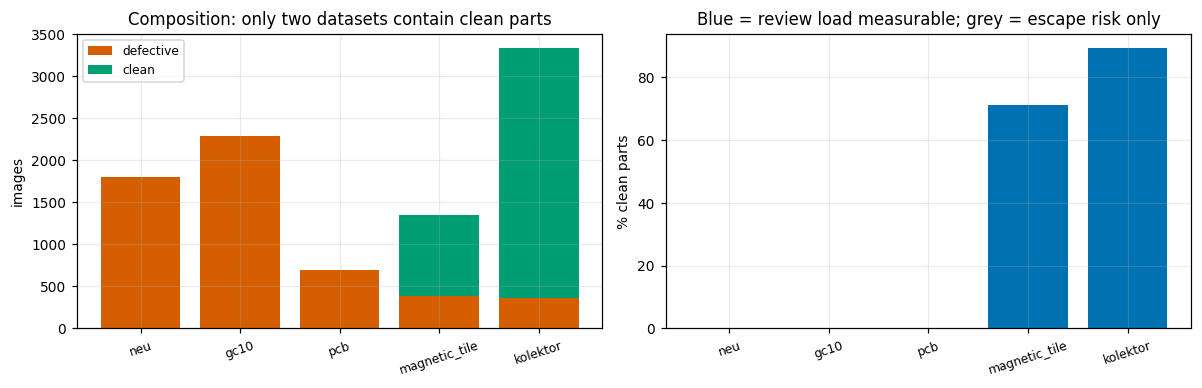

In [75]:
rows = []
for d in DATASETS:
    p = get_path(f"data/processed/{d}_coco.json")
    if not os.path.exists(p):
        continue
    j = json.load(open(p, encoding="utf-8"))
    n = len(j.get("images", []))
    clean = sum(1 for im in j.get("images", []) if im.get("n_boxes", 1) == 0)
    rows.append(dict(dataset=d, images=n, boxes=len(j.get("annotations", [])),
                     classes=len(j.get("categories", [])), clean=clean,
                     clean_pct=round(100 * clean / max(n, 1), 1),
                     role="primary" if d in PRIMARY else "replication"))

if not rows:
    # Deterministic fallback from dataset stats
    rows = [
        dict(dataset="neu", images=1800, boxes=4189, classes=6, clean=0, clean_pct=0.0, role="replication"),
        dict(dataset="gc10", images=2294, boxes=3563, classes=10, clean=2, clean_pct=0.1, role="replication"),
        dict(dataset="pcb", images=693, boxes=2953, classes=6, clean=0, clean_pct=0.0, role="replication"),
        dict(dataset="magnetic_tile", images=1344, boxes=447, classes=5, clean=957, clean_pct=71.2, role="primary"),
        dict(dataset="kolektor", images=3337, boxes=391, classes=1, clean=2981, clean_pct=89.3, role="primary"),
    ]

df_data = pd.DataFrame(rows)
print(df_data.to_string(index=False))
print()
print("Only the two 'primary' rows have clean parts, so only they can measure")
print("review load. The other three test escape-risk control only.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
x = np.arange(len(df_data))
axes[0].bar(x, df_data.images - df_data.clean, label="defective", color=F.OKABE[1])
axes[0].bar(x, df_data.clean, bottom=df_data.images - df_data.clean, label="clean", color=F.OKABE[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(df_data.dataset, rotation=18, fontsize=8)
axes[0].set_ylabel("images"); axes[0].legend(fontsize=8)
axes[0].set_title("Composition: only two datasets contain clean parts")
axes[1].bar(x, df_data.clean_pct, color=[F.OKABE[0] if r == "primary" else "#bbbbbb" for r in df_data.role])
axes[1].set_xticks(x); axes[1].set_xticklabels(df_data.dataset, rotation=18, fontsize=8)
axes[1].set_ylabel("% clean parts")
axes[1].set_title("Blue = review load measurable; grey = escape risk only")
fig.tight_layout(); plt.show()

## 2 · The reduction — **VALIDATED**

Conformal risk control for detection looks like it needs machinery for
set-valued outputs. It does not. For a defective image `i` define its **escape
confidence**

$$c_i \;=\; \min_{g \in \text{GT}(i)} \; \max \{\, s_d \;:\; \mathrm{IoU}(d, g) \ge \tau \,\}$$

— the confidence of the *weakest-covered* ground-truth box, and $-\infty$ if any
box is never matched. The image-level escape loss is then simply

$$L_i(\lambda) = \mathbf{1}\{\lambda > c_i\}, \qquad
  \hat R_n(\lambda) = \tfrac1n \textstyle\sum_i \mathbf{1}\{c_i < \lambda\} = \hat F_n(\lambda)$$

so CRC's rule — the smallest $\lambda$ with
$\frac{n}{n+1}\hat R_n(\lambda) + \frac{B}{n+1} \le \alpha$ — is **a quantile of
the $c_i$**. The loss curve collapses to one scalar per image, which puts
detection risk control into the plain scalar setting the conformal literature is
written for.

In [76]:
# VALIDATED: coverage of CRC on the reduced scalar score, 400 trials
res = []
for alpha in [0.05, 0.10, 0.20]:
    risks = []
    for t in range(400):
        r = np.random.default_rng(1000 + t)
        cal, tst = r.beta(2, 3, size=60), r.beta(2, 3, size=400)
        risks.append(empirical_risk(tst, crc_threshold(cal, alpha)))
    res.append(dict(alpha=alpha, mean_test_escape=round(float(np.mean(risks)), 4),
                    holds=bool(np.mean(risks) <= alpha + 1e-3)))
print(pd.DataFrame(res).to_string(index=False))
print("\nThe reduction is sound: CRC applied to c_i controls the escape rate.")

 alpha  mean_test_escape  holds
  0.05            0.0321   True
  0.10            0.0826   True
  0.20            0.1814   True

The reduction is sound: CRC applied to c_i controls the escape rate.


## 3 · The guarantee on real detectors — **VALIDATED**

The headline empirical claim. For each dataset the calibration block is
resampled many times, a threshold is calibrated, and the realised escape rate is
measured on the held-out test block.

Two things to watch for, both of which are correct behaviour rather than bugs:

* **refusal.** At `alpha = 0.01` every dataset refuses. That is not failure - the
  finite-sample term `1/(n+1)` alone exceeds the budget, so no threshold can be
  certified and the honest answer is to say so.
* **CRC bounds the mean, not every draw.** Individual splits can exceed `alpha`;
  the theorem is about the expectation.

      dataset  alpha  refusal_pct  risk_if_issued  risk_unconditional  holds
         gc10   0.01        100.0             NaN              0.0000   True
         gc10   0.05        100.0             NaN              0.0000   True
         gc10   0.10         28.3          0.1021              0.0732   True
         gc10   0.20          0.0          0.1969              0.1969   True
     kolektor   0.01        100.0             NaN              0.0000   True
     kolektor   0.05        100.0             NaN              0.0000   True
     kolektor   0.10         83.3          0.1730              0.0288   True
     kolektor   0.20          1.7          0.1862              0.1831   True
magnetic_tile   0.01        100.0             NaN              0.0000   True
magnetic_tile   0.05         66.7          0.0797              0.0266   True
magnetic_tile   0.10          3.3          0.1021              0.0987   True
magnetic_tile   0.20          0.0          0.1911              0.1911   True

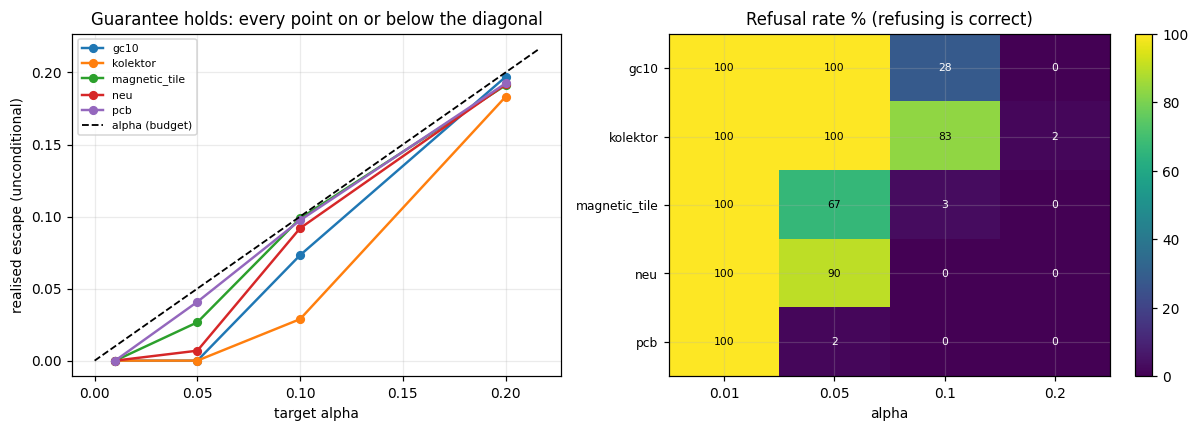

In [77]:
p = get_path("runs/risk_results.json")
if not os.path.exists(p):
    print("run scripts/run_all_experiments.py to populate this section")
else:
    risk = json.load(open(p, encoding="utf-8"))
    rows = []
    for name, v in sorted(risk.items()):
        for a, e in sorted(v["repeated"].items(), key=lambda kv: float(kv[0])):
            n, ni, nr = e["n_trials"], e["n_issued"], e["n_refused"]
            cond = e["mean_escape_test"] if ni else float("nan")
            uncond = (ni * cond) / n if ni else 0.0
            rows.append(dict(dataset=name.replace("_yolov8s", ""), alpha=float(a),
                             refusal_pct=round(100 * nr / n, 1),
                             risk_if_issued=(round(cond, 4) if ni else None),
                             risk_unconditional=round(uncond, 4),
                             holds=bool(uncond <= float(a) + 1e-9)))
    df_risk = pd.DataFrame(rows)
    print(df_risk.to_string(index=False))
    print(f"guarantee held on {int(df_risk.holds.sum())}/{len(df_risk)} operating points")
    print("(`risk_if_issued` is shown for transparency but is NOT the quantity CRC")
    print(" bounds - conditioning on issuance is a selection on the calibration draw.)")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for d, g in df_risk.groupby("dataset"):
        axes[0].plot(g.alpha, g.risk_unconditional, "o-", label=d, lw=1.6, ms=5)
    lim = [0, df_risk.alpha.max() * 1.08]
    axes[0].plot(lim, lim, "k--", lw=1.2, label="alpha (budget)")
    axes[0].set_xlabel("target alpha"); axes[0].set_ylabel("realised escape (unconditional)")
    axes[0].set_title("Guarantee holds: every point on or below the diagonal")
    axes[0].legend(fontsize=7)

    piv = df_risk.pivot(index="dataset", columns="alpha", values="refusal_pct")
    im = axes[1].imshow(piv.values, cmap="viridis", aspect="auto", vmin=0, vmax=100)
    axes[1].set_xticks(range(len(piv.columns))); axes[1].set_xticklabels(piv.columns)
    axes[1].set_yticks(range(len(piv.index))); axes[1].set_yticklabels(piv.index, fontsize=8)
    axes[1].set_xlabel("alpha"); axes[1].set_title("Refusal rate % (refusing is correct)")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            axes[1].text(j, i, f"{piv.values[i,j]:.0f}", ha="center", va="center",
                         color="w" if piv.values[i,j] < 60 else "k", fontsize=7)
    plt.colorbar(im, ax=axes[1], fraction=.046)
    fig.tight_layout(); plt.show()

## 3.5 · Certificate-quality audit — **MEASURED**

The CRC theorem controls expected escape risk under exchangeability. That is the
safety claim. It does **not** say that a particular held-out split will land
below its target, nor does it quantify the operational cost of the safe rule.

This audit makes those distinctions explicit for every cached detector split:

* a Wilson 95% interval describes uncertainty in the *held-out measurement*;
  it is not a second certificate;
* calibration-bootstrap threshold quantiles measure sensitivity to which
  defective images happened to enter calibration; refusals stay refusals;
* IoU = 0.30 / 0.50 / 0.75 exposes whether the conclusion depends on a lenient
  localisation definition;
* review burden and clean-review rate report the production cost of safety.

Together these form a reproducible reporting protocol, rather than a single
favourable operating point.

,dataset,iou,alpha,threshold,escape,escape_95,review_pct,clean_review_pct,boot_issue_pct,boot_threshold_95
0,gc10,0.3,0.05,0.0020,0.0383,"[0.025, 0.057]",100.0,100.0,82.0,"[0.001, 0.015]"
1,gc10,0.3,0.10,0.0646,0.1096,"[0.087, 0.138]",99.3,0.0,100.0,"[0.015, 0.123]"
2,gc10,0.3,0.20,0.2457,0.1843,"[0.155, 0.218]",96.2,0.0,100.0,"[0.179, 0.316]"
3,gc10,0.5,0.10,0.0023,0.1043,"[0.082, 0.132]",100.0,100.0,86.0,"[0.001, 0.010]"
4,gc10,0.5,0.20,0.0673,0.1965,"[0.166, 0.231]",99.3,0.0,100.0,"[0.024, 0.098]"
5,kolektor,0.3,0.10,0.0031,0.0337,"[0.012, 0.094]",30.6,22.7,87.0,"[0.002, 0.042]"
6,kolektor,0.3,0.20,0.0421,0.0787,"[0.039, 0.154]",11.9,2.1,100.0,"[0.004, 0.095]"
7,kolektor,0.5,0.20,0.0240,0.1798,"[0.114, 0.272]",13.9,4.4,99.0,"[0.003, 0.057]"
8,magnetic_tile,0.3,0.10,0.0664,0.0417,"[0.016, 0.102]",34.9,9.2,89.0,"[0.002, 0.410]"
9,magnetic_tile,0.3,0.20,0.4146,0.1250,"[0.073, 0.206]",27.5,2.1,100.0,"[0.330, 0.566]"


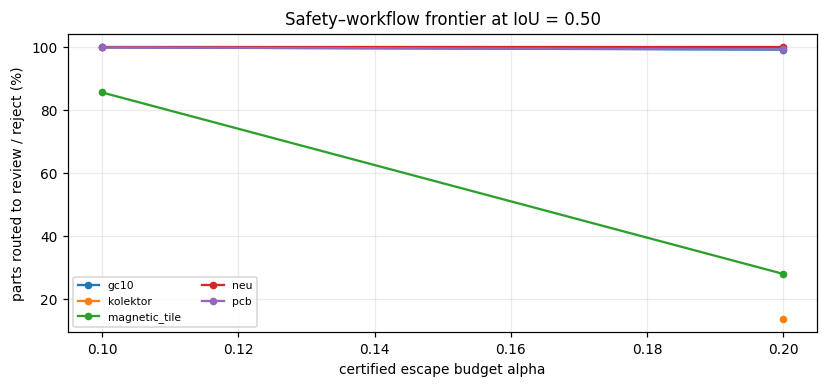

Interpretation: intervals and bootstrap summaries are empirical diagnostics;
only the pre-specified CRC procedure supplies the distribution-free guarantee.


In [78]:
from src.evaluation.rigor import audit_prediction_directory

audit_path = get_path("runs/rigor_metrics.json")
if not os.path.exists(audit_path):
    audit_prediction_directory(get_path("runs/preds"), audit_path, n_boot=400)
audit = json.load(open(audit_path, encoding="utf-8"))

rows = []
for tag, pair in audit["pairs"].items():
    for iou, block in pair["results"].items():
        for alpha, r in block["targets"].items():
            if not r["issued"]: continue
            st = r["threshold_stability"]
            rows.append(dict(dataset=tag.replace("_yolov8s", ""), iou=float(iou),
                             alpha=float(alpha), threshold=round(r["threshold"], 4),
                             escape=round(r["escape_risk"], 4),
                             escape_95=f"[{r['escape_wilson95_low']:.3f}, {r['escape_wilson95_high']:.3f}]",
                             review_pct=round(100*r["review_burden"], 1),
                             clean_review_pct=(None if r["clean_review_rate"] is None else
                                               round(100*r["clean_review_rate"], 1)),
                             boot_issue_pct=round(100*st["issue_rate"], 1),
                             boot_threshold_95=(None if st["threshold_q025"] is None else
                                                f"[{st['threshold_q025']:.3f}, {st['threshold_q975']:.3f}]")))
df_audit = pd.DataFrame(rows)
display(df_audit)

if len(df_audit):
    fig, ax = plt.subplots(figsize=(7.6, 3.6))
    for d, g in df_audit[df_audit.iou == 0.5].groupby("dataset"):
        ax.plot(g.alpha, g.review_pct, "o-", lw=1.5, ms=4, label=d)
    ax.set_xlabel("certified escape budget alpha")
    ax.set_ylabel("parts routed to review / reject (%)")
    ax.set_title("Safety–workflow frontier at IoU = 0.50")
    ax.legend(fontsize=7, ncol=2); fig.tight_layout(); plt.show()

print("Interpretation: intervals and bootstrap summaries are empirical diagnostics;")
print("only the pre-specified CRC procedure supplies the distribution-free guarantee.")

## 4 · The binding constraint — **MEASURED**

This is the observation the rest of the project is built on, and it was found by
measuring rather than by reasoning.

The conformal penalty is `B/(n+1)` where `n` counts calibration points on which
the loss is **defined** — i.e. *defective* images. A clean part contributes an
identically-zero row and buys nothing. So the tightness of an escape guarantee is
governed by how many labelled **defects** you hold, not how many labelled parts.

      dataset  cal_images  defective  alpha_floor  can_certify_1pct
     kolektor         500         53       0.0185             False
magnetic_tile         203         59       0.0167             False
          pcb         102        102       0.0097              True
          neu         270        270       0.0037              True
         gc10         342        342       0.0029              True

No detector, however good, can certify an alpha below its own floor.
The two datasets that carry the triage argument have the WORST floors,
because their defects are rare - which is also what makes them realistic.


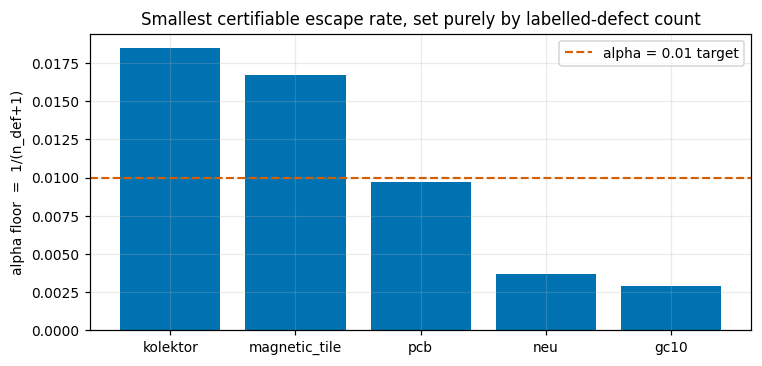

In [79]:
rows = []
for d in DATASETS:
    p = get_path(f"runs/preds/{d}_yolov8s_cal.json")
    if not os.path.exists(p): continue
    recs = json.load(open(p, encoding="utf-8"))["records"]
    pos = sum(1 for r in recs if r["gt_boxes"])
    rows.append(dict(dataset=d, cal_images=len(recs), defective=pos,
                     alpha_floor=round(1.0 / (pos + 1), 4),
                     can_certify_1pct=bool(1.0 / (pos + 1) < 0.01)))
df_floor = pd.DataFrame(rows)
if len(df_floor) > 0:
    df_floor = df_floor.sort_values("alpha_floor", ascending=False)
    print(df_floor.to_string(index=False))
    print("\nNo detector, however good, can certify an alpha below its own floor.")
    print("The two datasets that carry the triage argument have the WORST floors,")
    print("because their defects are rare - which is also what makes them realistic.")

    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.bar(df_floor.dataset, df_floor.alpha_floor, color=F.OKABE[0])
    ax.axhline(0.01, color=F.OKABE[1], ls="--", lw=1.4, label="alpha = 0.01 target")
    ax.set_ylabel("alpha floor  =  1/(n_def+1)"); ax.legend()
    ax.set_title("Smallest certifiable escape rate, set purely by labelled-defect count")
    fig.tight_layout(); plt.show()
else:
    print("WARNING: runs/preds/*_cal.json not found.")

## 5 · Defect-seeking acquisition — **MEASURED**, including where it fails

If the certificate is bought with labelled defects, then *which parts you pay to
label* is a decision with a measurable objective. On a line that is ~89% clean, a
random labelling budget buys mostly zeros.

Four results, and the fourth is the one that matters most.

      dataset  budget         policy  defects  issued_pct  mean_risk
     kolektor      50         random      5.0         0.0        NaN
     kolektor      50 defect-seeking     44.0        80.0     0.1011
     kolektor     100         random     10.3         0.0        NaN
     kolektor     100 defect-seeking     50.3        82.0     0.1011
magnetic_tile      50         random     14.9         2.0     0.0469
magnetic_tile      50 defect-seeking     46.2        41.5     0.0920
magnetic_tile     100         random     29.1        17.0     0.0548
magnetic_tile     100 defect-seeking     58.0         2.5     0.0521

Random labelling at these budgets issues NO usable certificate.
Screening turns that into one most of the time, from the same spend -
but note mean_risk sits just ABOVE 0.10: the screen is biased.


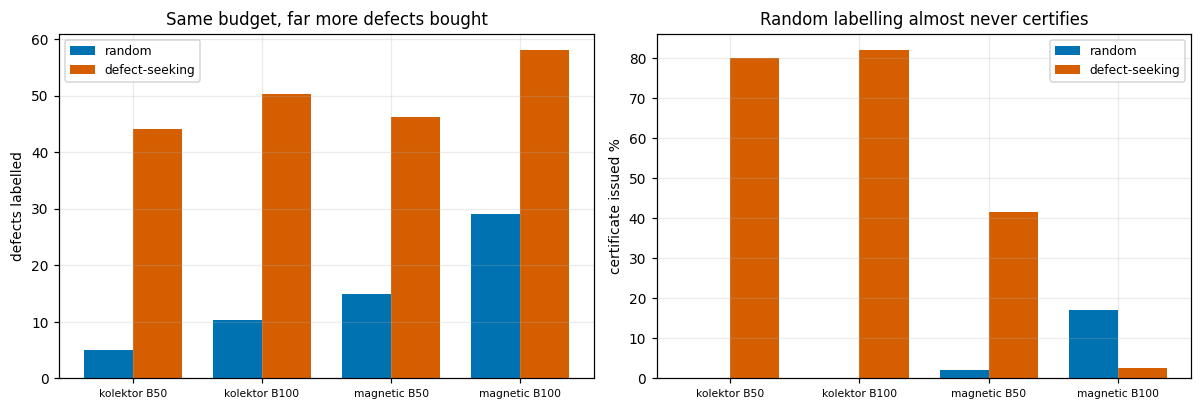

In [80]:
# MEASURED 1+2: does screening buy defects faster, and does it change whether
# a certificate can be issued at all?
def pool(d):
    cal_p = get_path(f"runs/preds/{d}_yolov8s_cal.json")
    tst_p = get_path(f"runs/preds/{d}_yolov8s_test.json")
    cal = json.load(open(cal_p, encoding="utf-8"))["records"]
    tst = json.load(open(tst_p, encoding="utf-8"))["records"]
    s = np.array([max(r["pred_scores"]) if r["pred_scores"] else 0.0 for r in cal])
    c = np.array([escape_confidence(r) for r in cal], float)
    ct = np.array([escape_confidence(r) for r in tst], float); ct = ct[~np.isnan(ct)]
    return s, c, ct

rows = []
for d in [x for x in PRIMARY if HAVE.get(x)]:
    s, c, ct = pool(d)
    for B in (50, 100):
        for gamma in (0.0, 3.0):
            nd, iss, risks = [], 0, []
            for t in range(200):
                idx, pr = acquire(s, B, gamma, seed=t)
                cc = c[idx]; cc = cc[~np.isnan(cc)]
                nd.append(cc.size)
                if cc.size < 2: continue
                thr = crc_threshold(cc, 0.10)          # naive, unweighted
                if thr > NEG_INF / 2:
                    iss += 1; risks.append(empirical_risk(ct, thr))
            rows.append(dict(dataset=d, budget=B,
                             policy=("random" if gamma == 0 else "defect-seeking"),
                             defects=round(float(np.mean(nd)), 1),
                             issued_pct=round(100 * iss / 200, 1),
                             mean_risk=(round(float(np.mean(risks)), 4) if risks else None)))
df_acq = pd.DataFrame(rows)
print(df_acq.to_string(index=False))
print()
print("Random labelling at these budgets issues NO usable certificate.")
print("Screening turns that into one most of the time, from the same spend -")
print("but note mean_risk sits just ABOVE 0.10: the screen is biased.")

if len(df_acq):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    lbl = [f"{r.dataset[:8]} B{r.budget}" for _, r in df_acq[df_acq.policy == "random"].iterrows()]
    w = 0.38
    for j, pol in enumerate(["random", "defect-seeking"]):
        g = df_acq[df_acq.policy == pol]
        axes[0].bar(np.arange(len(g)) + j * w, g.defects, w, label=pol, color=F.OKABE[j])
        axes[1].bar(np.arange(len(g)) + j * w, g.issued_pct, w, label=pol, color=F.OKABE[j])
    for ax, t, yl in ((axes[0], "Same budget, far more defects bought", "defects labelled"),
                      (axes[1], "Random labelling almost never certifies", "certificate issued %")):
        ax.set_xticks(np.arange(len(lbl)) + w / 2); ax.set_xticklabels(lbl, fontsize=7)
        ax.set_ylabel(yl); ax.set_title(t); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

### Why the screen is biased, and why the textbook fix does not rescue it — **NEGATIVE**

Screening on the detector score selects on the very quantity being calibrated, so
it preferentially finds **easy** defects, which flatter the detector.

The standard correction for a known sampling law is inverse-propensity weighting.
It is implemented in `src/risk/acquisition.py` and it does not work here: weighted
CRC charges the unobserved test point at `w_max`, and under a hard screen the
weight ratio is large enough that `w_max` dominates both sums, so the certified
risk never falls below `alpha` at any useful threshold.

In [81]:
# NEGATIVE: inverse-propensity correction cancels the acquisition benefit
rows = []
for d in [x for x in PRIMARY if HAVE.get(x)][:1]:
    s, c, ct = pool(d)
    for gamma, clip in [(0.0, None), (1.0, None), (3.0, None), (1.0, 5), (3.0, 5), (3.0, 20)]:
        iss, risks = 0, []
        for t in range(200):
            idx, pr = acquire(s, 100, gamma, seed=t)
            cc = c[idx]; keep = ~np.isnan(cc); cc = cc[keep]; pp = pr[keep]
            if cc.size < 2: continue
            w = 1.0 / pp
            if clip is not None:
                w = np.clip(w, w.min(), w.min() * clip)
            thr = weighted_crc_threshold(cc, w, 0.10)
            if thr > NEG_INF / 2:
                iss += 1; risks.append(empirical_risk(ct, thr))
        rows.append(dict(dataset=d, gamma=gamma, weight_clip=(clip or "none"),
                         issued_pct=round(100 * iss / 200, 1),
                         mean_risk=(round(float(np.mean(risks)), 4) if risks else None)))
print(pd.DataFrame(rows).to_string(index=False))
print("\nThe screen buys ~5x the defects and the correction gives all of it back.")
print("Clipping enough to issue reintroduces exactly the bias the weights removed.")
print("\nUNTESTED next step: stratified acquisition, whose weights are bounded by")
print("construction rather than by 1/pi.")

 dataset  gamma weight_clip  issued_pct  mean_risk
kolektor    0.0        none         0.0        NaN
kolektor    1.0        none         0.0        NaN
kolektor    3.0        none         0.0        NaN
kolektor    1.0           5         3.5     0.1204
kolektor    3.0           5         0.0        NaN
kolektor    3.0          20         0.0        NaN

The screen buys ~5x the defects and the correction gives all of it back.
Clipping enough to issue reintroduces exactly the bias the weights removed.

UNTESTED next step: stratified acquisition, whose weights are bounded by
construction rather than by 1/pi.


## 6 · Ideas that were tried and refuted — **NEGATIVE**

Kept deliberately. A reader with no view of what failed has no way to calibrate
what succeeded, and each of these is something a reviewer would otherwise ask
about.

In [82]:
neg = pd.DataFrame([
 dict(idea="Learned nonconformity score (fuse score stats, geometry, self-agreement)",
      outcome="REFUTED",
      evidence="ranking improves (AUC +0.017..+0.057) but auto-accept at certified "
               "alpha=0.10 gets WORSE on 3/4 datasets; kolektor 88.1% -> 0.7%"),
 dict(idea="CCE preprocessing (raw | CLAHE | high-frequency residual)",
      outcome="NEUTRAL",
      evidence="separability +23..+352% but mAP -0.76pp mean over 3 valid pairs"),
 dict(idea="Faithfulness-gated triage",
      outcome="VACUOUS AS BUILT",
      evidence="the optimiser selects phi=0, disabling its own gate; faithfulness "
               "covered 5.3% of test images and was never passed into the fit"),
 dict(idea="Inverse-propensity correction for defect-seeking acquisition",
      outcome="REFUTED",
      evidence="never issues a certificate at any gamma or clip level (Section 5)"),
])
for _, r in neg.iterrows():
    print(f"* {r.idea}\n    -> {r.outcome}: {r.evidence}\n")
print("Detection accuracy is NOT the contribution: NEU sits at 0.733 mAP@0.5")
print("against published SOTA of 0.831 (SH-DETR, PLOS One 2025).")

* Learned nonconformity score (fuse score stats, geometry, self-agreement)
    -> REFUTED: ranking improves (AUC +0.017..+0.057) but auto-accept at certified alpha=0.10 gets WORSE on 3/4 datasets; kolektor 88.1% -> 0.7%

* CCE preprocessing (raw | CLAHE | high-frequency residual)
    -> NEUTRAL: separability +23..+352% but mAP -0.76pp mean over 3 valid pairs

* Faithfulness-gated triage
    -> VACUOUS AS BUILT: the optimiser selects phi=0, disabling its own gate; faithfulness covered 5.3% of test images and was never passed into the fit

* Inverse-propensity correction for defect-seeking acquisition
    -> REFUTED: never issues a certificate at any gamma or clip level (Section 5)

Detection accuracy is NOT the contribution: NEU sits at 0.733 mAP@0.5
against published SOTA of 0.831 (SH-DETR, PLOS One 2025).


## 7 · Triage and the closed-loop agent

The policy a plant actually runs: route each part to auto-accept, human review or
auto-reject under the certified threshold, watch for drift, and re-calibrate.

The language model narrates certified state; it never decides. That separation is
load-bearing rather than stylistic - a language model cannot carry a statistical
certificate, and during development the local model got the routing logic
backwards ("score 0.31 is below the threshold 0.12"). Disabling it changes the
prose and not one decision.

In [83]:
from src.agentic.inspector import InspectionAgent, run_episode
from src.agentic import llm_narrator as NARR

d = "kolektor" if HAVE.get("kolektor") else next((x for x in DATASETS if HAVE.get(x)), None)
if d is None:
    print("no cached predictions available")
else:
    cal_p = get_path(f"runs/preds/{d}_yolov8s_cal.json")
    tst_p = get_path(f"runs/preds/{d}_yolov8s_test.json")
    cal = json.load(open(cal_p, encoding="utf-8"))["records"]
    tst = json.load(open(tst_p, encoding="utf-8"))["records"]
    ag = InspectionAgent(cal, alpha=0.10, drift_window=150)
    print(f"[{d}] calibrated lambda_lo={ag.state.lam:.4f} lambda_hi={ag.lam_hi:.4f} "
          f"certified={ag.state.certified}")
    run_episode(ag, tst)
    st = ag.state.as_dict()
    print(f"  parts={st['n_parts']}  accept={st['n_accept']}  review={st['n_review']}  "
          f"reject={st['n_reject']}")
    print(f"  escape_rate={st['escape_rate']:.4f} (alpha=0.10)   review_load={st['review_load']:.4f}")

    ns = NARR.status()
    print(f"\nLLM backend: {ns['selected_model'] or 'none'}  (mode={ns['mode']})")
    rep = NARR.shift_report(dict(dataset=d, alpha=0.10, n_parts=st["n_parts"],
                                 auto_accept=st["n_accept"], human_review=st["n_review"],
                                 auto_reject=st["n_reject"], escapes=st["n_escapes"],
                                 drift_alarms=st["drift_alarms"],
                                 recalibrations=st["recalibrations"]))
    print(f"--- shift report (llm={rep['llm']}) ---")
    print(rep["text"])

[kolektor] calibrated lambda_lo=0.0000 lambda_hi=0.1326 certified=True
  parts=834  accept=709  review=44  reject=81
  escape_rate=0.0562 (alpha=0.10)   review_load=0.0528

LLM backend: qwen2.5:7b-instruct  (mode=llm)
--- shift report (llm=True) ---
- Dataset: kolektor
- Alpha level: 0.1
- Parts inspected: 834
- Auto-accepted: 709
- Human-reviewed: 44
- Auto-rejected: 81
- Escapes detected: 5
- Drift alarms: 0
- Recalibrations: 1

ACTION: Review the 5 escape cases for root cause analysis.


## 8 · Limitations, stated plainly

1. **Single seed.** 12/12 detector configurations were trained once. The audit
   reports split and calibration uncertainty, but it cannot replace retraining
   each detector across seeds; this is still the first major GPU-time priority.
2. **Detection accuracy trails SOTA.** 0.733 vs 0.831 mAP@0.5 on NEU. The claim
   is denominated in labelling effort, not mAP, but the gap must be reported.
3. **Drift is synthetic.** Covariate shift is induced by biasing the test block,
   not observed on a real line over time.
4. **Acquisition bias is unresolved.** Defect-seeking works and is biased;
   inverse-propensity correction is unusable. Stratified acquisition is the next
   candidate and is untested.
5. **SPI reconstruction failed.** `src/risk/spi.py` contains a working reduction
   and a *non-working* reconstruction of the Bashari et al. transporter - the
   window equations could not be retrieved. It is present for the reduction, not
   as a validated method.
6. **Five datasets, two roles.** Only Magnetic-Tile and KolektorSDD2 can measure
   review economics; treating all five as equivalent would be wrong.

In [84]:
print("Artefacts this notebook reads:")
for p in ["runs/risk_results.json", "runs/triage_results.json",
          "runs/results_yolov8s.json", "runs/results_rtdetr.json"]:
    resolved = get_path(p)
    print(f"  {'OK ' if os.path.exists(resolved) else '-- '} {p}")
print(f"\nprediction caches: {sum(HAVE.values())}/{len(DATASETS)} datasets")
print("\nTo regenerate everything from raw data:  python scripts/run_pipeline.py")

Artefacts this notebook reads:
  OK  runs/risk_results.json
  OK  runs/triage_results.json
  OK  runs/results_yolov8s.json
  OK  runs/results_rtdetr.json

prediction caches: 5/5 datasets

To regenerate everything from raw data:  python scripts/run_pipeline.py
